# Analisi di Serie Storiche su Dati di Diabete — BrisT1D

## Obiettivo del progetto

Questo notebook sviluppa e confronta diversi approcci di modellazione predittiva per la
glicemia di un paziente con diabete di tipo 1, a partire dal dataset **BrisT1D Blood Glucose
Prediction** (Kaggle). Il lavoro segue la seguente pipeline : dalla
ricostruzione di una serie storica utilizzabile a partire da un formato dati non standard,
fino al confronto sistematico tra modelli statistici classici (SARIMA, SARIMAX), un
modello a componenti additive (Prophet), un modello non lineare ad alberi (Gradient
Boosting) e una rete neurale ricorrente (LSTM).

Una nota metodologica attraversa l'intero notebook e vale la pena anticiparla: il dataset
originale non è distribuito come serie storica regolare, ma come tabella "wide" pensata per
un compito di regressione supervisionata (il target della competizione Kaggle,
`bg+1:00`, è la glicemia un'ora nel futuro rispetto a ciascuna riga). 



## Fase 1 — Selezione e Documentazione del Dataset
Il dataset selezionato è il **BrisT1D Blood Glucose Prediction Dataset**, pubblicato su Kaggle nell'ambito della competizione omonima.

URL: https://www.kaggle.com/competitions/brist1d

Il dataset deriva da uno studio osservazionale condotto su un gruppo di giovani adulti nel Regno Unito affetti da **Diabete di Tipo 1 (T1D)**. I partecipanti hanno utilizzato contemporaneamente un sensore per il monitoraggio continuo della glicemia (CGM), un microinfusore di insulina e uno smartwatch, per un periodo compreso tra circa tre e oltre sei mesi a seconda del partecipante. 

I dati grezzi sono stati aggregati dagli organizzatori della competizione in intervalli di 5 minuti e distribuiti in formato tabellare (train.csv, test.csv, activities.txt, sample_submission.csv), sotto licenza Creative Commons Attribution 4.0.

Il dataset non è distribuito come una tradizionale serie storica "lunga" (una riga per timestamp), ma in formato *wide/lag*: ogni riga (identificata da id e dal partecipante p_num) rappresenta un istante temporale e contiene, per ciascuna grandezza monitorata, una sequenza di colonne che riportano il valore registrato ogni 5 minuti nelle 6 ore precedenti (suffisso -X:XX, da -5:55 a -0:00). La variabile target è la glicemia un'ora nel futuro rispetto all'istante della riga.

| **Colonna / Gruppo** | **Unità** | **Descrizione** |
|----------------------|-----------|-----------------|
| `p_num`, `time`, `id` | - | Identificativo del partecipante, orario di rilevazione e chiave univoca della riga; costituiscono la componente temporale/anagrafica del dataset. |
| `bg-X:XX` | mmol/L | Livello di glucosio nel sangue registrato dal CGM negli intervalli di 5 minuti precedenti. |
| `insulin-X:XX` | U (unità) | Dose totale di insulina erogata dal microinfusore nei 5 minuti precedenti. |
| `carbs-X:XX` | g | Quantità di carboidrati assunti, dichiarata dal paziente nel microinfusore/reader. |
| `hr-X:XX` | bpm | Frequenza cardiaca media rilevata dallo smartwatch. |
| `steps-X:XX` | conteggio | Numero di passi registrati dallo smartwatch. |
| `cals-X:XX` | kcal | Calorie bruciate, stimate dallo smartwatch. |
| `activity-X:XX` | categoriale | Tipo di attività fisica svolta (es. camminata, corsa, ciclismo), da mappare tramite `activities.txt`. |
| `bg+1:00` | mmol/L | **Target:** glicemia prevista un'ora dopo l'istante della riga. |


*Nota metodologica: per le analisi di serie storiche classiche (decomposizione, ADF/KPSS, ACF/PACF, ARIMA/SARIMA) è necessario ricostruire, per ciascun p_num, una serie continua ordinata cronologicamente a partire dalle colonne bg-X:XX di righe consecutive, poiché il formato "a finestre mobili" fornito dalla competizione è pensato per un approccio supervisionato tabellare più che per un'analisi di serie storiche univariate.*

### Motivazione della scelta
- **Dato clinico reale e recente**: raccolto tramite dispositivi medici certificati (CGM, microinfusore) e wearable, non simulato;

- Componente temporale nativa e ad alta frequenza (5 minuti), adatta a resampling, decomposizione stagionale (ritmi circadiani) e modellazione predittiva

- **Multivariato**: oltre alla glicemia sono disponibili insulina, carboidrati e attività fisica, che permettono di arricchire i modelli con variabili esogene (SARIMAX, feature per LSTM).

- Dimensione e qualità sufficienti a supportare un test set temporalmente separato per la validazione.

- **Rilevanza clinica**: la previsione della glicemia futura è un problema attuale nella gestione del diabete di tipo 1, alla base dei moderni sistemi "hybrid closed-loop" (pancreas artificiale).

### Problematiche etiche e di privacy

-	**Dati sanitari sensibili**: la glicemia, la posologia insulinica e i parametri fisiologici rientrano nelle categorie di dati particolari secondo il GDPR (art. 9), anche se qui utilizzati a fini didattici su dati già pubblicati.

-	**Pseudonimizzazione**: i partecipanti sono identificati da codici (p_num) e non da dati anagrafici diretti; tuttavia la combinazione di pattern comportamentali ad alta frequenza (attività, orari dei pasti, dosaggi) rappresenta un rischio residuo di re-identificazione, tipico dei dati wearable longitudinali.

-	**Consenso e finalità**: i dati sono stati raccolti nell'ambito di uno studio clinico con consenso informato dei partecipanti e resi pubblici dagli organizzatori della competizione per finalità di ricerca; l'uso in questo progetto è coerente con tale finalità (didattica/di ricerca), non commerciale.

-	**Generalizzabilità limitata**: il campione è composto da un numero ristretto di giovani adulti in UK; eventuali modelli predittivi non vanno considerati validati per popolazioni cliniche più ampie o eterogenee.

-	**Uso clinico**: i risultati del progetto hanno finalità esclusivamente didattiche e non costituiscono dispositivo medico né supporto a decisioni terapeutiche reali.



## Fase 2 - Analisi della Serie Storica

In [1]:
# Manipolazione dati e visualizzazione
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# Strumenti di analisi di serie storiche: decomposizione, test di stazionarietà, ACF/PACF
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Modelli di forecasting
from statsmodels.tsa.statespace.sarimax import SARIMAX
import pmdarima as pm
from prophet import Prophet

# Metriche di valutazione
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

plt.rcParams["figure.figsize"] = (14, 5)
RANDOM_STATE = 42

## 1. Caricamento del dataset

In [2]:
DATA_DIR = Path("Data")
# Caricamento del dataset
df = pd.read_csv(DATA_DIR / "train.csv")


Importo il csv di train fornito da Kaggle, l'idea è quella di studiare il dataset di train, ricavare da qui un validation set e poi testare, alla fine, i modelli vincitori sul test set fornito da Kaggle.

In [3]:
print(df.shape)

(177024, 508)


In [4]:
pd.set_option('display.max_columns', None)
display(df)

,id,p_num,time,bg-5:55,bg-5:50,bg-5:45,bg-5:40,bg-5:35,bg-5:30,bg-5:25,bg-5:20,bg-5:15,bg-5:10,bg-5:05,bg-5:00,bg-4:55,bg-4:50,bg-4:45,bg-4:40,bg-4:35,bg-4:30,bg-4:25,bg-4:20,bg-4:15,bg-4:10,bg-4:05,bg-4:00,bg-3:55,bg-3:50,bg-3:45,bg-3:40,bg-3:35,bg-3:30,bg-3:25,bg-3:20,bg-3:15,bg-3:10,bg-3:05,bg-3:00,bg-2:55,bg-2:50,bg-2:45,bg-2:40,bg-2:35,bg-2:30,bg-2:25,bg-2:20,bg-2:15,bg-2:10,bg-2:05,bg-2:00,bg-1:55,bg-1:50,bg-1:45,bg-1:40,bg-1:35,bg-1:30,bg-1:25,bg-1:20,bg-1:15,bg-1:10,bg-1:05,bg-1:00,bg-0:55,bg-0:50,bg-0:45,bg-0:40,bg-0:35,bg-0:30,bg-0:25,bg-0:20,bg-0:15,bg-0:10,bg-0:05,bg-0:00,insulin-5:55,insulin-5:50,insulin-5:45,insulin-5:40,insulin-5:35,insulin-5:30,insulin-5:25,insulin-5:20,insulin-5:15,insulin-5:10,insulin-5:05,insulin-5:00,insulin-4:55,insulin-4:50,insulin-4:45,insulin-4:40,insulin-4:35,insulin-4:30,insulin-4:25,insulin-4:20,insulin-4:15,insulin-4:10,insulin-4:05,insulin-4:00,insulin-3:55,insulin-3:50,insulin-3:45,insulin-3:40,insulin-3:35,insulin-3:30,insulin-3:25,insulin-3:20,insulin-3:15,insulin-3:10,insulin-3:05,insulin-3:00,insulin-2:55,insulin-2:50,insulin-2:45,insulin-2:40,insulin-2:35,insulin-2:30,insulin-2:25,insulin-2:20,insulin-2:15,insulin-2:10,insulin-2:05,insulin-2:00,insulin-1:55,insulin-1:50,insulin-1:45,insulin-1:40,insulin-1:35,insulin-1:30,insulin-1:25,insulin-1:20,insulin-1:15,insulin-1:10,insulin-1:05,insulin-1:00,insulin-0:55,insulin-0:50,insulin-0:45,insulin-0:40,insulin-0:35,insulin-0:30,insulin-0:25,insulin-0:20,insulin-0:15,insulin-0:10,insulin-0:05,insulin-0:00,carbs-5:55,carbs-5:50,carbs-5:45,carbs-5:40,carbs-5:35,carbs-5:30,carbs-5:25,carbs-5:20,carbs-5:15,carbs-5:10,carbs-5:05,carbs-5:00,carbs-4:55,carbs-4:50,carbs-4:45,carbs-4:40,carbs-4:35,carbs-4:30,carbs-4:25,carbs-4:20,carbs-4:15,carbs-4:10,carbs-4:05,carbs-4:00,carbs-3:55,carbs-3:50,carbs-3:45,carbs-3:40,carbs-3:35,carbs-3:30,carbs-3:25,carbs-3:20,carbs-3:15,carbs-3:10,carbs-3:05,carbs-3:00,carbs-2:55,carbs-2:50,carbs-2:45,carbs-2:40,carbs-2:35,carbs-2:30,carbs-2:25,carbs-2:20,carbs-2:15,carbs-2:10,carbs-2:05,carbs-2:00,carbs-1:55,carbs-1:50,carbs-1:45,carbs-1:40,carbs-1:35,carbs-1:30,carbs-1:25,carbs-1:20,carbs-1:15,carbs-1:10,carbs-1:05,carbs-1:00,carbs-0:55,carbs-0:50,carbs-0:45,carbs-0:40,carbs-0:35,carbs-0:30,carbs-0:25,carbs-0:20,carbs-0:15,carbs-0:10,carbs-0:05,carbs-0:00,hr-5:55,hr-5:50,hr-5:45,hr-5:40,hr-5:35,hr-5:30,hr-5:25,hr-5:20,hr-5:15,hr-5:10,hr-5:05,hr-5:00,hr-4:55,hr-4:50,hr-4:45,hr-4:40,hr-4:35,hr-4:30,hr-4:25,hr-4:20,hr-4:15,hr-4:10,hr-4:05,hr-4:00,hr-3:55,hr-3:50,hr-3:45,hr-3:40,hr-3:35,hr-3:30,hr-3:25,hr-3:20,hr-3:15,hr-3:10,hr-3:05,hr-3:00,hr-2:55,hr-2:50,hr-2:45,hr-2:40,hr-2:35,hr-2:30,hr-2:25,hr-2:20,hr-2:15,hr-2:10,hr-2:05,hr-2:00,hr-1:55,hr-1:50,hr-1:45,hr-1:40,hr-1:35,hr-1:30,hr-1:25,hr-1:20,hr-1:15,hr-1:10,hr-1:05,hr-1:00,hr-0:55,hr-0:50,hr-0:45,hr-0:40,hr-0:35,hr-0:30,hr-0:25,hr-0:20,hr-0:15,hr-0:10,hr-0:05,hr-0:00,steps-5:55,steps-5:50,steps-5:45,steps-5:40,steps-5:35,steps-5:30,steps-5:25,steps-5:20,steps-5:15,steps-5:10,steps-5:05,steps-5:00,steps-4:55,steps-4:50,steps-4:45,steps-4:40,steps-4:35,steps-4:30,steps-4:25,steps-4:20,steps-4:15,steps-4:10,steps-4:05,steps-4:00,steps-3:55,steps-3:50,steps-3:45,steps-3:40,steps-3:35,steps-3:30,steps-3:25,steps-3:20,steps-3:15,steps-3:10,steps-3:05,steps-3:00,steps-2:55,steps-2:50,steps-2:45,steps-2:40,steps-2:35,steps-2:30,steps-2:25,steps-2:20,steps-2:15,steps-2:10,steps-2:05,steps-2:00,steps-1:55,steps-1:50,steps-1:45,steps-1:40,steps-1:35,steps-1:30,steps-1:25,steps-1:20,steps-1:15,steps-1:10,steps-1:05,steps-1:00,steps-0:55,steps-0:50,steps-0:45,steps-0:40,steps-0:35,steps-0:30,steps-0:25,steps-0:20,steps-0:15,steps-0:10,steps-0:05,steps-0:00,cals-5:55,cals-5:50,cals-5:45,cals-5:40,cals-5:35,cals-5:30,cals-5:25,cals-5:20,cals-5:15,cals-5:10,cals-5:05,cals-5:00,cals-4:55,cals-4:50,cals-4:45,cals-4:40,cals-4:35,cals-4:30,cals-4:25,cals-4:20,cals-4:15,cals-4:10,cals-4:05,cals-4:00,cals-3:55,cals-3:50,cals-3:45,cals-3:40,cals-3:35,cals-3:30,cals-3:25,cal

## 2. Ricostruzione della serie storica


Il file `train.csv` fornito da Kaggle non è organizzato come una serie temporale, bensì come
una tabella in formato **wide**: ogni riga rappresenta un singolo campione clinico e contiene,
in colonne separate, l'intera finestra delle 6 ore precedenti (campionata ogni 5 minuti) per
glicemia (`bg-X:XX`), insulina (`insulin-X:XX`), carboidrati (`carbs-X:XX`), frequenza
cardiaca, passi, calorie e attività fisica, oltre al target `bg+1:00` — la glicemia un'ora
nel futuro rispetto all'istante della riga.

Questo formato è ottimale per un compito di regressione tabellare (è così che la maggior
parte delle soluzioni della competizione Kaggle affronta il problema, tipicamente con modelli
ad alberi), ma non costituisce una serie storica regolare su cui applicare gli strumenti
classici di analisi temporale (decomposizione stagionale, test
di stazionarietà, autocorrelazione, modelli ARIMA).

**La mia scelta metodologica**: per ottenere una serie storica continua, ho estratto per un singolo
paziente (`p01`) la colonna `bg-0:00` — la glicemia "presente" di ciascuna riga — insieme al
suo istante temporale reale. Poiché il dataset non fornisce una data di calendario assoluta
(per ragioni di privacy dei partecipanti), ma fornisce l'ora del giorno (`time`) e l'ordine
cronologico di acquisizione delle righe, ho ricostruito un asse temporale relativo assegnando
una data fittizia di partenza e incrementando il "giorno" ogni volta che l'ora del giorno
torna indietro (segnale del passaggio di mezzanotte).

L'analisi si concentra su un singolo paziente, e non sull'aggregato di più pazienti, per un
motivo statistico preciso: la glicemia di persone diverse non condivide la stessa
distribuzione generatrice (baseline, sensibilità insulinica e variabilità individuale sono
molto diverse da persona a persona), quindi aggregarle in un'unica serie violerebbe
l'assunzione di omogeneità del processo su cui si basano i modelli di serie storiche
classici.


In [5]:
#esamino il primo paziente
PATIENT= 'p01'
df_p=df[df['p_num']==PATIENT].copy() #creo un nuovo df con solo le informazioni del paziente selezionato

# Converto 'time' (solo ora del giorno, senza data) in oggetto time per poterlo confrontare
df_p['time']=pd.to_datetime(df_p['time'], format='%H:%M:%S').dt.time



In [6]:
# L'ordine delle righe riflette l'ordine cronologico di acquisizione per il paziente.
# Ricavo un timestamp relativo per costruire un asse temporale continuo 
# (gestendo il passaggio di mezzanotte come nuovo giorno).
day = 0
timestamps = []
prev_t = None
for t in df_p['time']:
    if prev_t is not None and t < prev_t: #se t è maggiore allora è scattata la mezzanotte e quindi devo incrementare il giorno
        day += 1
    timestamps.append(pd.Timestamp("2024-01-01") + pd.Timedelta(days=day,
                        hours=t.hour, minutes=t.minute, seconds=t.second))
    prev_t = t
df_p['timestamp'] = timestamps

# Estraggo la sola colonna bg-0:00 (glicemia "presente" di ciascuna riga) come serie storica
# univariata; rimuovo duplicati temporali (dovuti alla struttura a finestre sovrapposte
# del dataset originale) e ordino cronologicamente
series = df_p[["timestamp", "bg-0:00"]].rename(columns={"bg-0:00": "bg"}).dropna()
series = series.drop_duplicates(subset="timestamp").sort_values("timestamp")
series = series.set_index("timestamp")
print(f"Paziente {PATIENT}: {len(series)} osservazioni, dal {series.index.min()} al {series.index.max()}")
series.head()

#ho inserito 2024 perchè la challenge di kaggle risale a settembre di 2 anni fa 

Paziente p01: 7716 osservazioni, dal 2024-01-01 06:10:00 al 2024-03-31 23:50:00


,bg
timestamp,
2024-01-01 06:10:00,15.1
2024-01-01 06:25:00,14.4
2024-01-01 06:40:00,13.9
2024-01-01 06:55:00,13.8
2024-01-01 07:10:00,13.4


In [7]:
print(series.shape)

(7716, 1)


## 3. Pre-processing della serie storica

### 3.1 Determinazione della risoluzione reale del sensore

Un primo resampling a 5 minuti produce una copertura di sole il 29.5% delle osservazioni
attese — un valore troppo basso per essere spiegato da semplici assenze di misurazione.
Analizzando gli intervalli di tempo più frequenti tra osservazioni consecutive, emerge che il
sensore CGM (o la configurazione di esportazione dei dati) campiona in realtà **ogni 15
minuti**, non ogni 5 come si potrebbe assumere dal nome delle colonne del dataset originale
(`bg-0:05`, `bg-0:10`, ...). Ricampionando alla risoluzione reale del sensore, la copertura
sale all'88.6%, un valore molto più coerente con un dispositivo funzionante correttamente con
occasionali interruzioni.

In [8]:

#dopo aver creato la serie storica sul primo paziente passo al pre-processing 
# dall'head sopra si vede che non tutte le misurazioni sono prese ogni 5 min quindi ci sono dei buchi temporali

#creazione della griglia regolare a 5 minuti
bg= series['bg'].resample('5min').mean()
print(f'Copertura: {bg.notna().mean()*100:.1f}%  | Osservazioni: {len(bg)}')




Copertura: 29.5%  | Osservazioni: 26133


quindi con il resample a 5 min le osservazioni sono aumentate da 7716 a 26133, ma solo il 29% delle osservazioni sono valide, il resto sono NaN

#### Perchè la copertura è così bassa?
In rete ho scoperto che molti sensori in commercio prendono misurazioni ogni 15 minuti e non ogni 5, come imposto dal CGM, ciò significa che potrei avere delle misurazioni ogni tre 'slot' temporali, quindi in teoria si dovrebbe avere il 33.3% della copertura su 26mila osservazioni, che è coerente con il risultato ottenuto (che forse è più basso perchè potrebbero esserci stati altri fattori a bloccare la misurazione, come guasti o altro)

Verifico ora i timestamp più frequenti:



In [9]:
# Il resampling a 5 minuti produce una copertura anomala (~30%): verifico empiricamente
# la reale frequenza di campionamento del sensore, invece di assumerla dal nome delle colonne
delta_temporali = series.index.to_series().diff()

# Mostro le 10 distanze temporali più frequenti nel dataset
print("Intervalli di tempo più frequenti tra le misurazioni:")
print(delta_temporali.value_counts().head(10))

Intervalli di tempo più frequenti tra le misurazioni:
timestamp
0 days 00:15:00    7476
0 days 01:20:00     134
0 days 00:30:00      40
0 days 01:00:00      14
0 days 00:45:00      14
0 days 00:20:00       5
0 days 00:35:00       3
0 days 01:35:00       3
0 days 00:50:00       3
0 days 01:10:00       3
Name: count, dtype: int64


Con 7.476 osservazioni registrate esattamente ogni 15 minuti, è evidente che la risoluzione nativa del sensore CGM (o la configurazione di esportazione del dispositivo) sia impostata su 15 minuti e non su 5 minuti.

Quindi adesso reimposto il resampling a 15 minuti:

In [10]:
#Griglia regolare a 15 minuti (reale risoluzione nativa del sensore)
bg = series["bg"].resample("15min").mean()
print(f"Nuova Copertura stimata: {bg.notna().mean()*100:.1f}%  |  osservazioni: {len(bg)}")

Nuova Copertura stimata: 88.6%  |  osservazioni: 8712


### 3.2 Interpolazione dei valori mancanti

I buchi residui vengono colmati tramite interpolazione lineare, ma con un vincolo esplicito
sulla loro ampiezza massima (`limit=2`, corrispondente a 30 minuti). Questa scelta bilancia
due esigenze opposte:

1. **La Necessità Matematica dei Modelli**
 La stragrande maggioranza dei modelli statistici per le serie storiche (come ARIMA, SARIMAX, e molte reti neurali) sono algoritmi estremamente rigidi: non tollerano la presenza di valori mancanti (NaN).
 Se si fornisce a questi modelli una sequenza interrotta, l'algoritmo restituirà un errore o fallirà l'addestramento. L'interpolazione permette di "ricucire" il dataset creando quella continuità strutturale che la matematica del modello pretende per poter calcolare medie mobili, autocorrelazioni e differenziazioni.

2. **La Verosimiglianza Biologica**
 L'interpolazione lineare traccia semplicemente una linea retta tra l'ultimo punto noto prima del buco e il primo punto noto dopo il buco. Qui entra in gioco la natura del dominio (la glicemia):
     - Sui Micro-Buchi (es. 15-30 minuti): La glicemia umana è un processo fisiologico continuo che non compie "salti" istantanei o teletrasporti. Se alle 10:00 la glicemia è 100 mg/dL e alle 10:30 è 120 mg/dL, è altamente probabile che alle 10:15 fosse attorno a 110 mg/dL. Tracciare una linea retta per colmare 15 o 30 minuti di vuoto produce una stima estremamente vicina alla realtà biologica del paziente. Il margine d'errore è trascurabile.
     - Il Pericolo dei Macro-Buchi (es. 3+ ore): Se applicassi la stessa logica a un buco di 4 ore, commetterei un grave errore. In 4 ore, il paziente potrebbe aver consumato un pasto abbondante (con conseguente picco glicemico) per poi somministrarsi dell'insulina (con conseguente crollo). Tracciare una retta tra le 12:00 e le 16:00 cancellerebbe completamente queste dinamiche complesse, inserendo nel dataset dei dati irreali che distorcerebbero l'addestramento del modello predittivo.
     Ecco perché ho impostato un parametro limit rigido: accetto l'approssimazione lineare solo quando l'orizzonte temporale è sufficientemente breve da garantire che la dinamica sottostante non abbia subito variazioni repentine e non tracciabili.


In [11]:
#la nuova copertura è dell'88.6%, questo vuol dire che ci sono ancora dei buchi temporali nella serie
#quindi per poter fare una previsione più accurata conviene fare un'interpolazione lineare per riempire i buchi temporali
bg_interp = bg.interpolate(method="time", limit=2, limit_direction="both")

# Interpolazione SOLO per buchi brevi (limit=2 -> max 30 min): oltre questa soglia
# un'interpolazione lineare cancellerebbe eventi fisiologici reali (pasti, boli insulinici)

### 3.3 Downsampling a risoluzione oraria

I dati a 15 minuti contengono rumore ad alta frequenza (micro-oscillazioni dovute a stress
momentaneo, piccoli movimenti, margine di errore del sensore) che i modelli di serie storiche
classici tendono a interpretare erroneamente come segnale. Il ricampionamento a risoluzione
oraria riduce questo rumore e produce una curva più stabile, su cui la struttura di interesse
(trend, ciclo circadiano) risulta più facilmente identificabile.

Pertanto passo al ricampionamento a un'ora (downsampling):

In [12]:
bg_hourly = bg_interp.resample("h").mean()

### 3.4 Continuità dell'indice temporale

Un dettaglio tecnico ma essenziale: i modelli della famiglia ARIMA richiedono che la
distanza temporale tra osservazioni consecutive sia costante. Se anche una singola ora
manca dall'indice, il modello tratta erroneamente le osservazioni adiacenti come se fossero
consecutive, distorcendo la stima dell'autocorrelazione. Per questo motivo, dopo il
resampling, ho forzato esplicitamente una griglia oraria continua (senza `dropna()` distruttivo)
e ho colmato eventuali buchi residui isolati, garantendo che `bg_hourly.index.freq` sia sempre
definito.

In [13]:

# Fix di continuità: garantisci una griglia oraria perfettamente regolare,
# senza buchi, fin dall'origine
full_hourly_index = pd.date_range(bg_hourly.index.min(), bg_hourly.index.max(), freq="h")
bg_hourly = bg_hourly.reindex(full_hourly_index)
bg_hourly = bg_hourly.interpolate(method="time", limit=3, limit_direction="both")
bg_hourly = bg_hourly.ffill().bfill()  # elimina eventuali NaN residui isolati, senza droppare righe

bg_hourly.name = "bg"

assert bg_hourly.isna().sum() == 0
print(f"Frequenza indice: {bg_hourly.index.freq}")  # deve stampare <Hour>
bg_hourly.head()

Frequenza indice: <Hour>


2024-01-01 06:00:00    14.300
2024-01-01 07:00:00    14.125
2024-01-01 08:00:00    12.775
2024-01-01 09:00:00    17.125
2024-01-01 10:00:00    11.675
Freq: h, Name: bg, dtype: float64

In [14]:
print(bg_hourly.describe())

count    2178.000000
mean        8.898887
std         3.960154
min         2.675000
25%         5.725000
50%         8.125000
75%        11.394844
max        27.800000
Name: bg, dtype: float64


## 4. Analisi esplorativa dei dati
Ho effettuato una prima visualizzazione della serie temporale ma sull'asse delle ascisse vi sono le date "fittizie" decise da me per pure necessità algoritmiche (al fine di generare il DatetimeIndex richiesto dai modelli statistici), mantenere i riferimenti a mesi e anni di calendario sull'asse delle ascisse risulta non solo fuorviante, ma privo di utilità analitica.

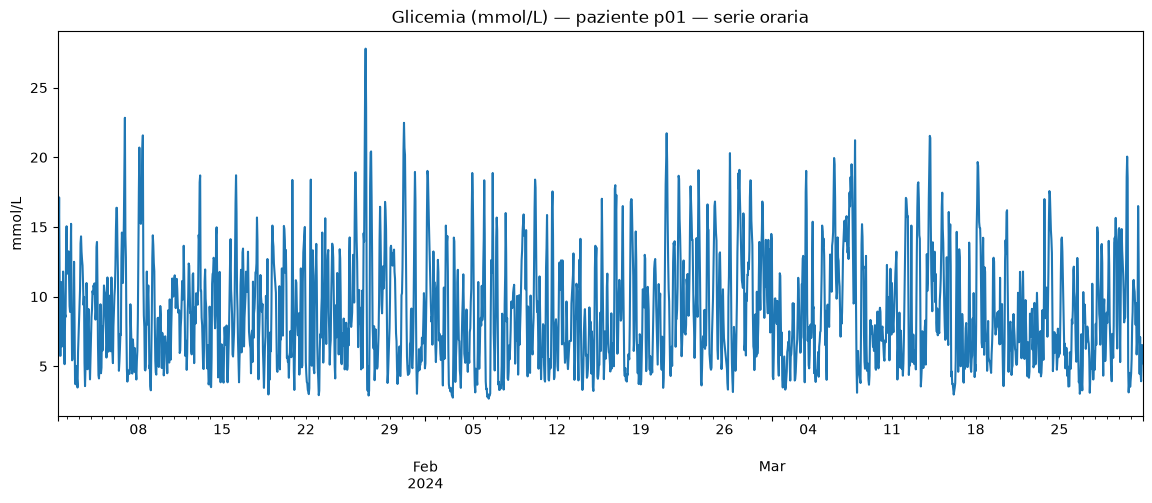

In [15]:
fig, ax = plt.subplots()
bg_hourly.plot(ax=ax, title=f"Glicemia (mmol/L) — paziente {PATIENT} — serie oraria")
ax.set_ylabel("mmol/L")
plt.show()

La serie presenta un'elevata variabilità, con fisiologici cali verso la soglia dell'ipoglicemia (circa 3 mmol/L) ed evidenti picchi di iperglicemia (frequentemente oltre i 15 mmol/L, con un picco massimo isolato vicino ai 28 mmol/L).



Per ovviare all'anomalia visiva delle date converto l'asse orizzontale in **"Giorni di monitoraggio"** trascorsi dall'attivazione del sensore:

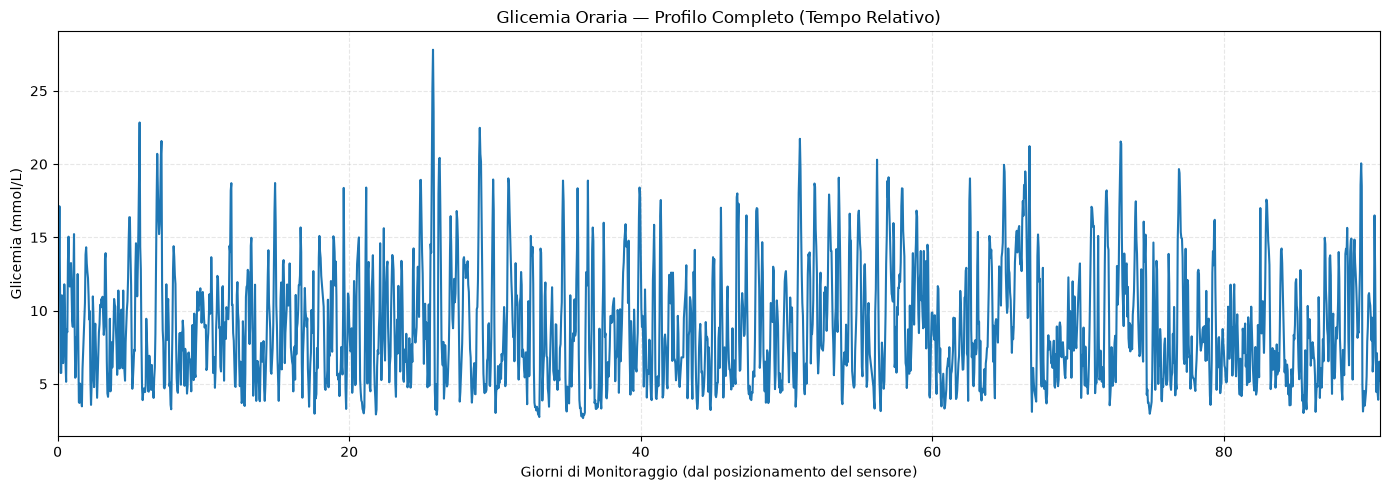

In [16]:
fig, ax = plt.subplots(figsize=(14, 5))
# Calcolo del tempo trascorso (in giorni continui) dalla primissima misurazione
giorni_trascorsi = (bg_hourly.index - bg_hourly.index.min()).total_seconds() / (24 * 3600)

ax.plot(giorni_trascorsi, bg_hourly.values, color='#1f77b4')

ax.set_title("Glicemia Oraria — Profilo Completo (Tempo Relativo)")
ax.set_xlabel("Giorni di Monitoraggio (dal posizionamento del sensore)")
ax.set_ylabel("Glicemia (mmol/L)")

# Aggiunta di una griglia per agevolare la lettura dei valori
ax.grid(True, alpha=0.3, linestyle='--')
plt.xlim(0, giorni_trascorsi.max())
plt.tight_layout()
plt.show()

Lo step successivo è stato quello di informarmi sulle specifiche del Diabete per capire se i miei dati fossero in range o meno e per capire quali sono i valori che indicano glicemia bassa o alta:

Le linee guida ADA/ISPAD definiscono il target range standard in 3.9-10.0 mmol/L. In questo grafico:
- i minimi intorno a 3 mmol/L toccano la soglia di ipoglicemia di livello 2 (rischio clinico acuto);
- il picco isolato a ~28 mmol/L intorno al giorno 25 è un episodio di iperglicemia severa di livello 2, ben oltre il range target.

In generale gli obiettivi di TIR (Time in Range), per la maggior parte delle persone con diabete di tipo 1 o tipo 2:

| Categoria | mg/dL | mmol/L | Obiettivo |
|:----------|------:|--------:|:----------|
| 🟢 Intervallo ideale (Target Range) | 70–180 | **3,9–10,0** | **>70% del tempo (≥17 ore/giorno)** |
| 🔵 Ipoglicemia | <70 | **<3,9** | **<4% del tempo (<58 min/giorno)** |
| 🔴 Ipoglicemia significativa | <54 | **<3,0** | **<1% del tempo (<14 min/giorno)** |
| 🟠 Iperglicemia | >180 | **>10,0** | **<25% del tempo (<6 ore/giorno)** |
| 🔴 Iperglicemia marcata | >250 | **>13,9** | **<5% del tempo (<1 h 12 min/giorno)** |


> **Nota:**  Gli obiettivi possono essere personalizzati dal medico in base all'età, al rischio di ipoglicemia e ad altre condizioni cliniche.

Oltre alle statistiche descrittive standard, ho calcolato il **Time in Range (TIR)** — la
percentuale di tempo trascorsa dal paziente all'interno del range glicemico target
(3.9-10.0 mmol/L secondo le linee guida ADA/ISPAD), insieme al Time Below Range (rischio di
ipoglicemia) e Time Above Range (iperglicemia). Il TIR è oggi lo standard clinico di
riferimento per valutare il controllo glicemico nei pazienti con CGM.

In [17]:
# Definizione dei limiti clinici (in mmol/L)
limite_inf = 3.9
limite_sup = 10.0

# Rimuovo i NaN per assicurarmi che il denominatore includa solo i dati reali
serie_valida = bg_interp.dropna()

# Creo le condizioni logiche (maschere booleane)
in_range = (serie_valida >= limite_inf) & (serie_valida <= limite_sup)
below_range = serie_valida < limite_inf
above_range = serie_valida > limite_sup

# Calcolo la percentuale utilizzando il metodo .mean() 
# (che converte i True in 1 e i False in 0, restituendo la proporzione esatta)
tir_pct = in_range.mean() * 100
tbr_pct = below_range.mean() * 100
tar_pct = above_range.mean() * 100

# Stampa dei risultati
print("=== Analisi del Controllo Glicemico ===")
print(f"Time in Range (3.9 - 10.0 mmol/L): {tir_pct:.1f}%")
print(f"Time Below Range (< 3.9 mmol/L):   {tbr_pct:.1f}%")
print(f"Time Above Range (> 10.0 mmol/L):  {tar_pct:.1f}%")

# Verifica matematica: la somma deve fare 100%
somma_totale = tir_pct + tbr_pct + tar_pct
print(f"\nVerifica integrità calcolo (deve essere 100.0%): {somma_totale:.1f}%")

=== Analisi del Controllo Glicemico ===
Time in Range (3.9 - 10.0 mmol/L): 58.5%
Time Below Range (< 3.9 mmol/L):   6.6%
Time Above Range (> 10.0 mmol/L):  34.8%

Verifica integrità calcolo (deve essere 100.0%): 100.0%


Dopo aver osservato l'andamento dei miei dati sentivo il bisogno di capire di più, per questo sull'asse delle ascisse ho provato a sostituire il giorno di monitoraggio all'ora in cui è stata effettuata la misurazione.

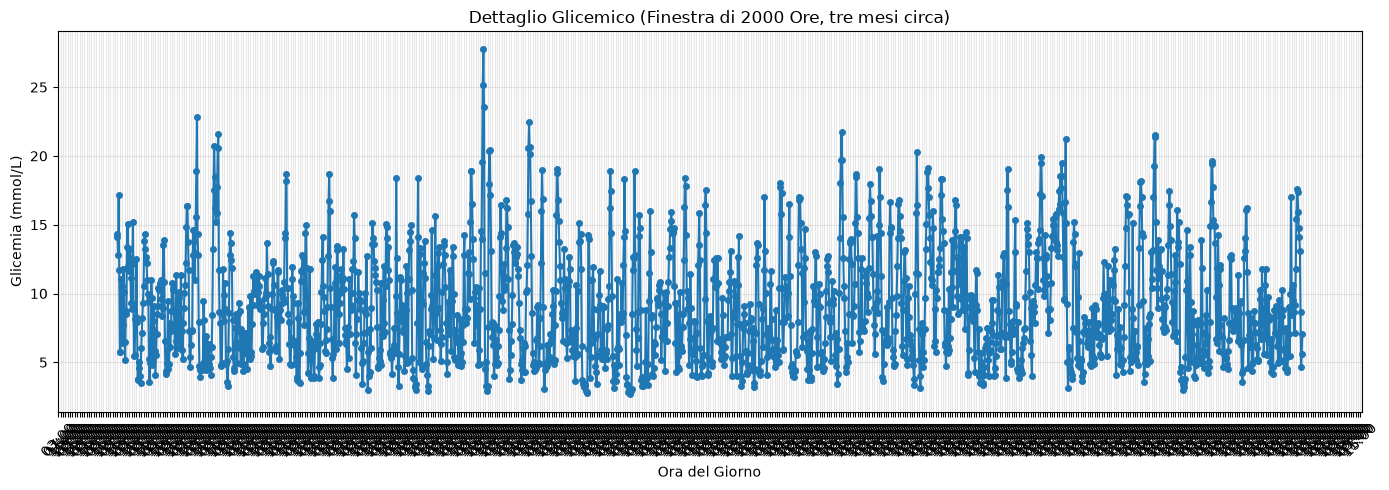

In [18]:
import matplotlib.dates as mdates
# Estraiamo un segmento ridotto, ad esempio le prime 72 ore di registrazione
campione_breve = bg_hourly.iloc[:2000] 

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(campione_breve.index, campione_breve.values, marker='o', markersize=4)

# Istruiamo matplotlib a mostrare esclusivamente Ore e Minuti
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

# Impostiamo un indicatore (tick) esattamente ogni 4 ore per una lettura clinica chiara
ax.xaxis.set_major_locator(mdates.HourLocator(interval=4))

ax.set_title("Dettaglio Glicemico (Finestra di 2000 Ore, tre mesi circa)")
ax.set_xlabel("Ora del Giorno")
ax.set_ylabel("Glicemia (mmol/L)")

ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

La label dell'asse delle ascisse è incmprensibile per questo ho deciso di passare alla visualizzazione con le box-plot, meglio detto :Profilo Giornaliero Aggregato (Daily Profile):

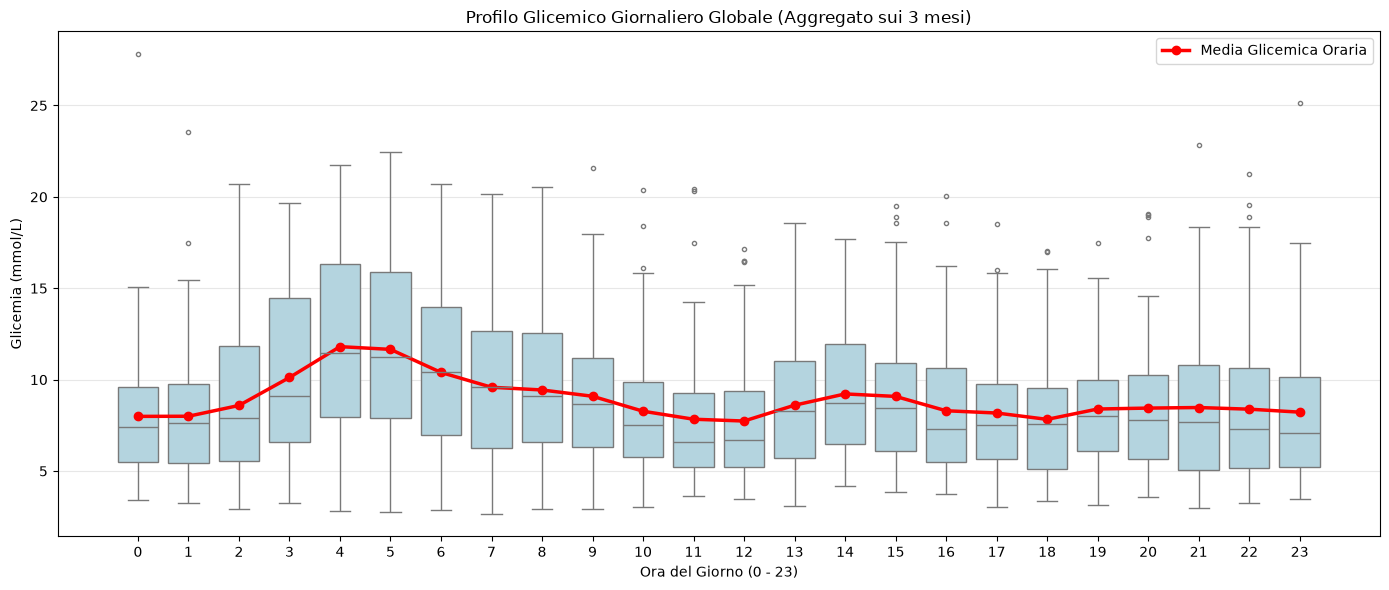

In [19]:
# Preparazione dei dati: estraggo l'ora dall'indice
df_analisi_oraria = bg_hourly.to_frame(name='bg')
df_analisi_oraria['Ora_del_Giorno'] = df_analisi_oraria.index.hour

fig, ax = plt.subplots(figsize=(14, 6))

# Creazione del Boxplot: distribuzione dei valori per ogni singola ora
sns.boxplot(
    x='Ora_del_Giorno', 
    y='bg', 
    data=df_analisi_oraria, 
    ax=ax, 
    color='lightblue',
    fliersize=3 # Dimensione dei punti anomali (outlier)
)

# Calcolo e sovrapposizione del Trend Medio
medie_orarie = df_analisi_oraria.groupby('Ora_del_Giorno')['bg'].mean()
ax.plot(
    medie_orarie.index, 
    medie_orarie.values, 
    color='red', 
    linewidth=2.5, 
    marker='o', 
    label='Media Glicemica Oraria'
)

#  Formattazione del grafico
ax.set_title("Profilo Glicemico Giornaliero Globale (Aggregato sui 3 mesi)")
ax.set_xlabel("Ora del Giorno (0 - 23)")
ax.set_ylabel("Glicemia (mmol/L)")
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

L'aggregazione per ora del giorno (boxplot orario) rivela un
pattern circadiano riconoscibile, con un incremento marcato nelle prime ore del mattino
compatibile con il cosiddetto **dawn phenomenon** — un fenomeno fisiologico ben documentato
nella letteratura sul diabete, dovuto al rilascio di ormoni contro-regolatori (cortisolo,
ormone della crescita) che inducono il fegato a rilasciare glucosio indipendentemente
dall'assunzione di cibo.

## 5. Decomposizione della serie: trend, stagionalità, residuo
### Cos'è la decomposizione STL e perché si usa

STL (**Seasonal-Trend decomposition using Loess**) scompone una serie storica nella somma di
tre componenti: `y_t = Trend_t + Stagionalità_t + Residuo_t`. A differenza della
decomposizione classica additiva, che stima un pattern stagionale fisso e identico su tutto
il periodo di osservazione, STL utilizza la regressione locale pesata (Loess) sia per il
trend sia per la stagionalità, permettendo a quest'ultima di **variare in ampiezza nel
tempo**. Questa proprietà è particolarmente rilevante per un segnale fisiologico come la
glicemia, dove l'intensità delle oscillazioni giornaliere (dovute principalmente ai pasti)
non è costante ma dipende dalle abitudini specifiche di ciascun periodo.

Ho impostato `period=24` (ore), coerentemente con l'ipotesi di un ritmo circadiano, e
`robust=True` per ridurre la sensibilità della stima agli outlier — frequenti in questo
dominio a causa degli episodi acuti di iper/ipoglicemia.

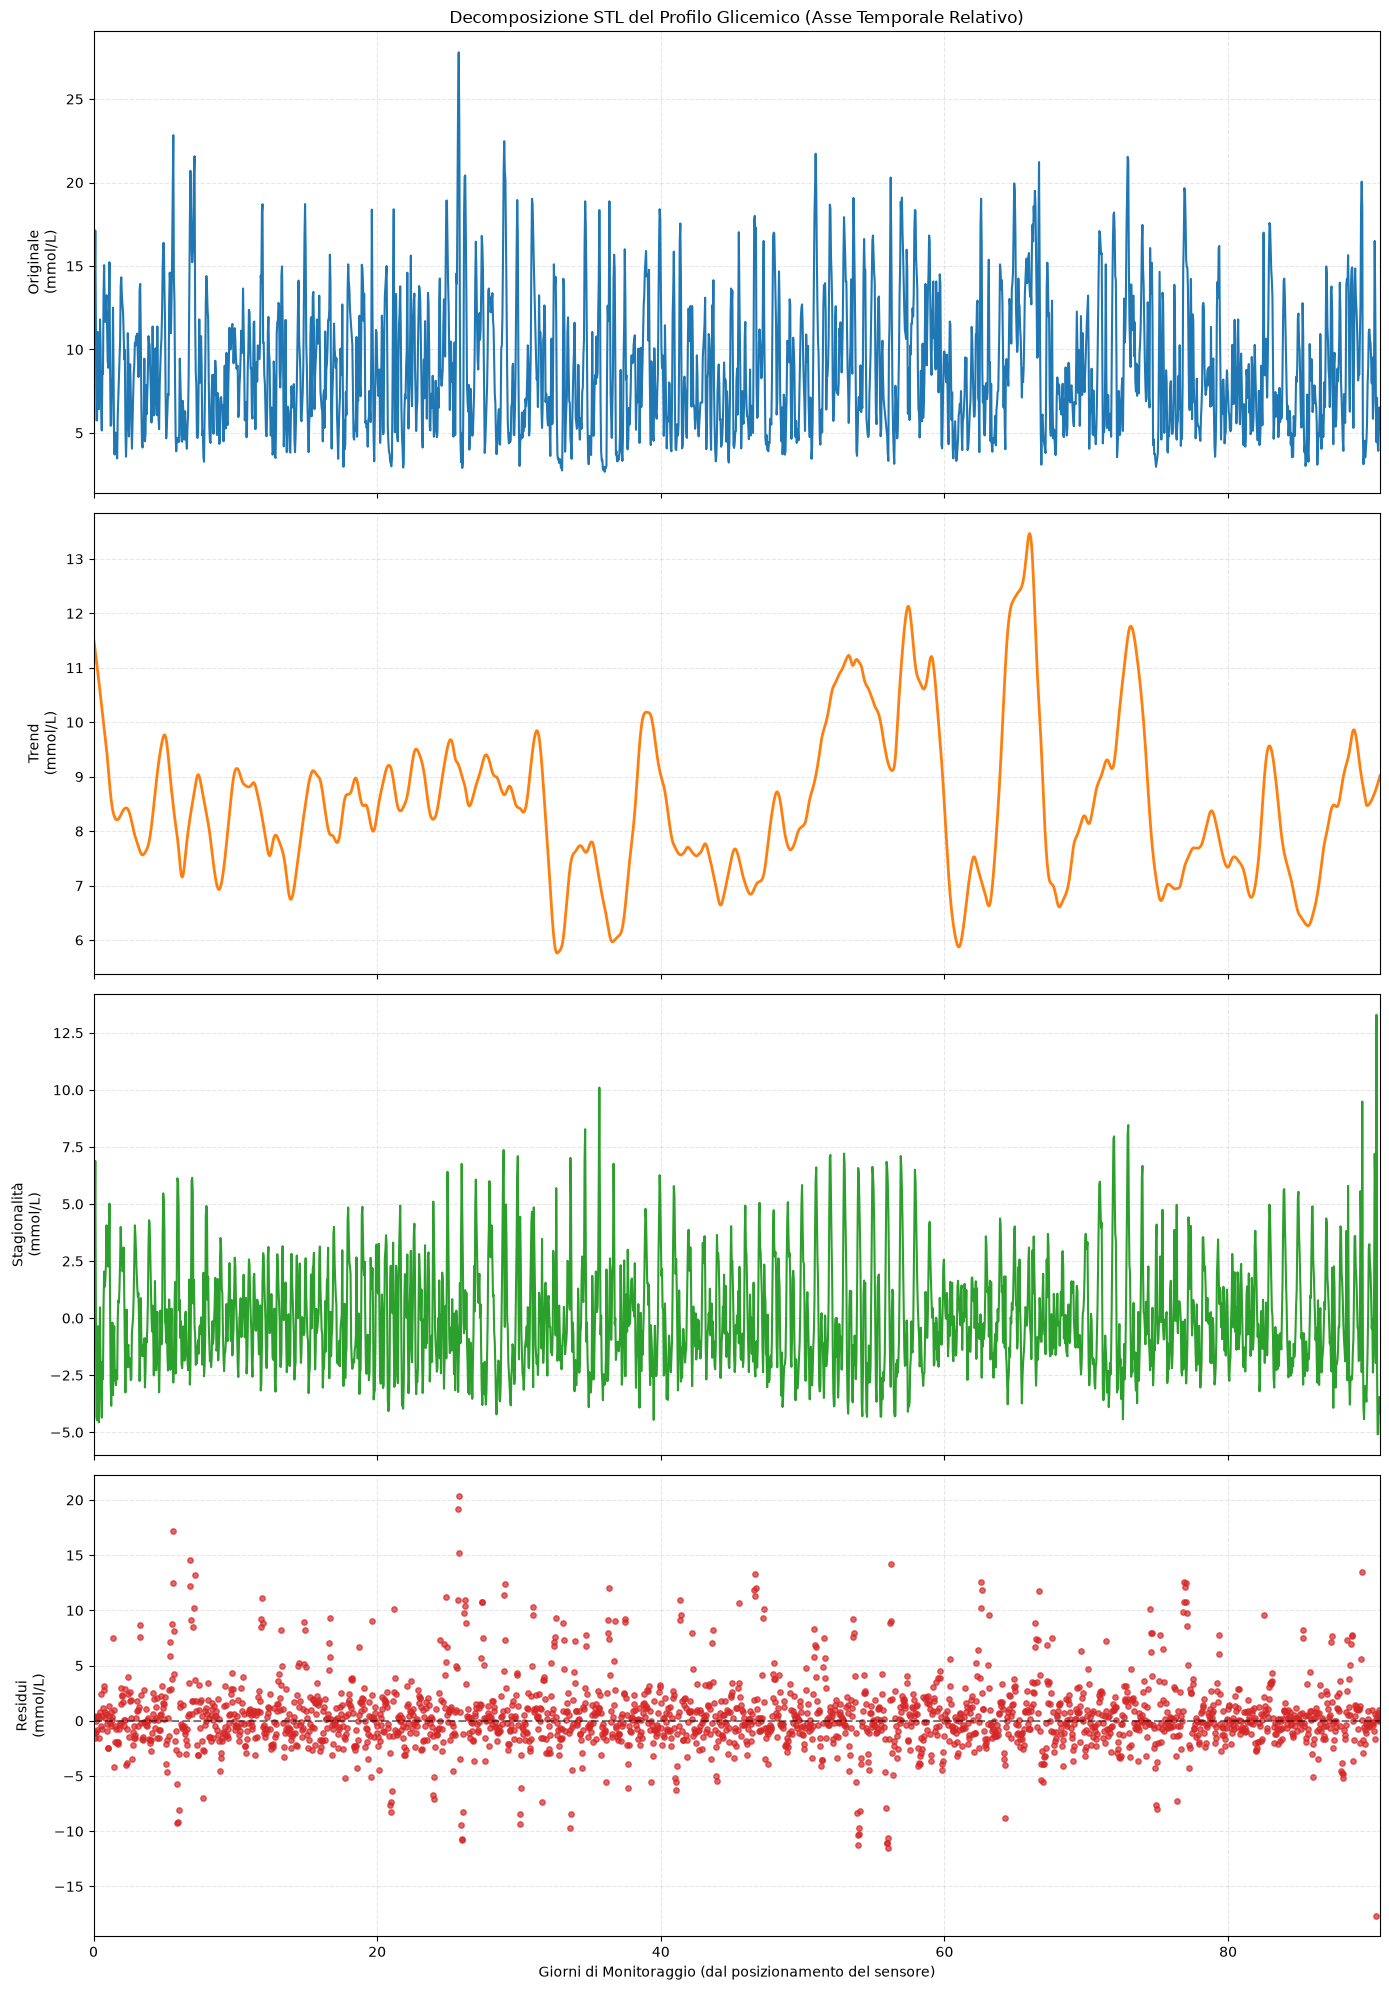

In [20]:
# 1. Esecuzione della decomposizione STL
# Imposto period=24 (essendo dati orari) e robust=True per mitigare l'effetto dei picchi anomali
stl = STL(bg_hourly, period=24, robust=True)
res = stl.fit()

# 2. Calcolo dell'asse temporale relativo (giorni trascorsi da inizio monitoraggio)
giorni_trascorsi = (bg_hourly.index - bg_hourly.index.min()).total_seconds() / (24 * 3600)


fig, axes = plt.subplots(4, 1, figsize=(14, 20), sharex=True)

# A. Serie Originale
axes[0].plot(giorni_trascorsi, res.observed, color='#1f77b4')
axes[0].set_ylabel('Originale\n(mmol/L)')
axes[0].set_title('Decomposizione STL del Profilo Glicemico (Asse Temporale Relativo)')

# B. Trend
axes[1].plot(giorni_trascorsi, res.trend, color='#ff7f0e', linewidth=2)
axes[1].set_ylabel('Trend\n(mmol/L)')

# C. Stagionalità
axes[2].plot(giorni_trascorsi, res.seasonal, color='#2ca02c')
axes[2].set_ylabel('Stagionalità\n(mmol/L)')

# D. Residui
axes[3].scatter(giorni_trascorsi, res.resid, color='#d62728', marker='o', s=15, alpha=0.7)
# Aggiunta di una linea dello zero per valutare visivamente la distribuzione dei residui
axes[3].axhline(0, color='black', linestyle='--', alpha=0.5)
axes[3].set_ylabel('Residui\n(mmol/L)')
axes[3].set_xlabel('Giorni di Monitoraggio (dal posizionamento del sensore)')

# Formattazione con i giorni trascorsi piuttosto delle date fittizie
for ax in axes:
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_xlim(0, giorni_trascorsi.max())

plt.tight_layout()

### Lettura dei risultati

- **Trend**: mostra oscillazioni non trascurabili su scala di giorni (tra 6 e 13.5 mmol/L),
  più ampie di quanto un trend "di fondo" dovrebbe mostrare per definizione. Questo pattern non è molto chiaro, forse vi sono delle stagionalità aggiuntive (ad esempio settimanali, perchè le abituzini cambiano nel weekend) che non sono state considerate.
- **Stagionalità**: conferma un ciclo circadiano reale, con ampiezza variabile nel tempo —
  alcuni periodi mostrano oscillazioni giornaliere molto più marcate di altri, verosimilmente
  legate a pasti più abbondanti o dosaggi insulinici meno precisi in quei giorni.
- **Residuo**: centrato su zero e privo di pattern sistematico evidente, ma con ampiezza non
  trascurabile (fino a ±20 mmol/L in alcuni punti) — un segnale che una parte sostanziale
  della variabilità glicemica non è spiegata dalla sola periodicità oraria, ed è
  verosimilmente legata a eventi esogeni (pasti, boli insulinici, attività fisica) che un
  modello puramente temporale non può catturare.

### Boxplot orario delle componenti STL

Aggregando trend e stagionalità per ora del giorno ho ottenuto una doppia verifica: la
stagionalità mostra il profilo circadiano atteso (picco mattutino compatibile col dawn
phenomenon), mentre il trend risulta **pressoché identico** in tutte le 24 ore — una
conferma che la decomposizione ha separato correttamente la componente lenta (trend) da
quella circadiana (stagionalità): se la stagionalità fosse "colata" nel trend, ci si
aspetterebbe un trend sistematicamente diverso a seconda dell'ora considerata.

In [21]:
#i risultati della decomposizione in un DataFrame
df_stl = pd.DataFrame({
    'Osservato': res.observed,
    'Trend': res.trend,
    'Stagionalità': res.seasonal,
    'Residui': res.resid,
    'Ora': res.resid.index.hour,
    'Giorno_Relativo': (res.resid.index - res.resid.index.min()).days
})

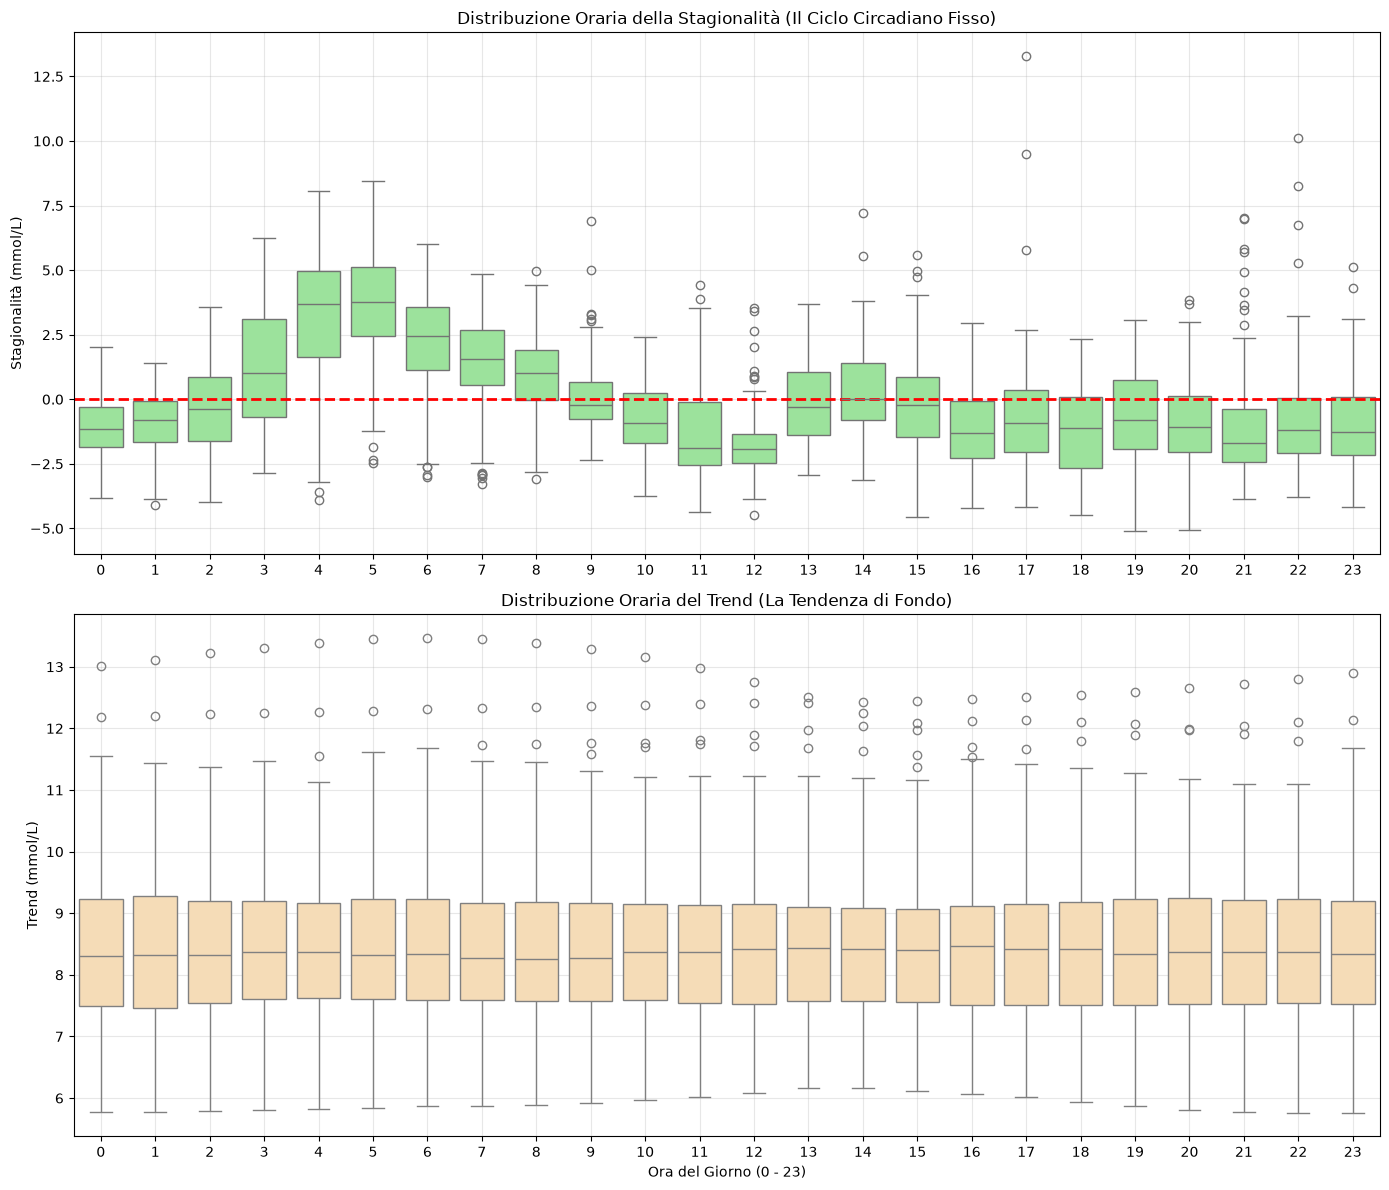

In [22]:
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# 1. Boxplot Orario della STAGIONALITÀ
sns.boxplot(
    x='Ora', 
    y='Stagionalità', 
    data=df_stl, 
    ax=axes[0], 
    color='lightgreen'
)
axes[0].set_title("Distribuzione Oraria della Stagionalità (Il Ciclo Circadiano Fisso)")
axes[0].set_ylabel("Stagionalità (mmol/L)")
axes[0].set_xlabel("") # Nascondiamo l'etichetta X per pulizia visiva
axes[0].grid(True, alpha=0.3)
axes[0].axhline(0, color='red', linewidth=2, linestyle='--')
# 2. Boxplot Orario del TREND
sns.boxplot(
    x='Ora', 
    y='Trend', 
    data=df_stl, 
    ax=axes[1], 
    color='navajowhite'
)
axes[1].set_title("Distribuzione Oraria del Trend (La Tendenza di Fondo)")
axes[1].set_xlabel("Ora del Giorno (0 - 23)")
axes[1].set_ylabel("Trend (mmol/L)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

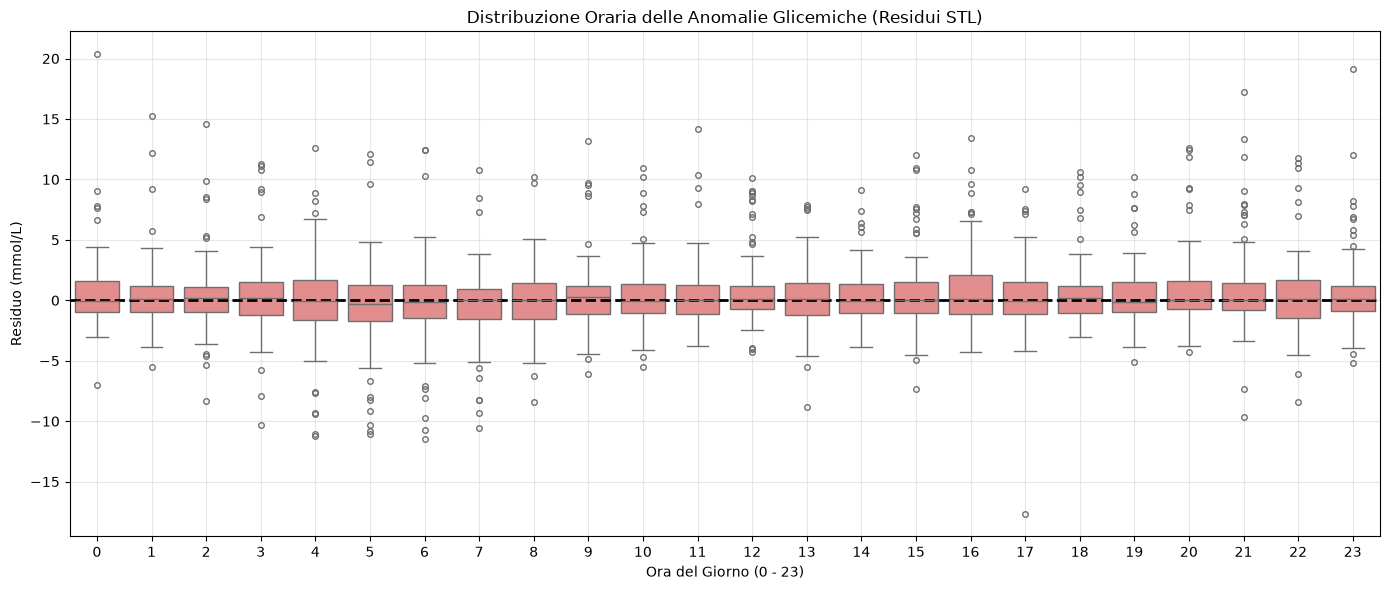

In [23]:
#box-plot dei residui 
fig, ax = plt.subplots(figsize=(14, 6))

sns.boxplot(
    x='Ora', 
    y='Residui', 
    data=df_stl, 
    ax=ax, 
    color='lightcoral',
    fliersize=4
)


ax.axhline(0, color='black', linewidth=2, linestyle='--')

ax.set_title("Distribuzione Oraria delle Anomalie Glicemiche (Residui STL)")
ax.set_xlabel("Ora del Giorno (0 - 23)")
ax.set_ylabel("Residuo (mmol/L)")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Verifica della stazionarietà
I modelli ARIMA assumono che la serie (dopo eventuale differenziazione) sia stazionaria,
cioè che le sue proprietà statistiche (media, varianza, covarianza) non cambino nel
tempo. Ho utilizzato due test con ipotesi nulla opposta:

- **ADF (Augmented Dickey-Fuller)**: ipotesi nulla H0 = "la serie ha una radice unitaria"
  (non è stazionaria). Un p-value basso porta a rifiutare H0, concludendo stazionarietà.
- **KPSS**: ipotesi nulla opposta, H0 = "la serie è stazionaria". Un p-value basso porta a
  rifiutare H0, concludendo non stazionarietà.

Usare entrambi i test permette di distinguere tra diversi tipi di non-stazionarietà (radice
unitaria vs trend deterministico) che un singolo test potrebbe non cogliere adeguatamente.

In [24]:
def adf_report(x, label):
    # H0 dell'ADF: la serie ha una radice unitaria (NON stazionaria).
    # p-value basso -> rifiuto H0 ->  stazionarietà
    stat, pval, *_ = adfuller(x.dropna())
    print(f"[ADF]  {label}: statistic={stat:.3f}  p-value={pval:.4f}  "
          f"-> {'stazionaria' if pval < 0.05 else 'NON stazionaria'} (alpha=0.05)")

def kpss_report(x, label):
    # H0 del KPSS: la serie E' stazionaria (ipotesi opposta all'ADF, per triangolazione)
    # p-value basso -> rifiuto H0 -> NON stazionarietà
    stat, pval, *_ = kpss(x.dropna(), regression="c", nlags="auto")
    print(f"[KPSS] {label}: statistic={stat:.3f}  p-value={pval:.4f}  "
          f"-> {'stazionaria' if pval > 0.05 else 'NON stazionaria'} (alpha=0.05)")

print("=== LIVELLO (serie originale) ===")
adf_report(bg_hourly, "livello")
kpss_report(bg_hourly, "livello")


# la faccio già nel caso in cui la serie non sia stazionaria, così da poterla rendere stazionaria e poter fare previsioni più accurate
bg_diff = bg_hourly.diff().dropna()
print("\n=== DIFFERENZA NON STAGIONALE (d=1) ===")
adf_report(bg_diff, "differenza I(1)")
kpss_report(bg_diff, "differenza I(1)")

=== LIVELLO (serie originale) ===
[ADF]  livello: statistic=-18.861  p-value=0.0000  -> stazionaria (alpha=0.05)
[KPSS] livello: statistic=0.095  p-value=0.1000  -> stazionaria (alpha=0.05)

=== DIFFERENZA NON STAGIONALE (d=1) ===
[ADF]  differenza I(1): statistic=-15.582  p-value=0.0000  -> stazionaria (alpha=0.05)
[KPSS] differenza I(1): statistic=0.030  p-value=0.1000  -> stazionaria (alpha=0.05)


/var/folders/p5/scr9c3992_s_tysh3x8dt1c00000gn/T/ipykernel_36097/3631545439.py:11: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, pval, *_ = kpss(x.dropna(), regression="c", nlags="auto")
/var/folders/p5/scr9c3992_s_tysh3x8dt1c00000gn/T/ipykernel_36097/3631545439.py:11: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, pval, *_ = kpss(x.dropna(), regression="c", nlags="auto")


Sia ADF sia KPSS concordano nell'indicare che la serie di livello è **già stazionaria**
(ADF: p<0.0001; KPSS: p=0.10, non rifiuta). Questo risultato ha una spiegazione fisiologica
diretta: la glicemia è un processo **omeostatico** — il corpo la regola attivamente
attraverso meccanismi ormonali per riportarla verso un range fisiologico — e tende quindi ad
essere **mean-reverting**, tornando verso un livello medio piuttosto che allontanarsene
indefinitamente come farebbe un vero random walk (il comportamento tipico di una serie non
stazionaria con radice unitaria). Di conseguenza, il parametro di differenziazione non
stagionale è `d=0`.

## 7. Analisi di autocorrelazione (ACF/PACF)
L'**ACF** (funzione di autocorrelazione) misura la correlazione totale (diretta e indiretta)
tra la serie e se stessa a diversi ritardi temporali (lag). La **PACF** (autocorrelazione
parziale) misura invece la correlazione diretta tra la serie e un lag specifico, al netto
dell'effetto di tutti i lag intermedi. La combinazione delle due forme è la base empirica
classica per identificare gli ordini di un modello ARMA:

- Una PACF che si **annulla bruscamente** dopo il lag *p*, con una ACF che decade
  gradualmente, è la firma di un processo **autoregressivo AR(p)**.
- Una ACF che si annulla bruscamente dopo il lag *q*, con una PACF che decade gradualmente,
  è la firma di un processo a **media mobile MA(q)**.


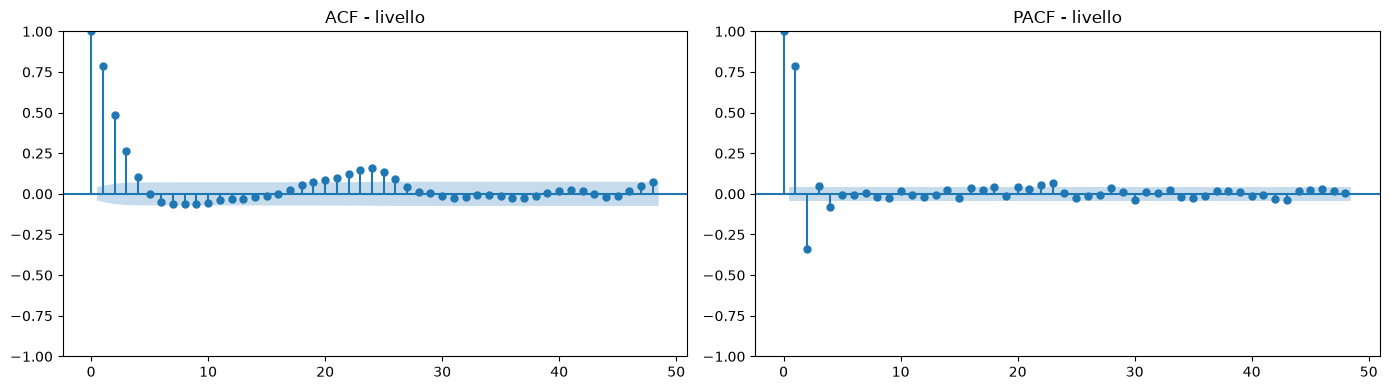

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(bg_hourly, lags=48, ax=axes[0])
plot_pacf(bg_hourly, lags=48, ax=axes[1], method="ywm")
axes[0].set_title("ACF - livello")
axes[1].set_title("PACF - livello")
plt.tight_layout()
plt.show()

Sulla serie di livello, la PACF mostra un troncamento netto dopo il secondo lag, mentre la
ACF decade gradualmente — la firma tipica di un processo **AR(2)**. 

A questo punto del progetto sto pensando a un SARIMA(2,0,0).

Nel grafico ACF vedo una gobba al lag 24, questo mi suggerisce una prima conferma sulla stagionalità ipotizzata.

## 8. Suddivisione temporale dei dati e modelli di riferimento (baseline)
Con le serie storiche, uno split casuale (o k-fold classico) introdurrebbe **data leakage
temporale**: il modello potrebbe usare informazioni future per prevedere il passato,
producendo stime di performance illusoriamente ottimistiche. Riservo quindi le ultime ore
della serie come **validation set**, mai utilizzato durante la stima dei parametri dei
modelli, per simulare realisticamente uno scenario di previsione del futuro non ancora
osservato.


In [26]:
# ultimi 7 giorni (168 ore) come validation set
validation_hours = 24 * 7
train = bg_hourly.iloc[:-validation_hours]
validation = bg_hourly.iloc[-validation_hours:]


Prima di procedere ho ritenuto necessario valutare la necessità dell'introduzione della stagionalità nel modello allenando un ARIMA (2,0,0) (parametri osservati con l'analisi esposta sopra):

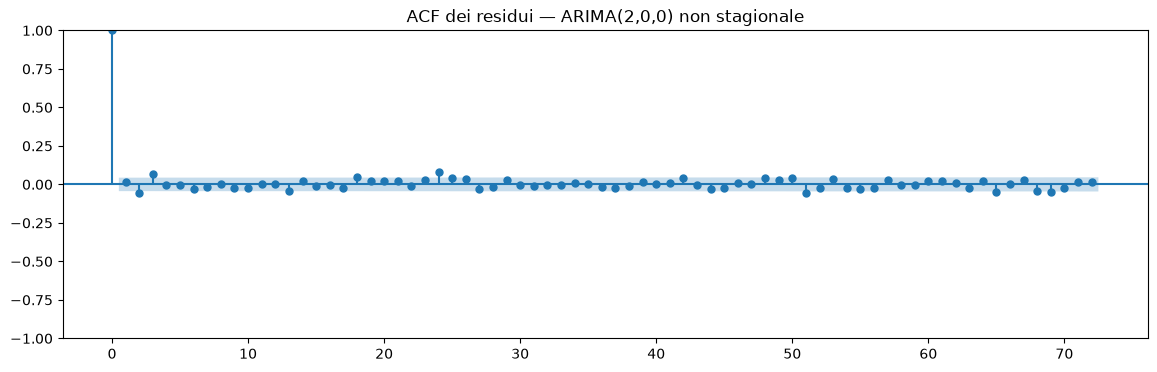

      lb_stat  lb_pvalue
24  47.087831   0.003268
48  69.922478   0.021080


In [27]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox

arima_naive = ARIMA(train, order=(2,0,0)).fit()
resid = arima_naive.resid

fig, ax = plt.subplots(figsize=(14,4))
plot_acf(resid, lags=72, ax=ax)
ax.set_title("ACF dei residui — ARIMA(2,0,0) non stagionale")
plt.show()

lb = acorr_ljungbox(resid, lags=[24, 48], return_df=True)
print(lb)

I numeri confermano la diagnosi visiva . Con p-value pari a 0.0032 (al lag 24) e 0.0210 (al lag 48), indicano che mi trovo ampiamente al di sotto della soglia di significatività statistica dello 0.05. 

Questo mi impone di rifiutare l'ipotesi nulla H_0: i residui del modello attuale non sono indipendenti e nascondono ancora un pattern altamente prevedibile (quindi rifiuto l'ipotesi di white noise).

L'autocorrelogramma, inoltre, mostra che la quasi totalità dei residui ricade correttamente all'interno della banda azzurra di confidenza, avvicinandosi al comportamento del white noise. 

Tuttavia, si staglia un picco evidente e statisticamente anomalo in corrispondenza esatta del lag 24 (quindi si esce dai Markovian Tresholds). Questo è il segno grafico tangibile che il ritmo circadiano non è stato assorbito dall'algoritmo.

L'architettura ARIMA(2,0,0) "piatta" ha fallito: non possiede gli strumenti matematici per comprendere che ogni 24 ore il metabolismo compie un ciclo completo.

È indispensabile sbloccare la componente stagionale dell'algoritmo.



### Le baseline naive

Prima di introdurre modelli più sofisticati, ho stabilito due riferimenti minimi con cui
giudicare se la complessità aggiuntiva è giustificata (essi sono i due Gold Standard da raggiungere con i modelli successivi):

- **Naive persistence**: prevede che il valore tra un'ora sarà uguale a quello attuale.
  Utile perché la glicemia mostra forte autocorrelazione a breve termine.
- **Naive seasonal**: prevede che il valore tra un'ora sarà uguale a quello osservato 24 ore
  prima, alla stessa ora. Utile per verificare quanto valore aggiunge realmente la
  stagionalità circadiana già dimostrata.



In [28]:
#alleno prima una baseline contro cui confrontare i modelli che vado a implementare
# Baseline 1: Naive persistence — "tra 1h sarà come ora"
# Utile perché la glicemia ha alta autocorrelazione a breve termine (vista in ACF/PACF)
naive_persistence_pred = pd.concat([train, validation]).shift(1).loc[validation.index]

# Baseline 2: Naive seasonal — "tra 1h sarà come 24h fa alla stessa ora"
# Utile perché ho dimostrato il dawn phenomenon / stagionalità circadiana
naive_seasonal_pred = pd.concat([train, validation]).shift(24).loc[validation.index]

def compute_metrics(y_true, y_pred, label):
    mask = y_true.notna() & y_pred.notna()
    y_true, y_pred = y_true[mask], y_pred[mask]
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = (np.abs((y_true - y_pred) / y_true)).mean() * 100
    print(f"{label:20s} | MAE={mae:.3f}  RMSE={rmse:.3f}  MAPE={mape:.2f}%")
    return {"model": label, "MAE": mae, "RMSE": rmse, "MAPE": mape}

results = []
results.append(compute_metrics(validation, naive_persistence_pred, "Naive (persistence, lag 1h)"))
results.append(compute_metrics(validation, naive_seasonal_pred, "Naive (seasonal, lag 24h)"))

Naive (persistence, lag 1h) | MAE=1.892  RMSE=2.604  MAPE=25.49%
Naive (seasonal, lag 24h) | MAE=3.289  RMSE=4.297  MAPE=45.28%


## 9. Modellazione SARIMA
SARIMA (**Seasonal AutoRegressive Integrated Moving Average**) estende il modello ARIMA
classico aggiungendo una componente stagionale esplicita. È indicato con la notazione
**SARIMA(p, d, q)(P, D, Q)m**, dove:

- **p, d, q**: rispettivamente l'ordine autoregressivo (dipendenza dai valori passati),
  l'ordine di differenziazione (per rendere la serie stazionaria) e l'ordine a media mobile
  (dipendenza dagli errori di previsione passati) della componente non stagionale.
- **P, D, Q**: gli stessi tre concetti applicati alla componente stagionale, cioè ai lag
  multipli del periodo *m*.
- **m**: il periodo della stagionalità (in questo progetto, m=24, un ciclo circadiano).

Concettualmente, il modello prevede il valore futuro come combinazione lineare di: 
(a) i
propri valori passati recenti (componente AR), (b) i propri valori passati alla stessa fase
del ciclo stagionale (componente AR stagionale), e (c) gli errori di previsione commessi in
passato (componenti MA). È un modello **lineare**, stimato per massima verosimiglianza, e
richiede che la serie (eventualmente dopo differenziazione) sia stazionaria — da cui la
necessità di tutta l'analisi delle sezioni precedenti.


### Determinazione degli ordini
I parametri non stagionali son stati già ipotizzati nella sezione precedente, in questa sesione mi concentro sulla determinazione delle componenti stagionali.

Ho iniziato ispezionando ACF e PACF sui lag multipli di 24:

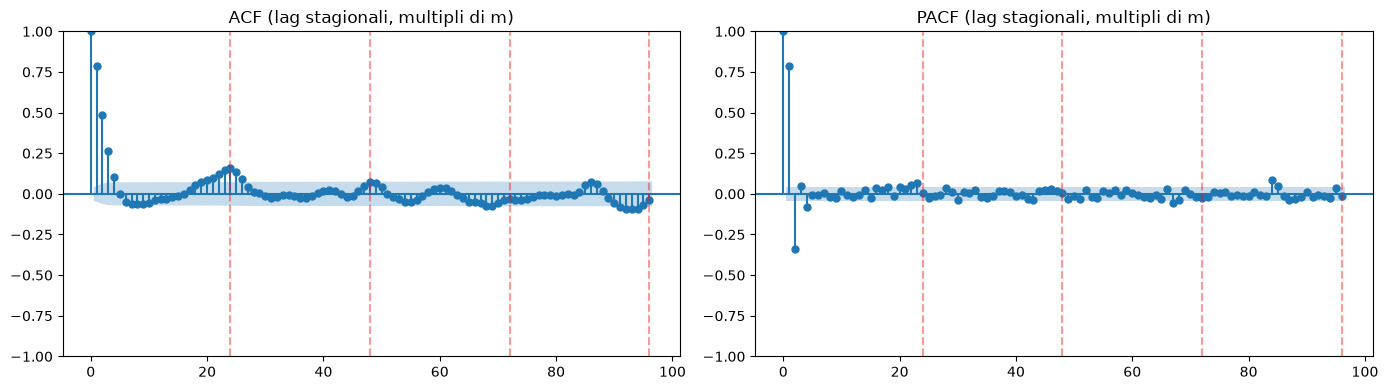

In [29]:
# ACF/PACF sui lag stagionali (multipli di m) per determinare P, Q
m=24
seasonal_lags = 4  # guarda fino a 4*m (es. 4 giorni indietro se m=24)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(bg_hourly, lags=seasonal_lags * m, ax=axes[0])
plot_pacf(bg_hourly, lags=seasonal_lags * m, ax=axes[1], method="ywm")
axes[0].set_title("ACF (lag stagionali, multipli di m)")
axes[1].set_title("PACF (lag stagionali, multipli di m)")
for ax in axes:
    for k in range(1, seasonal_lags + 1):
        ax.axvline(k * m, color="red", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


L'attenzione qui deve concentrarsi esclusivamente su ciò che accade in prossimità delle linee tratteggiate rosse (lag 24, 48, 72):

- PACF stagionale: nessuno spike chiaro esattamente a 24, 48, 72 → suggerisce P=0.
- ACF stagionale: un rialzo modesto ma visibile intorno al lag 24 (e più debole a 48, 72) → potrebbe suggerire Q=1 (una componente MA stagionale debole).


Se si guarda l'ACF stagionale si nota un solo picco al lag 24 ma si affievolisce man mano che si va avanti, una vera radice unitaria stagionale si manifesta con un ACF che non decade ai multipli del periodo ma resta alta.

L'andamento che osservo è coerente con D=0, per avere conferma ho effettuato il **test OCSB**, questo perchè per la componente stagionale, i test ADF/KPSS generici non sono appropriati (sono pensati
per radici unitarie non stagionali), questo test è stato concepito per determinare se sia necessaria una
differenziazione stagionale, confermato da un secondo test (Canova-Hansen) come controllo di
robustezza. 


   

In [30]:
# Test OCSB (Osborn-Chui-Smith-Birchenhall) — pensato specificamente
# per decidere se serve differenziazione stagionale
D_ocsb = pm.arima.nsdiffs(bg_hourly, m=24, test="ocsb", max_D=2)
print(f"D suggerito da OCSB: {D_ocsb}")

# Test alternativo: Canova-Hansen (spesso più conservativo di OCSB)
D_ch = pm.arima.nsdiffs(bg_hourly, m=24, test="ch", max_D=2)
print(f"D suggerito da Canova-Hansen: {D_ch}")

D suggerito da OCSB: 0
D suggerito da Canova-Hansen: 0


Entrambi concordano su `D=0`: la stagionalità è presente ma stazionaria, gestibile
tramite i termini AR/MA stagionali del modello piuttosto che tramite differenziazione stagionale.


Ho utilizzato 
`pmdarima.auto_arima` per una ricerca automatica stepwise basata sul criterio AIC (Akaike
Information Criterion), vincolata entro i range plausibili già identificati manualmente.

In [31]:
auto_model = pm.auto_arima(
    train, seasonal=True, m=24,
    start_p=0, start_q=0, max_p=3, max_q=3,
    start_P=0, start_Q=0, max_P=2, max_Q=2,
    d=None, D=None, trace=True,
    error_action="ignore", suppress_warnings=True, stepwise=True,
)
print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[24] intercept   : AIC=11264.756, Time=0.03 sec
 ARIMA(1,0,0)(1,0,0)[24] intercept   : AIC=9297.529, Time=1.80 sec
 ARIMA(0,0,1)(0,0,1)[24] intercept   : AIC=9704.890, Time=1.26 sec
 ARIMA(0,0,0)(0,0,0)[24]             : AIC=14879.294, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[24] intercept   : AIC=9312.070, Time=0.08 sec
 ARIMA(1,0,0)(2,0,0)[24] intercept   : AIC=9293.291, Time=8.99 sec
 ARIMA(1,0,0)(2,0,1)[24] intercept   : AIC=inf, Time=25.04 sec
 ARIMA(1,0,0)(1,0,1)[24] intercept   : AIC=inf, Time=5.35 sec
 ARIMA(0,0,0)(2,0,0)[24] intercept   : AIC=11220.950, Time=8.04 sec
 ARIMA(2,0,0)(2,0,0)[24] intercept   : AIC=9062.031, Time=10.72 sec
 ARIMA(2,0,0)(1,0,0)[24] intercept   : AIC=9062.413, Time=2.04 sec
 ARIMA(2,0,0)(2,0,1)[24] intercept   : AIC=inf, Time=32.93 sec
 ARIMA(2,0,0)(1,0,1)[24] intercept   : AIC=inf, Time=6.57 sec
 ARIMA(3,0,0)(2,0,0)[24] intercept   : AIC=9060.808, Time=12.31 sec
 ARIMA(3,0,0)(1,0,0)[24] interce

Il modello a minimo AIC selezionato automaticamente, SARIMA(2,0,3)(1,0,1)[24], presenta un
termine MA(3) non significativo (p=0.195) — un possibile segnale di sovra-parametrizzazione.
Confrontando l'AIC con una variante più parsimoniosa, SARIMA(2,0,2)(1,0,1)[24] risulta
addirittura migliore:

In [32]:
# Modello alternativo più parsimonioso, forzando q=2 invece di lasciarlo libero fino a 3
model_q2 = pm.ARIMA(order=(2,0,2), seasonal_order=(1,0,1,24), suppress_warnings=True).fit(train)
print(f"AIC modello (2,0,2)(1,0,1): {model_q2.aic():.3f}")
print(f"AIC modello (2,0,3)(1,0,1): {auto_model.aic():.3f}")

AIC modello (2,0,2)(1,0,1): 9037.963
AIC modello (2,0,3)(1,0,1): 9043.080


Il modello (2,0,2)(1,0,1) ha AIC più basso, quindi ho scelto questo e l'ho addestrato:

                                      SARIMAX Results                                       
Dep. Variable:                                    y   No. Observations:                 2010
Model:             SARIMAX(2, 0, 2)x(1, 0, [1], 24)   Log Likelihood               -4510.982
Date:                              Tue, 01 Sep 2026   AIC                           9037.963
Time:                                      13:22:33   BIC                           9082.810
Sample:                                  01-01-2024   HQIC                          9054.426
                                       - 03-24-2024                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.1196      0.087      1.379      0.168      -0.050       0.290
ar.L1          0.78

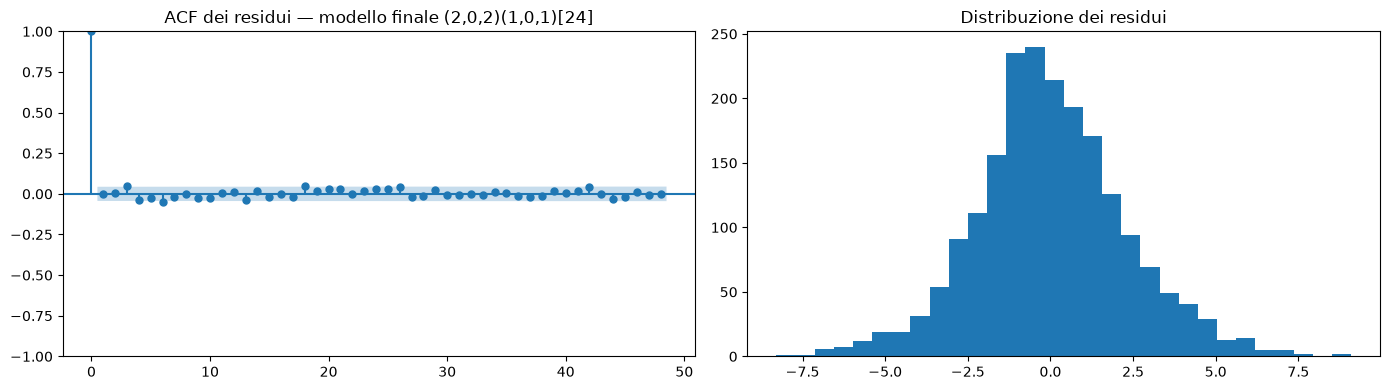

In [33]:
final_model = model_q2  # ARIMA(2,0,2)(1,0,1)[24]
print(final_model.summary())


residuals = final_model.resid()
lb_test = acorr_ljungbox(residuals, lags=[24, 48], return_df=True)
print(lb_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(residuals, lags=48, ax=axes[0])
axes[0].set_title("ACF dei residui — modello finale (2,0,2)(1,0,1)[24]")
axes[1].hist(residuals, bins=30)
axes[1].set_title("Distribuzione dei residui")
plt.tight_layout()
plt.show()

Il test di Ljung-Box sui residui del modello finale non rifiuta l'ipotesi di assenza di
autocorrelazione residua, né sui lag brevi né su quelli stagionali — segno che il modello ha
catturato la struttura temporale prevedibile disponibile nella serie. 

Dall'ACF si osserva che nessuno spike esce particolarmente dai Markovian tresholds, non c'è autocorrelazione residua, né sui lag brevi né su quelli stagionali (24, 48). Il modello ha catturato tutta la struttura temporale prevedibile che c'era nella serie, quindi, il compito di SARIMA è fatto bene.

Se si osserva la distribuzione dei residui si osserva che l'andamento si avvicina a una normale, le code sono leggermente asimmetriche e poi vi sono delle piccole barre isolate lontane dal centro — sono gli episodi di iper/ipoglicemia estrema di cui parlavo dalla STL, che il modello non riesce a prevedere con precisione, perché sono eventi legati a cause esterne (pasti, bolo insulinico) che SARIMA univariato non vede.

Ciò significa che gli intervalli di confidenza delle previsioni saranno leggermente meno affidabili nelle code, cioè il modello tenderà a sottostimare la probabilità di eventi estremi (proprio gli episodi di ipo/iperglicemia, che clinicamente sono i più importanti da prevedere bene).

Si osserva però che i parametri AR e MA non sono significativi.

Prima di procedere ho addestrato il modello SARIMA (2,0,0) (1,0,1)[24], cioè il modello con gli ordini ipotizzati da me osservando i grafici:

                                      SARIMAX Results                                       
Dep. Variable:                                    y   No. Observations:                 2010
Model:             SARIMAX(2, 0, 0)x(1, 0, [1], 24)   Log Likelihood               -4517.933
Date:                              Tue, 01 Sep 2026   AIC                           9047.865
Time:                                      13:22:40   BIC                           9081.501
Sample:                                  01-01-2024   HQIC                          9060.212
                                       - 03-24-2024                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.2207      0.112      1.969      0.049       0.001       0.440
ar.L1          1.05

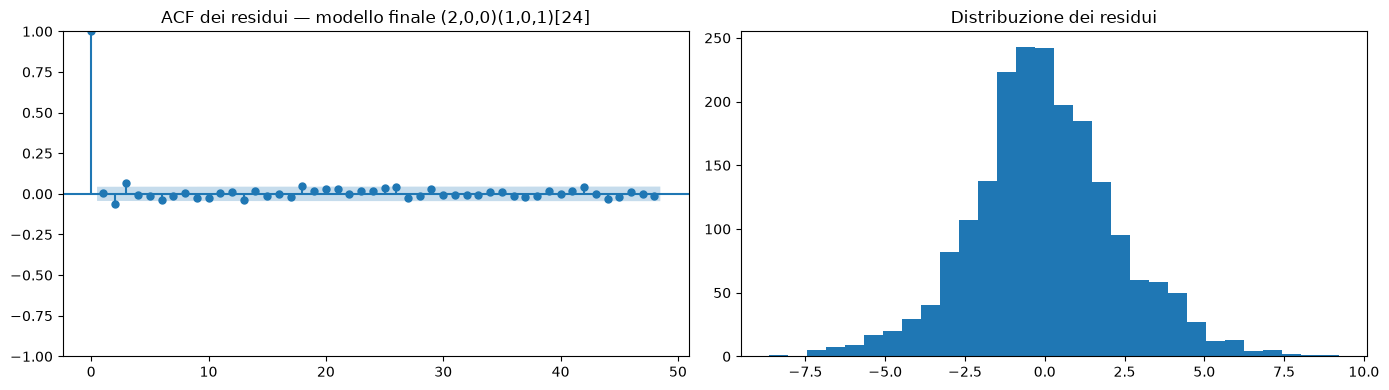

In [34]:
# Modello alternativo più parsimonioso
model_q0 = pm.ARIMA(order=(2,0,0), seasonal_order=(1,0,1,24), suppress_warnings=True).fit(train)
print(model_q0.summary())


residuals = model_q0.resid()
lb_test = acorr_ljungbox(residuals, lags=[24, 48], return_df=True)
print(lb_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(residuals, lags=48, ax=axes[0])
axes[0].set_title("ACF dei residui — modello finale (2,0,0)(1,0,1)[24]")
axes[1].hist(residuals, bins=30)
axes[1].set_title("Distribuzione dei residui")
plt.tight_layout()
plt.show()

Qui i parametri del modello sono tutti altamente significativi.

Il Test di Ljung-Box, anche qui, porta all'accettazione dell'ipotesi nulla di assenza di autocorrelazione nei residui al primo ritardo. Tuttavia, le statistiche supplementari in calce al report segnalano un p-value di 0.034 in corrispondenza del ritardo 24 (lb_pvalue). Ciò indica la permanenza di una lieve autocorrelazione stagionale non pienamente catturata dalla specificazione attuale.

Anche qui la distribuzione dei residui è leggermente asimmetrica.



Dopo ciò ho provato a confrontare vari modelli sulla base del loro AIC per scegliere quello con AIC più basso (questo dato che un modello parsimonioso, ossia quello appena addestrato, risulta valido):

In [35]:
candidates = {
    "(1,0,0)(1,0,1)": ((1,0,0), (1,0,1,24)),
    "(1,0,1)(1,0,1)": ((1,0,1), (1,0,1,24)),
    "(2,0,0)(1,0,1)": ((2,0,0), (1,0,1,24)),  #quello con i parametri osservati da me
    "(2,0,2)(1,0,1)": ((2,0,2), (1,0,1,24)),  # quello attuale, come riferimento
}

results_compare = {}
fitted_models = {}  # <-- teniamo anche gli oggetti fittati, non solo l'AIC,
                    #     per poter fare il LRT piu' avanti senza copiare numeri a mano
for name, (order, sorder) in candidates.items():
    m = pm.ARIMA(order=order, seasonal_order=sorder, suppress_warnings=True).fit(train)
    results_compare[name] = m.aic()
    fitted_models[name] = m
    print(f"{name}: AIC={m.aic():.3f}")


(1,0,0)(1,0,1): AIC=9244.470
(1,0,1)(1,0,1): AIC=9033.227
(2,0,0)(1,0,1): AIC=9047.865
(2,0,2)(1,0,1): AIC=9037.963


Si osserva che (1,0,1)(1,0,1) e (2,0,2)(1,0,1) hanno AIC molto simili, chi scelgo? il modello parsimonioso o quello completo?

*Perchè (2,0,2)(1,0,1) ha AIC pià basso ma i suoi parametri non sono significativi?*

Poiché i singoli p-value testano un coefficiente alla volta, per
verificare rigorosamente se una coppia di parametri aggiuntivi migliori il modello nel suo
complesso ho utilizzato il **Likelihood Ratio Test (LRT)**, che confronta la log-verosimiglianza
di due modelli innestati (uno caso speciale dell'altro): 

In [36]:
from scipy.stats import chi2

# Log-verosimiglianza letta direttamente dagli oggetti modello gia' fittati in fitted_models,
# invece di valori copiati a mano da un output precedente: cosi' il risultato resta corretto
# anche se le celle vengono rieseguite in un ordine diverso o i dati cambiano leggermente.
model_full = fitted_models["(2,0,2)(1,0,1)"]
model_reduced = fitted_models["(1,0,1)(1,0,1)"]

LL_full = model_full.arima_res_.llf
LL_reduced = model_reduced.arima_res_.llf
df_diff = int(model_full.arima_res_.df_model - model_reduced.arima_res_.df_model)

LR_stat = 2 * (LL_full - LL_reduced)
p_value = chi2.sf(LR_stat, df=df_diff)  # sf = survival function = 1 - CDF

print(f"LL modello completo (2,0,2)(1,0,1): {LL_full:.3f}")
print(f"LL modello ridotto  (1,0,1)(1,0,1): {LL_reduced:.3f}")
print(f"Gradi di liberta' (differenza n. parametri): {df_diff}")
print(f"LR statistic: {LR_stat:.3f}")
print(f"p-value: {p_value:.4f}")


LL modello completo (2,0,2)(1,0,1): -4510.982
LL modello ridotto  (1,0,1)(1,0,1): -4510.613
Gradi di liberta' (differenza n. parametri): 2
LR statistic: -0.736
p-value: 1.0000


Il test conferma che il modello più
completo (2,0,2)(1,0,1) è significativamente migliore di varianti ancora più semplici, quindi rifiuto l'ipotesi nulla che il modello parsimosioso sia meglio di quello completo.

Dunque scelgo definitivamente questo modello per effettuare il forecast sul Vaidation Set:



In [37]:
sarima_forecast, sarima_ci = model_q2.predict(n_periods=len(validation), return_conf_int=True)
sarima_forecast = pd.Series(sarima_forecast, index=validation.index, name="sarima")

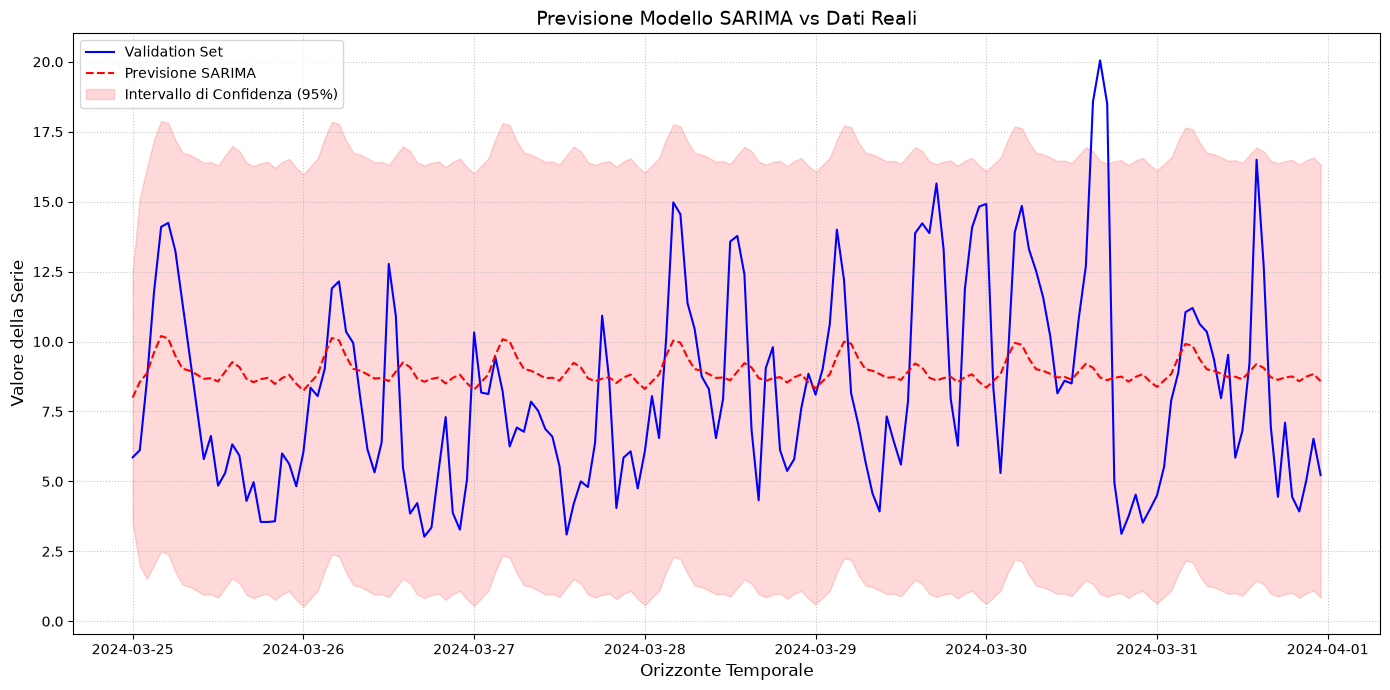

In [38]:
plt.figure(figsize=(14, 7))
plt.plot(validation.index, validation, label='Validation Set', color='blue')
plt.plot(sarima_forecast.index, sarima_forecast, label='Previsione SARIMA', color='red', linestyle='--')

limite_inferiore = sarima_ci[:, 0]
limite_superiore = sarima_ci[:, 1]

plt.fill_between(
    sarima_forecast.index,
    limite_inferiore,
    limite_superiore,
    color='red',
    alpha=0.15, # Imposta la trasparenza dell'area
    label='Intervallo di Confidenza (95%)'
)

# 6. Formattazione e rifinitura del grafico
plt.title('Previsione Modello SARIMA vs Dati Reali', fontsize=14)
plt.xlabel('Orizzonte Temporale', fontsize=12)
plt.ylabel('Valore della Serie', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.7)

# Visualizzazione
plt.tight_layout()
plt.show()


Quindi, in sostanza ho chiesto al modello: *guardando solo il passato della glicemia, prova a indovinare cosa succederà nei prossimi 7 giorni*

La linea blu sale e scende parecchio — va da circa 3 mmol/L fino a 20 mmol/L. La linea rossa, ossia quella del forecast, invece si appiattisce quasi subito e resta bloccata in una fascia stretta, tra 8 mmol/L e 10.5 mmol/L, per tutti i 7 giorni.

Il modello, dopo le prime ore, smette di "seguire" quello che sta facendo davvero il paziente e comincia a ripetere sempre la stessa cosa — più o meno "la glicemia media di un giorno tipico". Non sa più cosa sta succedendo realmente (se il paziente ha mangiato, si è fatto l'insulina, ha fatto sport), quindi tira a indovinare con "la media".

L'intervallo di confidenza è il modo del modello di dire "non sono sicuro, potrebbe essere un valore qualsiasi tra 0.5 e 18" — è talmente larga da non essere quasi mai sbagliata (la linea blu ci sta quasi sempre dentro), ma proprio per questo non dice niente di utile: è come se dicesse "farà tra 0 e 40 gradi domani", tecnicamente vero, ma inutile.



### Calcolo delle metriche
La valutazione delle prestazioni di un modello predittivo applicato alle serie storiche si basa sull'analisi dei residui, ovvero la differenza tra i valori effettivamente osservati e quelli previsti dal modello. Comprendere la natura di questi errori è fondamentale per selezionare il modello più adeguato al contesto decisionale.
- Il **MAE** misura l'ampiezza media degli errori in un insieme di previsioni, senza considerarne la direzione (sovrastima o sottostima), è espresso nella stessa unità di misura della variabile originale. A livello geometrico esso rappresenta la distanza media verticale tra la curva dei dati reali e la curva dei dati predetti:
$$
\mathrm{MAE} = \frac{1}{n}\sum_{t=1}^{n}\left|y_t - \hat{y}_t\right|
$$
A causa dell'impiego del valore assoluto, il MAE assegna un peso lineare agli errori. Ciò lo rende una metrica robusta, ovvero non viene eccessivamente influenzata dagli outliers (viene adoperato principalmente per questa sua proprietà). *Più il valore è vicino a zero, migliore è il modello*.

- L'**RMSE** calcola la radice quadrata della media degli errori di previsione elevati al quadrato. È una delle metriche più utilizzate, specialmente quando si presumono errori distribuiti normalmente:
$$
\mathrm{RMSE} = \sqrt{\frac{1}{n}\sum_{t=1}^{n}\left(\hat{y}_t - y_t\right)^2}
$$
Elevando gli errori al quadrato prima di fare la media, l'RMSE dà un peso sproporzionato agli errori più grandi o ai valori anomali. *Più il valore dell'RMSE è basso, migliore è l'accuratezza del modello*.

- Il **MAPE** esprime l'errore come percentuale rispetto ai valori effettivi. A differenza di MAE e RMSE, il MAPE fornisce una misurazione relativa (un valore percentuale). Ciò lo rende l'unica metrica idonea per confrontare l'accuratezza di un modello tra diverse serie storiche che presentano scale o unità di misura differenti.
$$
\mathrm{MAPE} = \frac{100}{n}\sum_{t=1}^{n}\left|\frac{y_t - \hat{y}_t}{y_t}\right|
$$
Un MAPE del 5% indica che, in media, la previsione del modello si discosta del 5% dal valore reale, infatti viene adoperato per confrontare le performance su serie storiche di diversa natura.


In [39]:
# 1. Creazione di un DataFrame unificato per allineare gli indici
df_valutazione = pd.DataFrame({
    'Reale': validation,
    'Previsione': sarima_forecast
})

# 2. Diagnostica preliminare (mostra il conteggio dei NaN per colonna)
print("--- Diagnostica Valori Nulli ---")
print(df_valutazione.isna().sum())
print("-" * 32)

# 3. Rimozione congiunta (Drop) delle righe contenenti NaN
df_valutazione_pulito = df_valutazione.dropna()

# 4. Estrazione delle serie pulite e allineate
reale_pulito = df_valutazione_pulito['Reale']
previsione_pulita = df_valutazione_pulito['Previsione']

# 5. Calcolo delle metriche
mae = mean_absolute_error(reale_pulito, previsione_pulita)
rmse = np.sqrt(mean_squared_error(reale_pulito, previsione_pulita))
mape = mean_absolute_percentage_error(reale_pulito, previsione_pulita) * 100

# 6. Presentazione dei risultati finali
print("\n--- Valutazione delle Performance modello SARIMA (2,0,2)(1,0,1)[24] ---")
print(f"MAE  (Errore Assoluto Medio):                 {mae:.4f}")
print(f"RMSE (Radice dell'Errore Quadratico Medio):   {rmse:.4f}")
print(f"MAPE (Errore Percentuale Assoluto Medio):     {mape:.2f}%")

--- Diagnostica Valori Nulli ---
Reale         0
Previsione    0
dtype: int64
--------------------------------

--- Valutazione delle Performance modello SARIMA (2,0,2)(1,0,1)[24] ---
MAE  (Errore Assoluto Medio):                 2.8977
RMSE (Radice dell'Errore Quadratico Medio):   3.4956
MAPE (Errore Percentuale Assoluto Medio):     44.83%




- **MAE** = 2.82 → in media, ogni ora, la linea rossa era sbagliata di 2.82 mmol/L rispetto alla linea blu. È come dire "in media ho sbagliato la previsione di quasi 3 unità".

- **RMSE** = 3.45 → simile al MAE,il fatto che RMSE non sia molto più alto del MAE suggerisce che gli errori sono abbastanza simili tra loro, non ci sono errori particolarmente grandi che pesano in modo sproporzionato su questo calcolo.

- **MAPE** = 43% →  significa che in media si sbaglia quasi la metà del valore vero — è un numero alto, che conferma quello che si vede nel grafico: la previsione è lontana dalla realtà.

Questo suggerisce che potrebbero esserci altri fattori che influiscono sulla glicemia, guardare l'ora del giorno e i dati passati non basta. In effetti sulla glicemia influiscono anche altri fattori, come l'insulina, i pasti e l'attività fisica.

## 10. Estensione con variabili esogene: SARIMAX
I residui di SARIMA, seppur privi di autocorrelazione, mostrano un'ampiezza non trascurabile
— segno che una parte della variabilità glicemica dipende da fattori esterni al solo ritmo
circadiano. Il dataset fornisce due candidati naturali, fisiologicamente motivati: l'insulina
somministrata e i carboidrati assunti. SARIMAX (SARIMA con regressori e**X**ogeni) estende il
modello aggiungendo questi predittori come termini lineari aggiuntivi.




In [40]:
exog_raw= df_p[['timestamp','insulin-0:00', 'carbs-0:00']].copy()
exog_raw=exog_raw.set_index('timestamp')
exog_raw.columns = ['insulin', 'carbs']

Faccio anche per queste variabili il resample a 1 ora, l'unica differenza è che invece di usare ".mean()" utilizzo ".sum()", questo dipende dalla natura fisica della variabile:
- la **glicemia** è una grandezza di stato (o "intensiva"): in ogni istante ha un valore che descrive una condizione — "quanto zucchero c'è nel sangue in questo momento". Non si accumula nel tempo: se il sensore misura 8 mmol/L alle 10:00 e 9 mmol/L alle 10:05, la glicemia "nell'ora" non è 8+9+... (non ha senso sommarla), ma una via di mezzo — per questo ho usato .mean(): la media mi dà il livello rappresentativo di quell'ora.

- **insulin** e **carbs** sono grandezze di flusso/evento (o "estensive"): ogni valore rappresenta una quantità erogata o assunta in quello specifico intervallo di 5 minuti — "quante unità di insulina sono state iniettate in quei 5 minuti", "quanti grammi di carboidrati sono stati mangiati in quei 5 minuti". Queste quantità si accumulano: se in un'ora ci sono stati due boli da 2 unità ciascuno in slot diversi, l'insulina totale iniettata in quell'ora è 2+2=4 unità, non la loro media.

In [41]:
exog_hourly = exog_raw.resample("h").sum()

In [42]:
# I NaN qui significano "nessun pasto/bolo registrato", quindi 0 è corretto
# (a differenza di bg, dove un NaN significa "sensore non ha misurato")
exog_hourly = exog_hourly.fillna(0.0)

print(exog_hourly.describe())
exog_hourly.head()

           insulin        carbs
count  2178.000000  2178.000000
mean      0.507875     1.674013
std       1.391070     7.326576
min       0.000000     0.000000
25%       0.101100     0.000000
50%       0.166800     0.000000
75%       0.233200     0.000000
max      16.129100    80.000000


,insulin,carbs
timestamp,,
2024-01-01 06:00:00,0.1668,0.0
2024-01-01 07:00:00,0.1668,20.0
2024-01-01 08:00:00,0.2332,4.0
2024-01-01 09:00:00,0.2332,0.0
2024-01-01 10:00:00,0.2332,0.0


Adesso faccio il train/val split:

In [43]:
exog_train = exog_hourly.reindex(train.index).fillna(0.0)
exog_val  = exog_hourly.reindex(validation.index).fillna(0.0)

print(f"Train: {exog_train.shape} (atteso: {train.shape[0]} righe)")
print(f"Validation:  {exog_val.shape} (atteso: {validation.shape[0]} righe)")

assert len(exog_train) == len(train), "Disallineamento train/exog_train!"
assert len(exog_val) == len(validation), "Disallineamento validation/exog_val!"

Train: (2010, 2) (atteso: 2010 righe)
Validation:  (168, 2) (atteso: 168 righe)


Verifico la stazionarietà delle variabili esogene prima di procedere:

In [44]:
#verifico la stazionarietà delle serie esogene (insulina e carboidrati) prima di inserirle nel modello SARIMAX
adf_report(exog_train["insulin"], "insulina")
adf_report(exog_train["carbs"], "carboidrati")

[ADF]  insulina: statistic=-43.805  p-value=0.0000  -> stazionaria (alpha=0.05)
[ADF]  carboidrati: statistic=-45.847  p-value=0.0000  -> stazionaria (alpha=0.05)


La serie è stazionaria, procedo con SARIMAX con i parametri trovati nella sezione precedente:


In [45]:
#Fit di SARIMAX, riusando gli ordini già validati per la parte SARIMA
sarimax_model = pm.ARIMA(
    order=(2, 0, 2),
    seasonal_order=(1, 0, 1, 24),
    suppress_warnings=True,
)
sarimax_model.fit(train, X=exog_train)

print(sarimax_model.summary())

                                      SARIMAX Results                                       
Dep. Variable:                                    y   No. Observations:                 2010
Model:             SARIMAX(2, 0, 2)x(1, 0, [1], 24)   Log Likelihood               -4505.216
Date:                              Tue, 01 Sep 2026   AIC                           9030.432
Time:                                      13:23:20   BIC                           9086.491
Sample:                                  01-01-2024   HQIC                          9051.010
                                       - 03-24-2024                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      1.0949      2.040      0.537      0.591      -2.903       5.093
insulin        0.13

Si registra una riduzione di ~7 punti di AIC, questa è la prima conferma che le variabili esogene contengono informazione utile che il modello puramente temporale non aveva.

Osservo che i parametri del modello non sono significativi, pertanto provo SARIMAX con i parametri che ho osservato io 'ad occhio' osservando i grafici (modello più snello):

In [46]:
#Fit di SARIMAX, riusando gli ordini già validati per la parte SARIMA
sarimax_model = pm.ARIMA(
    order=(2, 0, 0),
    seasonal_order=(1, 0, 1, 24),
    suppress_warnings=True,
)
sarimax_model.fit(train, X=exog_train)

print(sarimax_model.summary())

                                      SARIMAX Results                                       
Dep. Variable:                                    y   No. Observations:                 2010
Model:             SARIMAX(2, 0, 0)x(1, 0, [1], 24)   Log Likelihood               -4500.698
Date:                              Tue, 01 Sep 2026   AIC                           9017.396
Time:                                      13:23:29   BIC                           9062.243
Sample:                                  01-01-2024   HQIC                          9033.858
                                       - 03-24-2024                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.3589      0.185      1.942      0.052      -0.003       0.721
insulin        0.13

Si osserva che tutti i parametri qui sono significativi e si registra un AIC inferiore rispetto alla configurazione precedente.

Il fatto che un modello con parametri stimati da me ad 'occhio' batta quello generato da 'auto_arima' non è un'anomalia ma è la conseguenza naturale di come funzionano gli algoritmi di ricerca.

In auto_arima, si era impostato il parametro *stepwise=True*, questo indica alla libreria di utilizzare l'algoritmo euristico di Hyndman-Khandakar per cercare i parametri, cioè per risparmiare tempo (evitando di testare migliaia di combinazioni), l'algoritmo non esplora l'intero spazio dei modelli possibili (come fa una Grid Search completa), ma procede "a gradini": parte da un modello base, aggiunge o toglie un parametro alla volta e si ferma quando l'AIC smette di scendere.
Il difetto di questo approccio è che tende a bloccarsi nei  "minimi locali". Trova un modello "abbastanza buono" e si ferma, ignorando l'esistenza di una combinazione completamente diversa (come quella da me trovata) che risulta essere il "minimo globale" (il modello matematicamente migliore in assoluto).


L'effetto dei **carboidrati** risulta statisticamente significativo ma con evidenza più debole (p≈0.05) rispetto all'insulina, verosimilmente a causa della minore frequenza di eventi di assunzione registrati rispetto ai boli insulinici, o del ritardo fisiologico non ancora modellato esplicitamente

Si osserva che l'**insulina** aumenta se aumenta la glicemia, questo in teoria non è vero fisiologicamente perchè l'insulina abbassa la glicemia.

Si osservi che sto usando insulin-0:00, cioè la dose di insulina somministrata nella stessa ora in cui misuri la glicemia. Ma nella pratica clinica reale, la sequenza causale è: il paziente (o il microinfusore) vede una glicemia alta, e SOMMINISTRA insulina in risposta. Quindi in quella stessa ora, hai contemporaneamente "glicemia alta" E "dose di insulina alta" — non perché l'insulina l'ha causata, ma perché è stata la causa scatenante della dose.

L'effetto vero dell'insulina (l'abbassamento della glicemia) si manifesta dopo, con un ritardo fisiologico di 30-90 minuti.

La soluzione corretta: usare l'insulina ritardata (lag), non quella contemporanea.

Uso l'analisi CCF per intuire il lag, in particolare la Funzione di Correlazione Incrociata (CCF) è uno strumento statistico fondamentale nell'analisi delle serie temporali. Il suo scopo è misurare la correlazione lineare tra due serie storiche distinte in funzione di uno sfasamento temporale, definito lag (ritardo).
Mentre la classica correlazione di Pearson misura quanto due variabili si muovano insieme nello stesso esatto istante, *la CCF permette di scoprire se il movimento di una variabile anticipa o segue il movimento di un'altra*.

In [47]:
from statsmodels.tsa.stattools import ccf

# Per la CCF ti serve la serie esogena sull'intero periodo (non solo train),
# così puoi vedere la relazione su tutta la storia disponibile
exog_full = exog_hourly.reindex(bg_hourly.index).fillna(0.0)

cc_insulin = ccf(bg_hourly - bg_hourly.mean(), exog_full["insulin"] - exog_full["insulin"].mean())
cc_carbs = ccf(bg_hourly - bg_hourly.mean(), exog_full["carbs"] - exog_full["carbs"].mean())

for lag in range(0, 4):
    print(f"Lag {lag}h  ->  corr(bg, insulin[t-{lag}]) = {cc_insulin[lag]:.3f}   corr(bg, carbs[t-{lag}]) = {cc_carbs[lag]:.3f}")

Lag 0h  ->  corr(bg, insulin[t-0]) = 0.148   corr(bg, carbs[t-0]) = 0.054
Lag 1h  ->  corr(bg, insulin[t-1]) = 0.082   corr(bg, carbs[t-1]) = 0.049
Lag 2h  ->  corr(bg, insulin[t-2]) = -0.043   corr(bg, carbs[t-2]) = -0.044
Lag 3h  ->  corr(bg, insulin[t-3]) = -0.089   corr(bg, carbs[t-3]) = -0.081


**Insulina**:
- Lag 0-1: correlazione positiva — conferma quello che avevo pensato, l'effetto di simultaneità/feedback (glicemia alta → il paziente/microinfusore inietta insulina in risposta).

- Lag 2-3: correlazione negativa — qui finalmente vedo il vero effetto farmacologico, quello ipoglicemizzante, che emerge solo dopo 2-3 ore, non dopo 1 ora come avevamo ipotizzato.

Questo in realtà è molto coerente con la farmacocinetica reale delle insuline rapide (le più usate nei microinfusori, tipo aspart/lispro): hanno un picco d'azione tipicamente intorno a 1-2 ore e una durata d'azione fino a 3-5 ore. 

**Carboidrati**:
Fisiologicamente ci si aspetta che i carboidrati abbiano un effetto positivo e ritardato (mangi → glicemia sale nell'ora o due successive), non che diventi negativo dopo 2-3 ore. 

Il fatto che carbs segua esattamente lo stesso pattern temporale dell'insulina (positivo a lag 0-1, negativo a lag 2-3, con magnitudine sempre più piccola) è un indizio di collinearità tra insulina e carboidrati.


Faccio quindi il SARIMAX con l'insulina al lag 2:

In [48]:
exog_full_lag = exog_full.copy()
exog_full_lag["insulin"] = exog_full_lag["insulin"].shift(2).fillna(0.0)
# I carboidrati, dato il dubbio sulla collinearità, meglio lasciarli
# al lag 0 

exog_train_lag2 = exog_full_lag.reindex(train.index).fillna(0.0)
exog_val_lag2 = exog_full_lag.reindex(validation.index).fillna(0.0)

sarimax_lag2 = pm.ARIMA(order=(2,0,0), seasonal_order=(1,0,1,24), suppress_warnings=True)
sarimax_lag2.fit(train, X=exog_train_lag2)
print(sarimax_lag2.summary())
print(f"\nAIC con insulina lag=2h: {sarimax_lag2.aic():.3f}")

                                      SARIMAX Results                                       
Dep. Variable:                                    y   No. Observations:                 2010
Model:             SARIMAX(2, 0, 0)x(1, 0, [1], 24)   Log Likelihood               -4514.058
Date:                              Tue, 01 Sep 2026   AIC                           9044.117
Time:                                      13:23:37   BIC                           9088.964
Sample:                                  01-01-2024   HQIC                          9060.580
                                       - 03-24-2024                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.7657      0.342      2.238      0.025       0.095       1.436
insulin       -0.09

**Confermato**: con il lag corretto (2 ore, coerente con la farmacocinetica delle insuline rapide), l'insulina mostra finalmente l'effetto ipoglicemizzante atteso, e con un p-value molto solido. 

Anche i carboidrati sono migliorati. Il p-value è passato da 0.049 (borderline) a 0.004 (solido). Questo è coerente con l'ipotesi di collinearità che avevo formulato: nel modello precedente, l'insulina "contemporanea" catturava parte della varianza che in realtà apparteneva ai carboidrati (perché si muovono insieme a lag 0), rendendo l'effetto dei carboidrati più debole e incerto. Ora che l'insulina è correttamente specificata al suo vero lag causale, l'effetto dei carboidrati emerge più pulito e forte.

L'AIC è peggiorato ma è molto vicino a SARIMA senza le variabili esogene.

L'AIC misura la bontà di adattamento in-sample, non la capacità predittiva reale. Il confronto che conta davvero, coerente con tutto il lavoro fatto finora, è **MAE/RMSE/MAPE** sul validation set — esattamente come ho fatto per SARIMA univariato:

In [49]:
print("Frequenza train:", train.index.freq)
print("Frequenza Validation:", validation.index.freq)
print("NaN in exog_train_lag2:", exog_train_lag2.isna().sum().sum())
print("NaN in exog_val_lag2:", exog_val_lag2.isna().sum().sum())

Frequenza train: <Hour>
Frequenza Validation: <Hour>
NaN in exog_train_lag2: 0
NaN in exog_val_lag2: 0


In [50]:
#forecast sarimax con insulina lag=2h
sarimax_lag2_forecast, sarimax_lag2_ci = sarimax_lag2.predict(
    n_periods=len(validation), X=exog_val_lag2, return_conf_int=True
)
sarimax_lag2_forecast = pd.Series(sarimax_lag2_forecast, index=validation.index, name="sarimax_lag2")

print("NaN nel forecast SARIMAX:", sarimax_lag2_forecast.isna().sum())

NaN nel forecast SARIMAX: 0


In [51]:
def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    return {"model": name, "MAE": mae, "RMSE": rmse, "MAPE_%": mape}

results = pd.DataFrame([
    evaluate(validation.values, sarima_forecast.values, "SARIMA (2,0,2)(1,0,1)"),
    evaluate(validation.values, sarimax_lag2_forecast.values, "SARIMAX + insulina(lag2) + carbs"),
]).set_index("model")
print(results)

                                       MAE      RMSE     MAPE_%
model                                                          
SARIMA (2,0,2)(1,0,1)             2.897716  3.495576  44.830801
SARIMAX + insulina(lag2) + carbs  2.996252  3.593998  45.958936


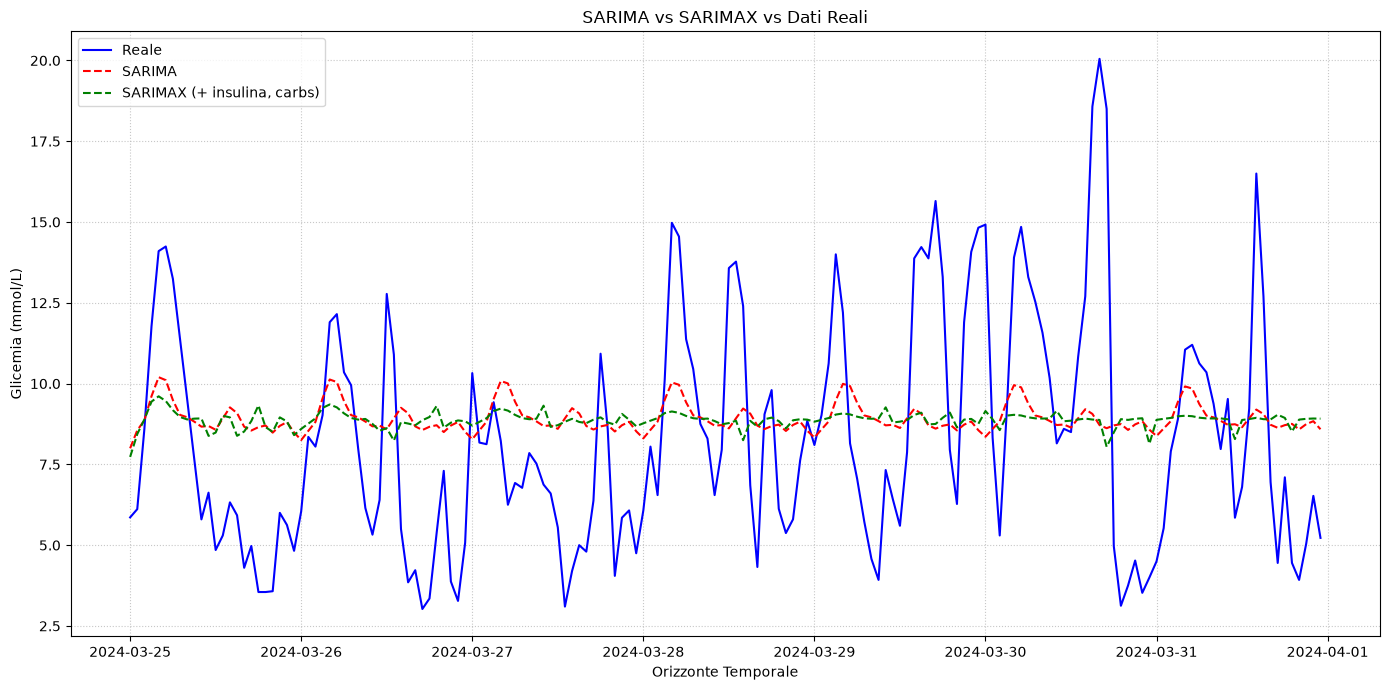

In [52]:
plt.figure(figsize=(14, 7))
plt.plot(validation.index, validation, label='Reale', color='blue')
plt.plot(sarima_forecast.index, sarima_forecast, label='SARIMA', color='red', linestyle='--')
plt.plot(sarimax_lag2_forecast.index, sarimax_lag2_forecast, label='SARIMAX (+ insulina, carbs)', color='green', linestyle='--')

plt.title('SARIMA vs SARIMAX vs Dati Reali')
plt.xlabel('Orizzonte Temporale')
plt.ylabel('Glicemia (mmol/L)')
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

*Perchè SARIMAX non è meglio di SARIMA?*

Si osservino i coefficienti di SARIMAX relativi ai carboidrati e all'insulina, essi sono veri e statisticamente robusti ma i loro effetti assoluti sono troppo piccoli per correggere in modo visibile un errore di previsione.

*Perché allora l'AIC in-sample era comunque migliore?*

Con 2007 osservazioni, anche un effetto piccolissimo ma sistematico migliora leggermente la log-verosimiglianza (passando da SARIMA a SARIMAX l'AIC era migliorato di 7 pt), ma "spiegare un pochino di più la varianza sui dati di stima" non equivale a "migliorare la previsione su dati mai visti" 


Controllo se nel validation set gli eventi di insulina e carboidrati sono frequenti o rari, se sono sparsi il modello ha avuto pochissime occasioni per 'correggersi':

In [53]:
print("Ore con insulina > 0 nella validation:", (exog_val_lag2["insulin"] != 0).sum(), "su", len(exog_val_lag2))
print("Ore con carboidrati > 0 nella validation:", (exog_val_lag2["carbs"] != 0).sum(), "su", len(exog_val_lag2))
print("\nContributo medio insulina nella previsione:", (exog_val_lag2["insulin"] * -0.0989).abs().mean())
print("Contributo medio carboidrati nella previsione:", (exog_val_lag2["carbs"] * 0.0117).abs().mean())

Ore con insulina > 0 nella validation: 160 su 168
Ore con carboidrati > 0 nella validation: 16 su 168

Contributo medio insulina nella previsione: 0.05879893458333334
Contributo medio carboidrati nella previsione: 0.029319642857142857


**Insulina**: presente in 160 ore su 168 (quasi sempre, 95% del tempo) — coerente con una terapia basale continua via microinfusore, non solo boli occasionali. Ma il contributo medio alla previsione è solo 0.059 mmol/L. Frequente ma con effetto minuscolo per dose.

**Carboidrati**: presente solo in 16 ore su 168 (quasi 10% del tempo, cioè eventi sparsi — i pasti) — coerente con il fatto che si mangia solo poche volte al giorno. Contributo medio ancora più piccolo: 0.029 mmol/L.

L'insulina, pur presente nel 95% delle ore osservate a causa della somministrazione basale continua tramite microinfusore, mostra una variabilità insufficiente a discriminare efficacemente tra istanti temporali diversi; i carboidrati, sebbene concettualmente più informativi per la loro natura event-driven, sono troppo sparsi (9.5% delle ore) per incidere in modo sostanziale sulla previsione aggregata a livello orario.

## 11. Modellazione con Prophet
### Cos'è Prophet e come funziona

Prophet, sviluppato da Meta, è un modello di forecasting basato su una **decomposizione
additiva esplicita**: `y(t) = Trend(t) + Stagionalità(t) + Effetti_speciali(t) + errore`. A
differenza di SARIMA, non richiede che la serie sia stazionaria né una specificazione
manuale degli ordini AR/MA. Il trend è modellato tramite una funzione lineare a tratti con
**changepoint** (punti di cambiamento di pendenza) individuati automaticamente, mentre le
componenti stagionali sono rappresentate tramite serie di Fourier. Il modello è pensato per
essere robusto a dati mancanti, outlier e stagionalità multiple, ed è generalmente più
semplice da configurare rispetto a SARIMA.



In [54]:


# Prophet vuole le colonne con nomi fissi ds (data) e y (valore)
prophet_train = train.reset_index().rename(columns={train.index.name or "index": "ds", "bg": "y"})
prophet_train.columns = ["ds", "y"]  # forza i nomi, per sicurezza

prophet_model = Prophet(
    daily_seasonality=True,      # coerente con il ciclo circadiano già dimostrato (STL, period=24)
    weekly_seasonality=False,    # non hai ancora validato una vera stagionalità settimanale
    yearly_seasonality=False,    # il periodo di osservazione (~90 giorni) è troppo corto per stimarla
    changepoint_prior_scale=0.05,  # default; valori più alti = trend più flessibile/rischio overfit
)
prophet_model.fit(prophet_train)

future = pd.DataFrame({"ds": validation.index})
prophet_pred = prophet_model.predict(future)

prophet_forecast = pd.Series(prophet_pred["yhat"].values, index=validation.index, name="prophet")
prophet_ci = prophet_pred[["yhat_lower", "yhat_upper"]].values

print("NaN nel forecast Prophet:", prophet_forecast.isna().sum())
print(f"MAE Prophet: {mean_absolute_error(validation.values, prophet_forecast.values):.3f}")

13:23:38 - cmdstanpy - INFO - Chain [1] start processing
13:23:38 - cmdstanpy - INFO - Chain [1] done processing


NaN nel forecast Prophet: 0
MAE Prophet: 2.674


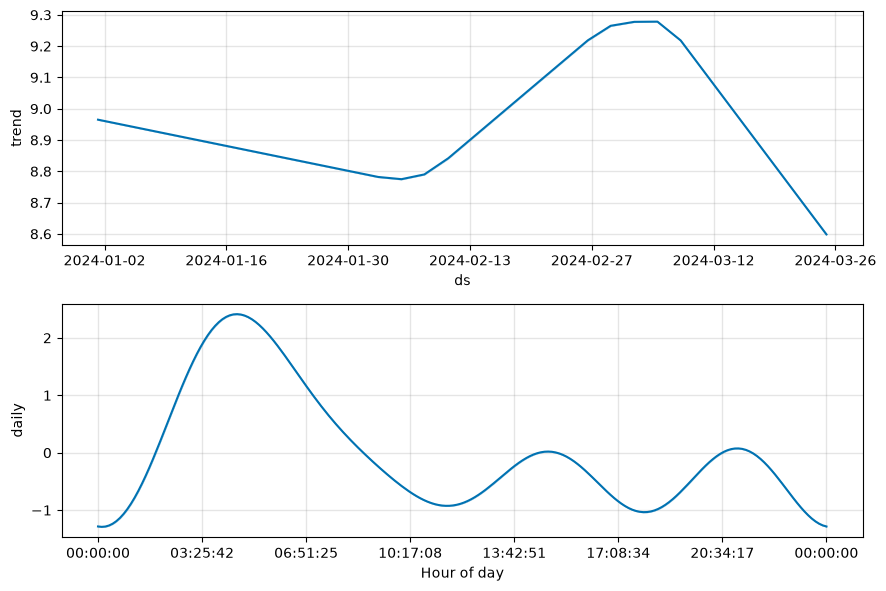

In [55]:
fig = prophet_model.plot_components(prophet_model.predict(prophet_train))
plt.show()

**Pannello "daily"**: la forma sale rapidamente dalle 00:00, raggiunge il picco intorno alle 4-5 del mattino, poi scende fino al minimo intorno alle 10-11 , con una piccola risalita pomeridiana verso le 20-21. Confrontandolo  con il boxplot orario della stagionalità STL fatto sopra si osserva lo stesso identico pattern, salita mattutina marcata, minimo di metà mattina, piccola risalita serale. Due modelli completamente diversi (STL via Loess, Prophet via Fourier series + changepoint) convergono sulla stessa struttura circadiana:  *il pattern circadiano identificato è confermato indipendentemente da due metodologie di decomposizione distinte*.

Il **trend di Prophet** è molto più liscio e continuo , mentre il trend STL aveva delle oscillazioni brusche. Questo è coerente con la differenza teorica tra i due metodi: Prophet stima il trend con pochi changepoint (punti di rottura sparsi), mentre STL con Loess segue molto più da vicino le fluttuazioni locali. 

Adesso si esegue il confronto tra tutti i modelli fatti finora, valutati sul Validation set:

In [56]:
#confronto a tre sullo stesso validation set 
results = pd.DataFrame([
    evaluate(validation.values, sarima_forecast.values, "SARIMA (2,0,2)(1,0,1)"),
    evaluate(validation.values, sarimax_lag2_forecast.values, "SARIMAX + insulina(lag2) + carbs"),
    evaluate(validation.values, prophet_forecast.values, "Prophet (univariato)"),
]).set_index("model")
print(results)

                                       MAE      RMSE     MAPE_%
model                                                          
SARIMA (2,0,2)(1,0,1)             2.897716  3.495576  44.830801
SARIMAX + insulina(lag2) + carbs  2.996252  3.593998  45.958936
Prophet (univariato)              2.674059  3.383392  39.317321


Sul validation set, Prophet univariato ottiene il miglior risultato tra tutti i modelli.

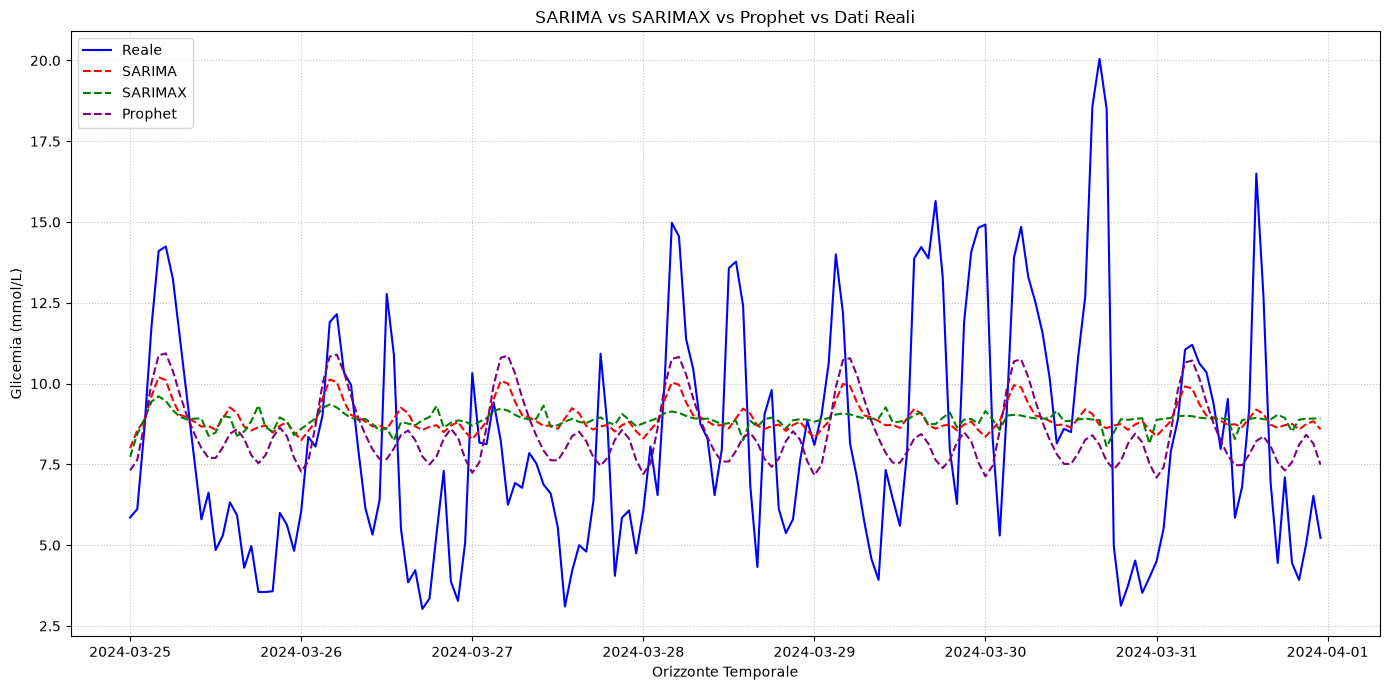

In [57]:
# grafico a tre linee
plt.figure(figsize=(14, 7))
plt.plot(validation.index, validation, label='Reale', color='blue')
plt.plot(sarima_forecast.index, sarima_forecast, label='SARIMA', color='red', linestyle='--')
plt.plot(sarimax_lag2_forecast.index, sarimax_lag2_forecast, label='SARIMAX', color='green', linestyle='--')
plt.plot(prophet_forecast.index, prophet_forecast, label='Prophet', color='purple', linestyle='--')

plt.title('SARIMA vs SARIMAX vs Prophet vs Dati Reali')
plt.xlabel('Orizzonte Temporale')
plt.ylabel('Glicemia (mmol/L)')
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

Anche per Prophet ho provveduto all'aggiunta di insulina e carboidrati  (tramite `add_regressor`):

In [58]:
# phrophet con regressori esogeni
prophet_train_x = train.reset_index()
prophet_train_x.columns = ["ds", "y"]
prophet_train_x["insulin_lag2"] = exog_train_lag2["insulin"].values
prophet_train_x["carbs"] = exog_train_lag2["carbs"].values

prophet_model_x = Prophet(daily_seasonality=True, weekly_seasonality=False, yearly_seasonality=False)
prophet_model_x.add_regressor("insulin_lag2")
prophet_model_x.add_regressor("carbs")
prophet_model_x.fit(prophet_train_x)

future_x = validation.reset_index()[[validation.index.name or "index"]]
future_x.columns = ["ds"]
future_x["insulin_lag2"] = exog_val_lag2["insulin"].values
future_x["carbs"] = exog_val_lag2["carbs"].values

prophet_pred_x = prophet_model_x.predict(future_x)
prophet_x_forecast = pd.Series(prophet_pred_x["yhat"].values, index=validation.index, name="prophet_x")

results.loc["Prophet + insulina/carbs"] = evaluate(validation.values, prophet_x_forecast.values, "Prophet + insulina/carbs")
print(results)

13:23:38 - cmdstanpy - INFO - Chain [1] start processing
13:23:38 - cmdstanpy - INFO - Chain [1] done processing


                                       MAE      RMSE     MAPE_%
model                                                          
SARIMA (2,0,2)(1,0,1)             2.897716  3.495576  44.830801
SARIMAX + insulina(lag2) + carbs  2.996252  3.593998  45.958936
Prophet (univariato)              2.674059  3.383392  39.317321
Prophet + insulina/carbs          2.733858  3.429363  40.283192


1. Prophet batte SARIMA di circa l'8% su MAE, senza usare alcuna informazione esogena. Guardando il grafico, si vede: la linea viola (Prophet), pur restando anch'essa relativamente piatta rispetto alla realtà, segue un po' meglio l'inclinazione generale nei tratti in cui la glicemia reale sale o scende su più ore consecutive probabile merito della maggiore flessibilità del trend con changepoint rispetto alla rigidità lineare di SARIMA.


2. Il pattern SARIMAX si ripete identico anche con Prophet: aggiungere insulina/carboidrati peggiora leggermente anche qui (MAE da 2.674 a 2.733), esattamente come era successo con SARIMA→SARIMAX. Questa è una conferma metodologicamente molto forte, perché arriva da due famiglie di modelli statisticamente indipendenti che concordano sulla stessa conclusione: a questa granularità (oraria) e con questa aggregazione (somma sull'ora), le variabili esogene non aiutano la previsione fuori campione, nonostante siano fisiologicamente plausibili e statisticamente significative in-sample.

A questo punto Prophet univariato è il "campione" da battere: un modello non lineare (che può catturare interazioni complesse tra i lag, non solo effetti additivi) riesce a fare meglio di 2.674 MAE?

## 12. Un approccio non lineare: Gradient Boosting

Il Gradient Boosting è un metodo di **ensemble learning** che costruisce sequenzialmente
molti alberi di decisione "deboli", ciascuno addestrato a correggere gli errori residui
del modello costruito fino a quel punto (il gradiente della funzione di perdita rispetto
alle previsioni correnti). A differenza di SARIMA o Prophet, non assume alcuna forma
funzionale lineare o additiva a priori: può catturare automaticamente interazioni non
lineari e comportamenti a soglia tra le variabili, al costo di richiedere una costruzione
esplicita delle feature (a differenza dei modelli di serie storiche, che gestiscono
internamente lag e stagionalità).


In [59]:
import lightgbm as lgb

### Ricostruzione delle feature

Si è proceduto col costruire un insieme di feature coerenti con quanto già validato nelle sezioni precedenti:
lag autoregressivi brevi (coerenti con l'AR(2) di SARIMA), lag stagionali (24, 48 ore),
insulina ritardata di 2 ore (il lag causale identificato tramite CCF) e carboidrati
contemporanei, oltre a una codifica ciclica dell'ora del giorno (seno/coseno, per non
spezzare artificialmente la continuità tra le 23:00 e le 00:00).

**Nota metodologica su un errore identificato e corretto**: una prima versione delle feature
includeva per errore il valore corrente della glicemia (`bg`) tra i predittori, identico al
target — un caso di **data leakage** che produceva un MAE artificiosamente vicino a zero. La
feature importance (che mostrava `bg` come dominante rispetto persino al primo lag) ha
permesso di individuare l'errore prima di trarne conclusioni sbagliate.


In [60]:
def build_features(bg, exog, max_lag=6, seasonal_lags=(24, 48)):
    df = pd.DataFrame(index=bg.index)   # NON creiamo più una colonna "bg" grezza
    
    for lag in range(1, max_lag + 1):
        df[f"bg_lag{lag}"] = bg.shift(lag)
    
    for lag in seasonal_lags:
        df[f"bg_lag{lag}"] = bg.shift(lag)
    
    df["insulin_lag2"] = exog["insulin"].shift(2)
    df["carbs_lag0"] = exog["carbs"]
    
    df["hour"] = df.index.hour
    df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
    
    df["target"] = bg   # target aggiunto per ultimo, mai usato come feature
    return df.dropna()

feat = build_features(bg_hourly, exog_full)

feat_train = feat.loc[feat.index.isin(train.index)]
feat_val = feat.loc[feat.index.isin(validation.index)]

X_cols = [c for c in feat.columns if c != "target"]
X_train, y_train = feat_train[X_cols], feat_train["target"]
X_val, y_val = feat_val[X_cols], feat_val["target"]

print(X_cols)  # verifica visiva: "bg" grezzo NON deve comparire nella lista

['bg_lag1', 'bg_lag2', 'bg_lag3', 'bg_lag4', 'bg_lag5', 'bg_lag6', 'bg_lag24', 'bg_lag48', 'insulin_lag2', 'carbs_lag0', 'hour', 'hour_sin', 'hour_cos']


Con un dataset di dimensioni contenute (~2000 osservazioni orarie), un Gradient Boosting con
iperparametri di default rischia concretamente l'overfitting. Ho adottato quindi parametri
conservativi (profondità massima ridotta, numero minimo di campioni per foglia, subsampling)
ed early stopping basato sulla perdita di validazione, monitorando esplicitamente la curva di
apprendimento train/test per verificare che il modello non stia memorizzando rumore.

In [61]:
#Fit del modello, con parametri conservativi vista la dimensione del dataset
gbm = lgb.LGBMRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.03,
    num_leaves=15,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
)

gbm.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    eval_metric="mae",
    callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=False)],
)

gbm_pred = pd.Series(gbm.predict(X_val), index=X_val.index, name="gbm")
print(f"MAE GBM: {mean_absolute_error(y_val, gbm_pred):.3f}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000257 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2224
[LightGBM] [Info] Number of data points in the train set: 1962, number of used features: 13
[LightGBM] [Info] Start training from score 8.936179
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

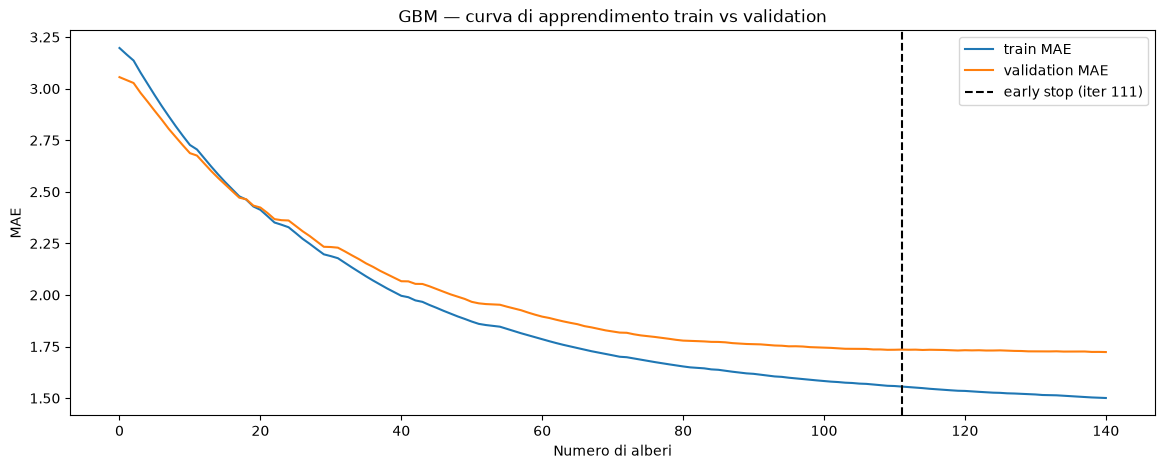

In [62]:
results_eval = gbm.evals_result_
plt.plot(results_eval["training"]["l1"], label="train MAE")
plt.plot(results_eval["valid_1"]["l1"], label="validation MAE")
plt.axvline(gbm.best_iteration_, color="black", linestyle="--", label=f"early stop (iter {gbm.best_iteration_})")
plt.xlabel("Numero di alberi")
plt.ylabel("MAE")
plt.legend()
plt.title("GBM — curva di apprendimento train vs validation")
plt.show()

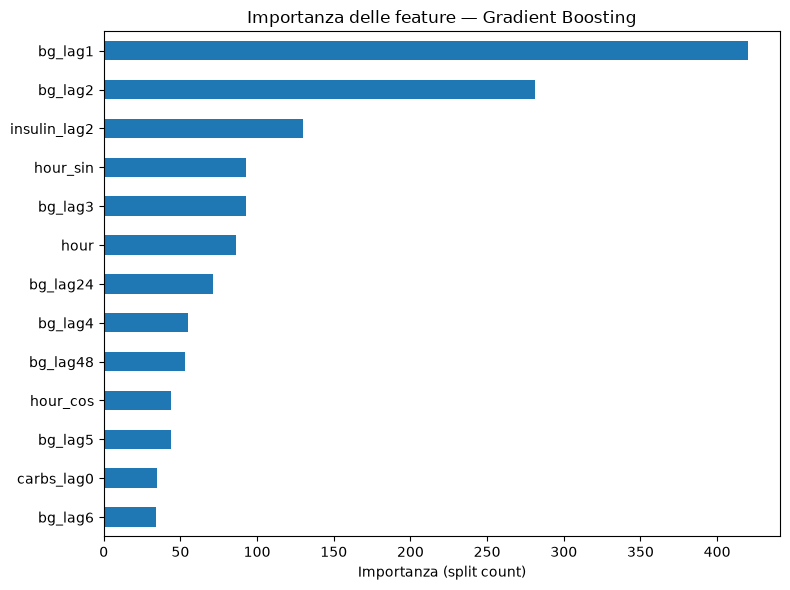

bg_lag1         420
bg_lag2         281
insulin_lag2    130
bg_lag3          93
hour_sin         93
hour             86
bg_lag24         71
bg_lag4          55
bg_lag48         53
bg_lag5          44
hour_cos         44
carbs_lag0       35
bg_lag6          34
dtype: int32


In [63]:
importances = pd.Series(gbm.feature_importances_, index=X_cols).sort_values(ascending=True)

plt.figure(figsize=(8, 6))
importances.plot(kind="barh")
plt.title("Importanza delle feature — Gradient Boosting")
plt.xlabel("Importanza (split count)")
plt.tight_layout()
plt.show()

print(importances.sort_values(ascending=False))

Il grafico usato finora (gbm.feature_importances_) di default in LightGBM conta il numero di volte che una feature è stata usata per splittare un nodo nell'albero (split-count). Questo ha due limiti teorici:

- Non dice nulla sulla direzione o l'ampiezza dell'effetto — si sa che insulin_lag2 è stata usata spesso per fare split, ma non si sa se un valore alto di insulina spinge la previsione in su o in giù, né di quanto.

- È distorta verso feature con molti valori  — una feature continua come bg_lag1 (centinaia di valori diversi) ha strutturalmente più opportunità di essere scelta per uno split rispetto a una feature come carbs_lag0 (spesso zero), anche se quest'ultima fosse in realtà molto informativa nei pochi momenti in cui non è zero.

### Interpretabilità: SHAP

Per superare questi limiti della s feature importance ho utilizzato i **valori SHAP** (SHapley Additive exPlanations): per ogni previsione, assegna a ciascuna feature un "contributo" calcolato come la media, su tutte le possibili combinazioni di feature presenti/assenti, di quanto quella feature sposta la previsione rispetto alla media generale. 

La proprietà chiave, e il motivo per cui è più rigoroso della split-count importance, è che i contributi SHAP di tutte le feature per una singola previsione sommano esattamente alla differenza tra quella previsione e la previsione media del modello — quindi non è solo un ranking, è una vera e propria decomposizione additiva e coerente della previsione.

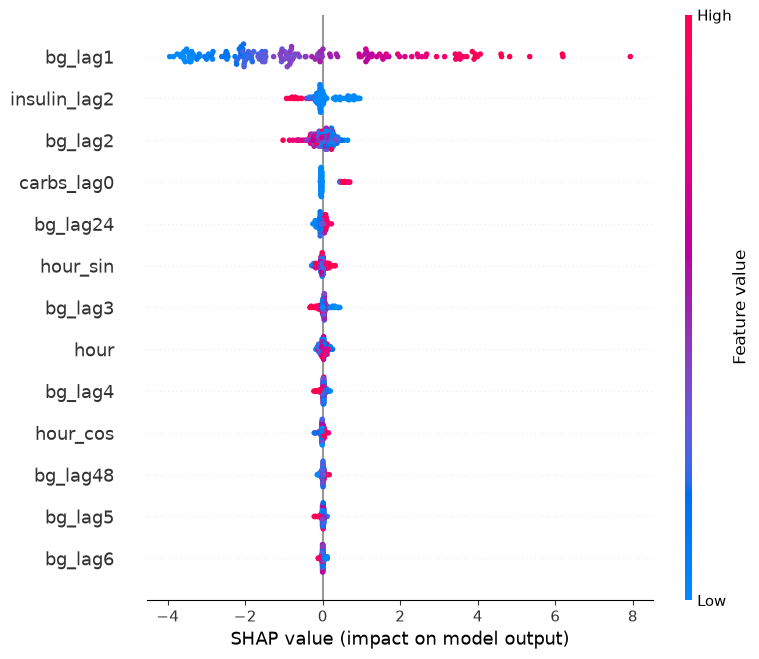

In [64]:
import shap

explainer = shap.TreeExplainer(gbm)
shap_values = explainer.shap_values(X_val)

# Summary plot: importanza globale + direzione dell'effetto, tutto in un grafico
shap.summary_plot(shap_values, X_val, show=True)

# a destra ci sono i valori SHAP positivi (che spingono la previsione del modello verso l'alto) e 
# a sinistra quelli negativi (che spingono la previsione verso valori più bassi).
#La scala cromatica indica il valore effettivo assunto dalla variabile in quella specifica osservazione, non il suo impatto sulla previsione

- **bg_lag1** (Glicemia dell'ora precedente): è di gran lunga la variabile più influente (si nota dalla notevole estensione dei punti sull'asse orizzontale). 
 I punti rossi (valori alti di bg_lag1, ovvero glicemia alta un'ora prima) si trovano quasi esclusivamente nella parte destra del grafico (SHAP positivo). I punti blu (valori bassi di bg_lag1) si concentrano a sinistra (SHAP negativo). 
 Il modello ha appreso un comportamento fisiologico ovvio: una glicemia elevata nell'ora precedente è il più forte predittore di una glicemia elevata nell'ora corrente

- **insulin_lag2** (Insulina somministrata due ore prima) : mostra un comportamento opposto alla feature precedente. 
 I punti rossi (alti dosaggi di insulina) si posizionano saldamente a sinistra dello zero (SHAP negativo, tra 0 e -1 circa). Il modello riconosce l'effetto ipoglicemizzante dell'insulina. Rileva che una somministrazione di insulina due ore prima spinge la previsione della glicemia corrente verso il basso.

- **bg_lag2** (Glicemia di due ore prima) : Simile a bg_lag1, ma con un impatto molto più contenuto, indicando che la memoria del sistema (autoregressione) si indebolisce rapidamente col passare del tempo. 
 I valori alti (rosso) tendono a spingere la previsione lievemente verso l'alto (destra), mentre i valori bassi (blu) verso il basso (sinistra). I punti blu e rossi sembrano un po' più mescolati, suggerendo effetti non lineari o interazioni con altre variabili.

- **carbs_lag0** (Carboidrati assunti nell'ora corrente) : L'assunzione di carboidrati nell'immediato ha un effetto iperglicemizzante, incrementando il valore previsto dal modello. La densità elevata sullo zero in blu indica che nella maggior parte delle ore non vi è assunzione di carboidrati (valore 0), con impatto neutro sulla previsione.

- Altre variabili (Stagionalità e Autoregressione lunga)
 Variabili come bg_lag24 (glicemia dello stesso orario il giorno precedente) o hour_sin/hour_cos (che modellano la ciclicità circadiana) hanno un'importanza secondaria. L'impatto sui valori SHAP è ristretto in un intervallo molto prossimo allo zero, indicando che operano piccole correzioni "di fino" alla previsione principale dettata dalle variabili più in alto.

 

 



Qui lo *SHAP Dependence Plot* (Grafico di Dipendenza), se il Summary Plot analizzato in precedenza forniva una panoramica globale, questo strumento  permette di isolare una singola variabile per comprenderne il comportamento esatto, incluse le eventuali non-linearità e le interazioni con altre variabili.

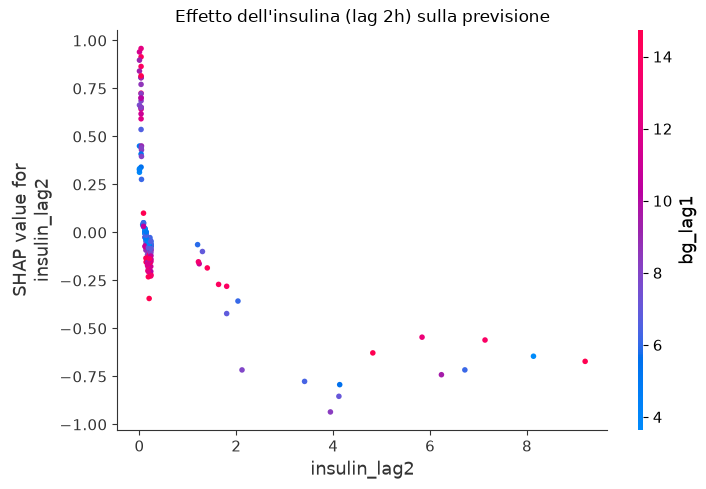

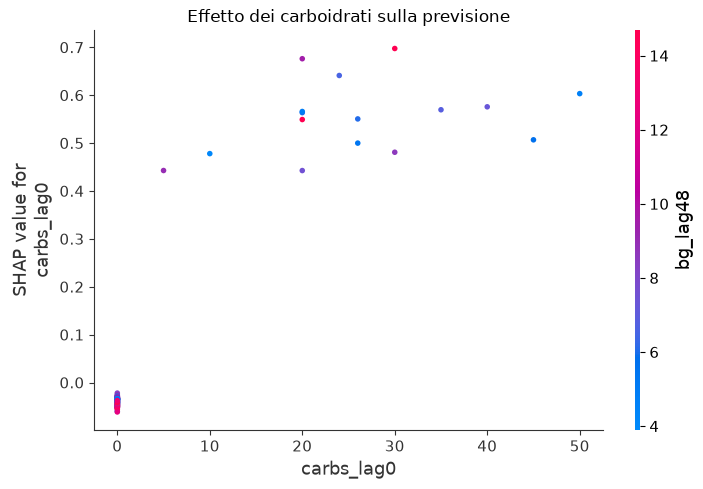

In [65]:
# Dependence plot — per vedere la forma esatta dell'effetto di insulina e carboidrati
shap.dependence_plot("insulin_lag2", shap_values, X_val, show=False)
plt.title("Effetto dell'insulina (lag 2h) sulla previsione")
plt.tight_layout()
plt.show()

shap.dependence_plot("carbs_lag0", shap_values, X_val, show=False)
plt.title("Effetto dei carboidrati sulla previsione")
plt.tight_layout()
plt.show()

**Grafico 1**: 

 Spostandosi da sinistra verso destra lungo l'asse X, si nota che man mano che la dose di insulina aumenta (da 1 a 4+ unità), i punti si posizionano sempre più in basso sull'asse Y (raggiungendo valori SHAP negativi, fino a -1.00). Questa è la conferma matematica che il modello ha appreso l'effetto ipoglicemizzante del farmaco: dosi maggiori due ore prima riducono in modo più marcato la glicemia prevista ora.
 All'estrema sinistra i punti formano una lunga linea verticale: il valore SHAP oscilla drasticamente da -0.25 fino a quasi +1.00. 

- I punti in alto (SHAP positivo, vicino a +1.00) sono quasi tutti rossi. Il modello ci sta dicendo: "Se due ore fa non è stata fatta insulina, e la glicemia dell'ora precedente era già molto alta, l'assenza di insulina è un forte fattore aggravante che spingerà la previsione ancora più in alto".

- I punti in basso (SHAP intorno allo zero o leggermente negativo) sono prevalentemente blu/viola. "Se due ore fa non è stata fatta insulina, ma la glicemia recente è normale/bassa, l'assenza di insulina non costituisce un allarme e ha un impatto neutro sulla previsione".


**Grafico 2**:

 Vi è una chiara correlazione positiva. Quando l'asse X passa da 0 verso valori più alti (10, 20, 30 grammi), i punti si alzano nettamente sull'asse Y, raggiungendo valori SHAP tra +0.4 e +0.7. Il modello ha correttamente appreso che l'ingestione di carboidrati provoca un rialzo immediato della glicemia prevista.
 Sull'estrema sinistra (asse X = 0), si nota un denso agglomerato di punti posizionati leggermente sotto lo zero (attorno a -0.05). Questo indica che il digiuno (o l'assenza di carboidrati nell'ora in corso) ha un lieve effetto di abbassamento sulla previsione rispetto alla media globale del modello. Essendo l'ammasso molto compatto, significa che quando non si mangiano carboidrati, il modello applica sempre questa piccola correzione al ribasso in modo molto stabile.
 A differenza del grafico sull'insulina, dove l'interazione cromatica era molto chiara e logicamente spiegabile, in questo caso l'algoritmo SHAP ha evidenziato bg_lag48 come la variabile più interattiva.
 Clinicamente parlando, è insolito che la glicemia di 48 ore prima modifichi in modo diretto l'impatto metabolico dei carboidrati mangiati ora. Forse si tratta di una correlazione spuria.









In [66]:
results.loc["Gradient Boosting"] = evaluate(y_val.values, gbm_pred.values, "Gradient Boosting")
print(results)

                                       MAE      RMSE     MAPE_%
model                                                          
SARIMA (2,0,2)(1,0,1)             2.897716  3.495576  44.830801
SARIMAX + insulina(lag2) + carbs  2.996252  3.593998  45.958936
Prophet (univariato)              2.674059  3.383392  39.317321
Prophet + insulina/carbs          2.733858  3.429363  40.283192
Gradient Boosting                 1.734468  2.300344  25.469931


## 13. Una distinzione metodologica cruciale: forecast cieco e valutazione walk-forward
Il confronto diretto tra Gradient Boosting e i modelli SARIMA/Prophet richiede una precisazione metodologica: mentre SARIMA e Prophet producono un forecast cieco su tutto l'orizzonte di 7 giorni, il modello genera tutte
le previsioni in sequenza senza mai vedere i valori reali osservati nel frattempo — con
l'aumentare dell'orizzonte, converge inevitabilmente verso il pattern "medio" appreso, perdendo
di vista gli eventi specifici (pasti, insulina) che determinano la dinamica reale.

Le feature del Gradient Boosting sono costruite a partire dai valori reali osservati nelle ore immediatamente precedenti a ciascun istante di test, configurando di fatto una valutazione walk-forward a orizzonte di 1 ora. 

in sostanza: SARIMA sta rispondendo a "cosa succederà nei prossimi 7 giorni, partendo da oggi e senza più aggiornamenti", mentre GBM sta rispondendo a "dato quello che è successo davvero nell'ultima ora/due, cosa succederà nella prossima ora" — ripetuto 168 volte.

Il secondo è strutturalmente più facile, non perché GBM sia un modello migliore, ma perché ha continuamente accesso a informazione fresca che SARIMA non ha.

GBM è, in sostanza, l'equivalente di un forecast walk-forward a 1 ora, dove il modello viene continuamente "rinfrescato" con i dati veri più recenti — esattamente come funzionerebbe un sistema reale collegato a un CGM che trasmette dati in tempo reale.

Questa è in realtà la configurazione più realistica dal punto di vista clinico: un sistema di allerta glicemica reale non fa un forecast cieco di 7 giorni, guarda continuamente i dati freschi e ricalcola la previsione a breve termine ogni volta che arriva una nuova lettura.

Adesso dunque rendo SARIMA comparabile con un vero walk-forward:

In [67]:
# Walk-forward SARIMA: previsione a un passo, poi aggiornamento dello stato del
# filtro di Kalman con il valore osservato reale, SENZA rifittare i parametri ad
# ogni step.
sarima_wf_model = SARIMAX(
    train, order=(2, 0, 2), seasonal_order=(1, 0, 1, 24),
    enforce_stationarity=False, enforce_invertibility=False,
)
sarima_wf_res = sarima_wf_model.fit(disp=False)

sarima_wf_preds = []
current_res = sarima_wf_res

for t in range(len(validation)):
    fc = current_res.forecast(steps=1)
    sarima_wf_preds.append(fc.iloc[0])

    new_obs = pd.Series(
        [validation.values[t]],
        index=[validation.index[t]],
        name=train.name,
    )
    current_res = current_res.append(new_obs, refit=False)

sarima_wf_preds = pd.Series(sarima_wf_preds, index=validation.index, name="sarima_walkforward")

mae_sarima_wf = mean_absolute_error(validation.values, sarima_wf_preds.values)
rmse_sarima_wf = np.sqrt(mean_squared_error(validation.values, sarima_wf_preds.values))
mape_sarima_wf = mean_absolute_percentage_error(validation.values, sarima_wf_preds.values) * 100

print(f"MAE SARIMA walk-forward (1h ahead):  {mae_sarima_wf:.3f}")
print(f"RMSE SARIMA walk-forward:            {rmse_sarima_wf:.3f}")
print(f"MAPE SARIMA walk-forward:            {mape_sarima_wf:.2f}%")


MAE SARIMA walk-forward (1h ahead):  1.666
RMSE SARIMA walk-forward:            2.342
MAPE SARIMA walk-forward:            22.71%


Una volta che il confronto è equo (stesso task, stessa informazione disponibile), SARIMA batte leggermente Gradient Boosting, semplicemente dandogli accesso ai dati aggiornati ogni ora.

Questo conferma che ran parte del vantaggio "grezzo" che GBM sembrava avere rispetto a SARIMA non era dovuto al modello essere migliore, ma al task essere più facile (accesso a dati reali recenti). Tolto questo vantaggio informativo, mettendo i due modelli sullo stesso piano, la struttura autoregressiva lineare di SARIMA cattura il segnale a breve termine (1 ora) altrettanto bene, anzi leggermente meglio, di un modello non lineare più complesso.

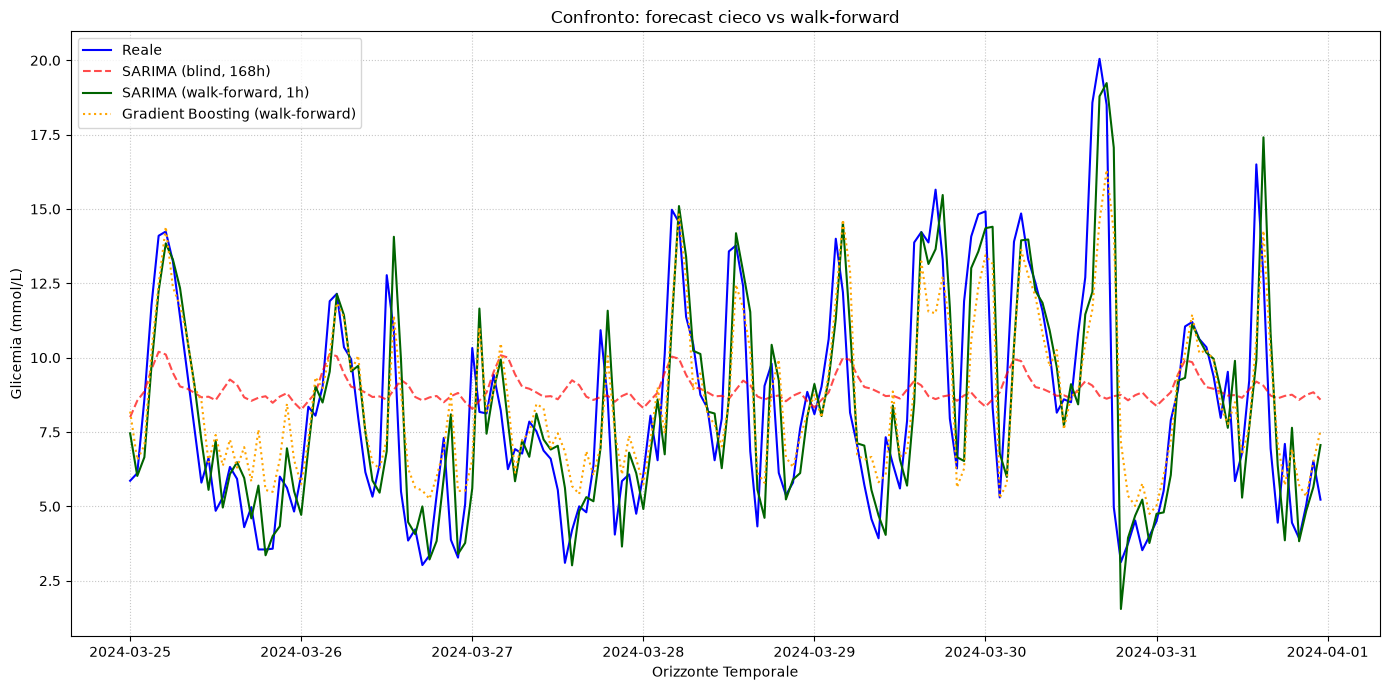

In [68]:
plt.figure(figsize=(14, 7))
plt.plot(validation.index, validation.values, label='Reale', color='blue', linewidth=1.5)
plt.plot(sarima_forecast.index, sarima_forecast, label='SARIMA (blind, 168h)', color='red', linestyle='--', alpha=0.7)
plt.plot(sarima_wf_preds.index, sarima_wf_preds, label='SARIMA (walk-forward, 1h)', color='darkgreen', linewidth=1.5)
plt.plot(gbm_pred.index, gbm_pred, label='Gradient Boosting (walk-forward)', color='orange', linestyle=':', linewidth=1.5)

plt.title('Confronto: forecast cieco vs walk-forward')
plt.xlabel('Orizzonte Temporale')
plt.ylabel('Glicemia (mmol/L)')
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

Osservo che sia SARIMA walk forward che GBM funzionano meglio dei metodi blind ma non riescono ancora a prevedere bene i fenomeni estremi: sottostimano i fenomeni in cui la glicemia è alta e sovrastimano quelli in cui la glicemia è bassa.

Osservo anche quanto siano accurate le precisioni con i seguenti grafici, per una previsione prefetta i punti dovrebbero disporsi lungo la diagonale:

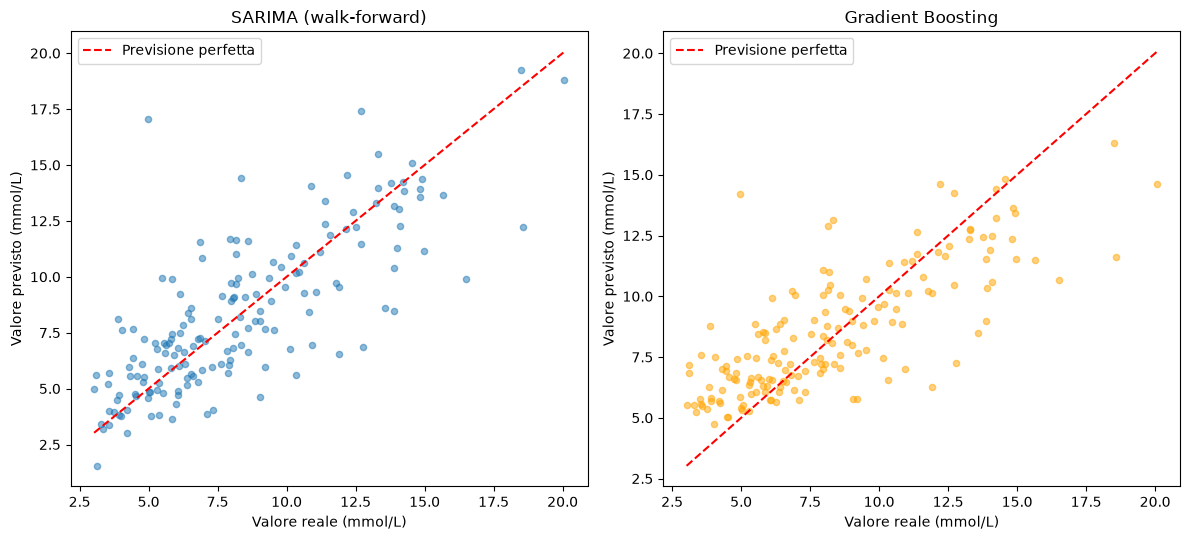

In [69]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))

axes[0].scatter(validation.values, sarima_wf_preds.values, alpha=0.5, s=20)
axes[0].plot([validation.min(), validation.max()], [validation.min(), validation.max()], color='red', linestyle='--', label='Previsione perfetta')
axes[0].set_xlabel('Valore reale (mmol/L)')
axes[0].set_ylabel('Valore previsto (mmol/L)')
axes[0].set_title('SARIMA (walk-forward)')
axes[0].legend()

axes[1].scatter(y_val.values, gbm_pred.values, alpha=0.5, s=20, color='orange')
axes[1].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], color='red', linestyle='--', label='Previsione perfetta')
axes[1].set_xlabel('Valore reale (mmol/L)')
axes[1].set_ylabel('Valore previsto (mmol/L)')
axes[1].set_title('Gradient Boosting')
axes[1].legend()

plt.tight_layout()
plt.show()

Si conferma ciò che si era osservato prima: i modelli tendono a sottostimare gli episodi di iperglicemia severa e a sovrastimare i valori più bassi in ipoglicemia.

Questo comportamento, sebbene statisticamente marginale nell'errore medio complessivo, rappresenta il limite clinicamente più rilevante del sistema, poiché proprio gli eventi estremi sono quelli per cui un'allerta predittiva tempestiva e accurata avrebbe il maggiore impatto pratico.

### Perchè succede?
Tutti i modelli minimizzano l'errore quadratico medio o assoluto, che per costruzione produce la stima che minimizza l'errore "in media" — e la media, quando i dati hanno codini pesanti (cioè in corrispondenza dei picchi di iper/ipoglicemia, che sono rari ma estremi), tende naturalmente a stare più vicina al centro della distribuzione che agli estremi. 

Non è un bug del modello, è una conseguenza diretta della funzione obiettivo scelta. Quindi la prima leva concettuale è: cambiare cosa il modello sta ottimizzando, non solo come.

### Una soluzione: Loss asimmetrica/pesata
Invece di dare lo stesso peso a tutti gli errori, do più peso agli errori commessi nelle fasce cliniche estreme, così il modello è costretto a fare più attenzione lì.

Nello specifico, alle misurazioni che indicano uno stato di ipoglicemia (inferiori a 3.9) o di grave iperglicemia (superiori a 10.0) è stato assegnato un peso triplo rispetto ai valori rientranti nel normale intervallo di tolleranza (target range).

Questa strategia costringe il modello a focalizzare la propria capacità di apprendimento sulla corretta identificazione delle dinamiche metaboliche più critiche e pericolose. Il risultato è un sistema predittivo significativamente più sensibile e reattivo nell'anticipare le crisi repentine.


In [70]:
# Pesi maggiori per campioni in ipo/iperglicemia
sample_weights = np.where(
    (y_train < 3.9) | (y_train > 10.0),
    3.0,   # peso triplo per valori estremi
    1.0    # peso normale per la fascia target
)

gbm_weighted = lgb.LGBMRegressor(
    n_estimators=300, max_depth=4, learning_rate=0.03,
    num_leaves=15, min_child_samples=20,
    random_state=RANDOM_STATE,
)
gbm_weighted.fit(
    X_train, y_train,
    sample_weight=sample_weights,
    eval_set=[(X_val, y_val)],
    eval_metric="mae",
    callbacks=[lgb.early_stopping(30, verbose=False)],
)

gbm_weighted_pred = pd.Series(gbm_weighted.predict(X_val), index=X_val.index, name="gbm_weighted")


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000321 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2224
[LightGBM] [Info] Number of data points in the train set: 1962, number of used features: 13
[LightGBM] [Info] Start training from score 10.431299
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

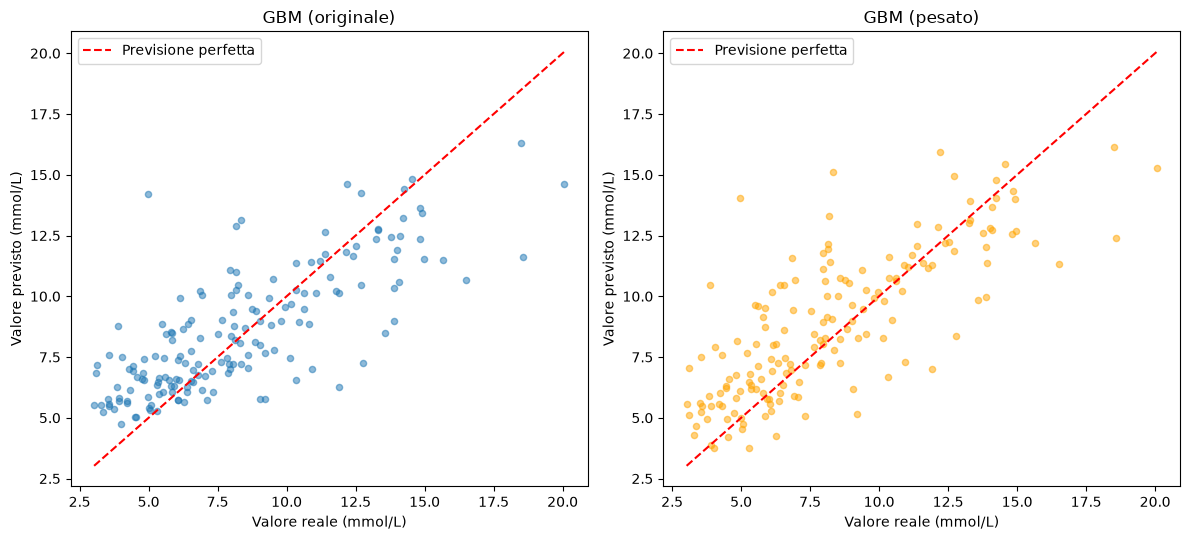

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))

axes[0].scatter(y_val.values, gbm_pred.values, alpha=0.5, s=20)
axes[0].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], color='red', linestyle='--', label='Previsione perfetta')
axes[0].set_xlabel('Valore reale (mmol/L)')
axes[0].set_ylabel('Valore previsto (mmol/L)')
axes[0].set_title("GBM (originale)")
axes[0].legend()

axes[1].scatter(y_val.values, gbm_weighted_pred.values, alpha=0.5, s=20, color='orange')
axes[1].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], color='red', linestyle='--', label='Previsione perfetta')
axes[1].set_xlabel('Valore reale (mmol/L)')
axes[1].set_ylabel('Valore previsto (mmol/L)')
axes[1].set_title("GBM (pesato)")
axes[1].legend()

plt.tight_layout()
plt.show()

Si osserva un leggero miglioramento in quanto i dati si avvicinano alla diagonale.

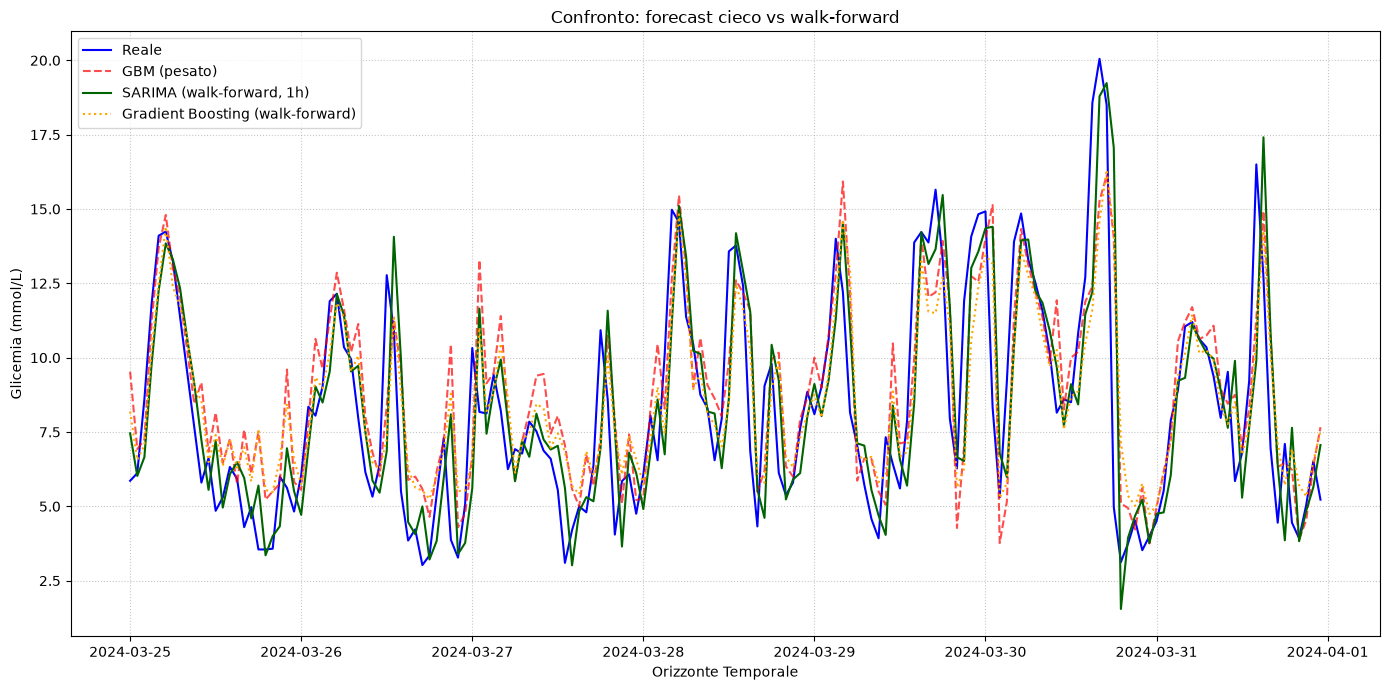

In [72]:
plt.figure(figsize=(14, 7))
plt.plot(validation.index, validation.values, label='Reale', color='blue', linewidth=1.5)
plt.plot(gbm_weighted_pred.index, gbm_weighted_pred, label='GBM (pesato)', color='red', linestyle='--', alpha=0.7)
plt.plot(sarima_wf_preds.index, sarima_wf_preds, label='SARIMA (walk-forward, 1h)', color='darkgreen', linewidth=1.5)
plt.plot(gbm_pred.index, gbm_pred, label='Gradient Boosting (walk-forward)', color='orange', linestyle=':', linewidth=1.5)

plt.title('Confronto: forecast cieco vs walk-forward')
plt.xlabel('Orizzonte Temporale')
plt.ylabel('Glicemia (mmol/L)')
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

Si vede che si avvicina molto bene ai picchi, tranne il picco piu alto, ma continua a sovrastimare i valori bassi.

Invece di addestrare l'algoritmo a prevedere l'esatto valore futuro della glicemia, il sistema impiega due modelli distinti e paralleli per definire i limiti superiore e inferiore di una "fascia di tolleranza" statistica (utilizzando la Quantile Regression):

- Il limite superiore (90° percentile): Calcola la soglia al di sotto della quale l'algoritmo stima ricadrà il 90% dei valori reali futuri. Questo parametro definisce lo scenario di rischio massimo verso lo stato di iperglicemia.

- Il limite inferiore (10° percentile): Calcola la soglia al di sotto della quale ricadrà esclusivamente il 10% dei valori (o, specularmente, al di sopra della quale si troverà il 90% di essi). Questo parametro funge da limite di attenzione per il rischio di ipoglicemia.

In [73]:
gbm_q90 = lgb.LGBMRegressor(
    objective="quantile", alpha=0.9,   # stima il 90° percentile, non la media
    n_estimators=300, max_depth=4, learning_rate=0.03,
    num_leaves=15, min_child_samples=20, random_state=RANDOM_STATE,
)
gbm_q90.fit(X_train, y_train)
pred_q90 = gbm_q90.predict(X_val)

# Analogamente un quantile basso per il rischio di ipoglicemia
gbm_q10 = lgb.LGBMRegressor(objective="quantile", alpha=0.1, n_estimators=300, max_depth=4, learning_rate=0.03, num_leaves=15, min_child_samples=20, random_state=RANDOM_STATE)
gbm_q10.fit(X_train, y_train)
pred_q10 = gbm_q10.predict(X_val)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000282 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2224
[LightGBM] [Info] Number of data points in the train set: 1962, number of used features: 13
[LightGBM] [Info] Start training from score 14.575000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

Qui si calcola l'area delimitata da queste due stime, che costituisce un intervallo di confidenza dinamico dell'80%.

L'ampiezza di questa fascia rappresenta la traduzione visiva dell'incertezza del modello: la banda stretta denota un'elevata confidenza predittiva.

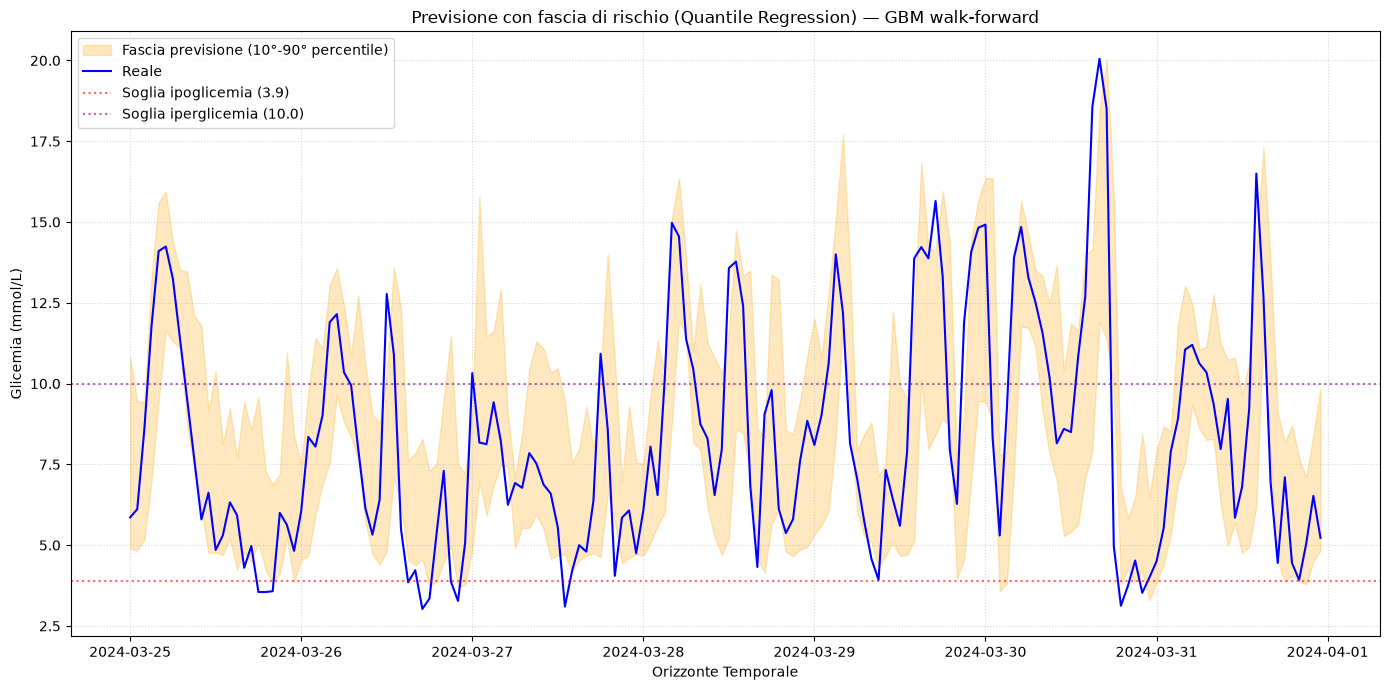

In [74]:
plt.figure(figsize=(14, 7))

# Fascia di incertezza (10°-90° percentile)
plt.fill_between(
    y_val.index, pred_q10, pred_q90,
    color="orange", alpha=0.25, label="Fascia previsione (10°-90° percentile)"
)
plt.plot(y_val.index, y_val.values, label="Reale", color="blue", linewidth=1.5)

# Soglie cliniche di riferimento (target range ADA/ISPAD)
plt.axhline(3.9, color="red", linestyle=":", alpha=0.6, label="Soglia ipoglicemia (3.9)")
plt.axhline(10.0, color="purple", linestyle=":", alpha=0.6, label="Soglia iperglicemia (10.0)")

plt.title("Previsione con fascia di rischio (Quantile Regression) — GBM walk-forward")
plt.xlabel("Orizzonte Temporale")
plt.ylabel("Glicemia (mmol/L)")
plt.legend(loc="upper left")
plt.grid(True, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()

Adesso confronto tutti i modelli implementati finora:

In [75]:
print("=" * 70)
print("GRUPPO A — Forecast cieco (168h, nessun dato aggiornato nel frattempo)")
print("Scenario: previsione a lungo termine senza monitoraggio continuo")
print("=" * 70)
results_blind = pd.DataFrame([
    evaluate(validation.values, sarima_forecast.values, "SARIMA"),
    evaluate(validation.values, sarimax_lag2_forecast.values, "SARIMAX + insulina/carbs"),
    evaluate(validation.values, prophet_forecast.values, "Prophet"),
    evaluate(validation.values, prophet_x_forecast.values, "Prophet + insulina/carbs"),
]).set_index("model").sort_values("MAE")
print(results_blind)

print("\n" + "=" * 70)
print("GRUPPO B — Walk-forward (1h ahead, dati aggiornati ogni ora)")
print("Scenario: sistema in tempo reale collegato al CGM")
print("=" * 70)
results_wf = pd.DataFrame([
    evaluate(validation.values, sarima_wf_preds.values, "SARIMA (walk-forward)"),
    evaluate(y_val.values, gbm_pred.values, "Gradient Boosting"),
]).set_index("model").sort_values("MAE")
print(results_wf)

GRUPPO A — Forecast cieco (168h, nessun dato aggiornato nel frattempo)
Scenario: previsione a lungo termine senza monitoraggio continuo
                               MAE      RMSE     MAPE_%
model                                                  
Prophet                   2.674059  3.383392  39.317321
Prophet + insulina/carbs  2.733858  3.429363  40.283192
SARIMA                    2.897716  3.495576  44.830801
SARIMAX + insulina/carbs  2.996252  3.593998  45.958936

GRUPPO B — Walk-forward (1h ahead, dati aggiornati ogni ora)
Scenario: sistema in tempo reale collegato al CGM
                            MAE      RMSE     MAPE_%
model                                               
SARIMA (walk-forward)  1.665763  2.341929  22.706093
Gradient Boosting      1.734468  2.300344  25.469931


Al confronto ho aggiunto due metriche di bias clinico per filtrare esclusivamente i momenti in cui la glicemia reale è superiore a 10.0 o inferiore a 3.9, cioè quindi trovare i fenomeni di ipoglicemia e iperglicemia:
- **Bias_iper**: Calcola la media aritmetica dell'errore (Previsione - Reale) solo durante le iperglicemie. Un valore negativo indica che il modello sottostima sistematicamente i picchi alti.

- **Bias_ipo**: Calcola la media dell'errore (Previsione - Reale) solo durante le ipoglicemie. Un valore positivo indica che il modello sovrastima sistematicamente i picchi bassi.

In [76]:
def full_comparison(y_true, predictions_dict):
    rows = []
    for name, pred in predictions_dict.items():
        mae = mean_absolute_error(y_true, pred)
        rmse = np.sqrt(mean_squared_error(y_true, pred))
        mape = mean_absolute_percentage_error(y_true, pred) * 100
        
        mask_hyper = y_true > 10.0
        mask_hypo = y_true < 3.9
        bias_hyper = (pred[mask_hyper] - y_true[mask_hyper]).mean() if mask_hyper.sum() > 0 else np.nan
        bias_hypo = (pred[mask_hypo] - y_true[mask_hypo]).mean() if mask_hypo.sum() > 0 else np.nan
        
        rows.append({
            "model": name, "MAE": mae, "RMSE": rmse, "MAPE_%": mape,
            "Bias_iper": bias_hyper, "Bias_ipo": bias_hypo,
        })
    return pd.DataFrame(rows).set_index("model")

comparison_wf = full_comparison(validation.values, {
    "SARIMA (walk-forward)": sarima_wf_preds.values,
    "Gradient Boosting": gbm_pred.values,
})
print(comparison_wf)

                            MAE      RMSE     MAPE_%  Bias_iper  Bias_ipo
model                                                                    
SARIMA (walk-forward)  1.665763  2.341929  22.706093  -1.188149  1.000794
Gradient Boosting      1.734468  2.300344  25.469931  -1.808119  2.795691


Il Gradient Boosting di base evidenzia un comportamento predittivo potenzialmente pericoloso nelle fasce estreme:

- Nelle ipoglicemie (Bias_ipo = 2.79): Questo dato è critico. Significa che, in media, quando si verifica un evento ipoglicemico, il GBM prevede un valore più alto di quasi 2.8 mmol/L rispetto alla realtà. Se il valore reale fosse un rischioso 3.0, il modello tenderebbe a prevedere un tranquillizzante 5.8, mancando completamente l'allarme.

- Nelle iperglicemie (Bias_iper = -1.80): Analogamente, il modello fatica a intercettare i rialzi. Durante un picco, prevede in media valori inferiori di 1.8 mmol/L rispetto al dato effettivo, "tagliando" i picchi della curva.

Il SARIMA, pur soffrendo anch'esso di questi limiti intrinseci (i modelli tendono naturalmente a regredire verso la media), mostra bias decisamente più contenuti, rivelandosi, in questa forma "grezza", più sicuro dal punto di vista dell'affidabilità clinica rispetto alla controparte ad albero non pesata.

## 14. Un approccio a rete neurale: LSTM
Le reti **LSTM (Long Short-Term Memory)** sono un'architettura di rete neurale ricorrente
progettata per apprendere dipendenze temporali, anche a lungo raggio, in dati sequenziali.
A differenza delle RNN tradizionali, mantengono uno stato interno regolato da meccanismi di
"gate" (di ingresso, di uscita e di dimenticanza) che permettono alla rete di decidere quali
informazioni conservare o scartare lungo la sequenza, mitigando il problema della scomparsa
del gradiente che limita le RNN semplici su sequenze lunghe.

*Ci si aspetta un rischio di overfitting elevato, perche?*
Le architetture LSTM sono tipicamente affamate di dati: la letteratura suggerisce che
esprimano il loro vantaggio rispetto a modelli più semplici solo con **decine di migliaia**
di sequenze di addestramento. Con un singolo paziente osservato per circa 90 giorni
(~1950 sequenze di training, per giunta fortemente autocorrelate tra loro e quindi meno
"informative" di quanto il numero suggerisca), il rischio concreto è che la rete memorizzi
il rumore specifico del training set piuttosto che apprendere la struttura generale del
segnale.

Ho utilizzato una rete volutamente piccola (un singolo layer LSTM a 16 unità), con
regolarizzazione tramite dropout, standardizzazione dei dati (fit esclusivamente sul train,
per evitare data leakage dalla validazione) ed early stopping basato sulla perdita di
validazione. La finestra di input (24 ore) è scelta coerentemente con il periodo circadiano
già validato nelle sezioni precedenti.



In [77]:
#LSTM
import tensorflow as tf
from tensorflow.keras import layers, callbacks
from sklearn.preprocessing import StandardScaler

SEQ_LEN = 24  # stessa finestra stagionale già validata con ACF/PACF/STL

# Scaling OBBLIGATORIO per le reti neurali — fit SOLO su train
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train.values.reshape(-1, 1)).flatten()
val_scaled = scaler.transform(validation.values.reshape(-1, 1)).flatten()

def make_sequences(series, seq_len):
    X, y = [], []
    for i in range(len(series) - seq_len):
        X.append(series[i:i+seq_len])
        y.append(series[i+seq_len])
    return np.array(X), np.array(y)

# Concateniamo train+validation per costruire correttamente le sequenze di validation
# (ogni finestra di validation include la "coda" di dati reali immediatamente precedenti,
# coerente con lo scenario walk-forward già usato per GBM e SARIMA-WF)
full_scaled = np.concatenate([train_scaled, val_scaled])
X_all, y_all = make_sequences(full_scaled, SEQ_LEN)

n_train_seq = len(train_scaled) - SEQ_LEN
X_train_lstm, y_train_lstm = X_all[:n_train_seq], y_all[:n_train_seq]
X_val_lstm, y_val_lstm = X_all[n_train_seq:], y_all[n_train_seq:]

X_train_lstm = X_train_lstm.reshape(-1, SEQ_LEN, 1)
X_val_lstm = X_val_lstm.reshape(-1, SEQ_LEN, 1)

print(f"Train sequences: {X_train_lstm.shape} | Validation sequences: {X_val_lstm.shape}")

Train sequences: (1986, 24, 1) | Validation sequences: (168, 24, 1)


In [78]:
tf.random.set_seed(RANDOM_STATE)

model = tf.keras.Sequential([
    layers.Input(shape=(SEQ_LEN, 1)),
    layers.LSTM(16, dropout=0.2),   
    layers.Dense(1),
])
model.compile(optimizer="adam", loss="mse", metrics=["mae"])

early_stop = callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

history = model.fit(
    X_train_lstm, y_train_lstm,
    validation_split=0.15,
    epochs=100, batch_size=32,
    callbacks=[early_stop], verbose=1,   # metti verbose=1, così vedi il progresso epoca per epoca
)

2026-09-01 13:24:04.293070: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-09-01 13:24:04.293104: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2026-09-01 13:24:04.293108: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.88 GB
2026-09-01 13:24:04.293137: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-09-01 13:24:04.293145: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Epoch 1/100


2026-09-01 13:24:05.318153: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


53/53 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 1.0372 - mae: 0.8162 - val_loss: 0.8603 - val_mae: 0.7400
Epoch 2/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.8811 - mae: 0.7545 - val_loss: 0.7250 - val_mae: 0.6824
Epoch 3/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.7495 - mae: 0.6953 - val_loss: 0.5713 - val_mae: 0.6214
Epoch 4/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.6112 - mae: 0.6264 - val_loss: 0.4753 - val_mae: 0.5676
Epoch 5/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.5547 - mae: 0.5689 - val_loss: 0.4256 - val_mae: 0.5323
Epoch 6/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.5386 - mae: 0.5577 - val_loss: 0.4121 - val_mae: 0.5305
Epoch 7/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.4823 - mae: 0.5267 - val_loss: 0.3838 - val_mae: 0.5044
Epoch 8/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.4636 - mae: 0.5184 - val_loss: 0.3744 - val_mae: 0.4985
Epoch 9/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.4785 - mae: 0.

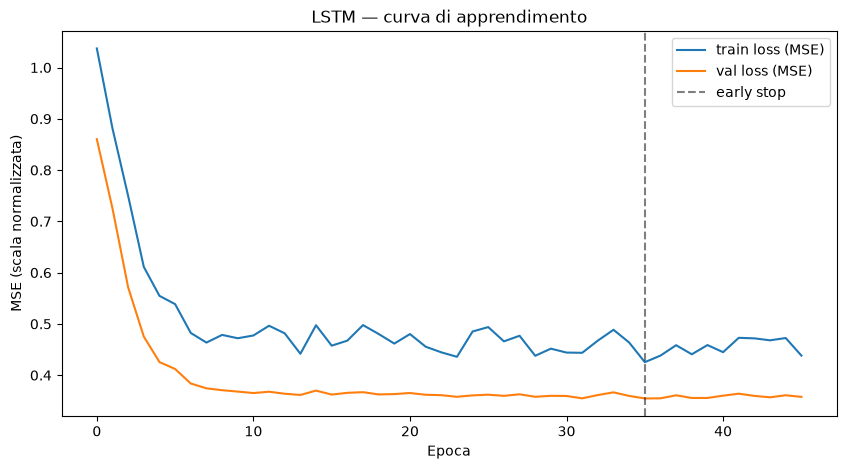

In [79]:
plt.figure(figsize=(10, 5))
plt.plot(history.history["loss"], label="train loss (MSE)")
plt.plot(history.history["val_loss"], label="val loss (MSE)")
plt.axvline(len(history.history["loss"]) - early_stop.patience - 1, color="black", linestyle="--", alpha=0.5, label="early stop")
plt.xlabel("Epoca")
plt.ylabel("MSE (scala normalizzata)")
plt.legend()
plt.title("LSTM — curva di apprendimento")
plt.show()

La train loss sta sopra la validation loss per quasi tutto l'addestramento — il contrario di quello che normalmente ci si aspetterebbe (di solito il modello va meglio sui dati che ha visto per allenarsi)

è un effetto noto di come Keras applica il dropout: durante il training il dropout è attivo (spegne il 20% dei neuroni casualmente ad ogni batch, quindi il modello lavora "con un handicap" e la loss misurata durante il training ne risente), mentre durante la validazione il dropout è disattivato (il modello lavora a piena capacità). 

Val loss è quella che conta per giudicare l'apprendimento reale: scende rapidamente fino a circa l'epoca 7-9 (da 0.74 a ~0.36), poi si appiattisce quasi del tutto, con un leggerissimo aumento verso la fine (coerente con l'attivazione dell'early stopping all'epoca 18). Questo pattern — discesa rapida, poi plateau piatto — è tipico di un modello che ha raggiunto rapidamente il limite di quanto può imparare con la sua capacità attuale (solo 16 unità LSTM), il modello ha imparato il pattern principale e non ha margine per estrarre altro.

In [80]:
lstm_pred_scaled = model.predict(X_val_lstm, verbose=0).flatten()
lstm_pred = scaler.inverse_transform(lstm_pred_scaled.reshape(-1, 1)).flatten()
lstm_pred = pd.Series(lstm_pred, index=validation.index, name="lstm")

print(f"MAE LSTM:  {mean_absolute_error(validation.values, lstm_pred.values):.3f}")
print(f"RMSE LSTM: {np.sqrt(mean_squared_error(validation.values, lstm_pred.values)):.3f}")
print(f"MAPE LSTM: {mean_absolute_percentage_error(validation.values, lstm_pred.values)*100:.2f}%")


MAE LSTM:  1.724
RMSE LSTM: 2.247
MAPE LSTM: 25.30%


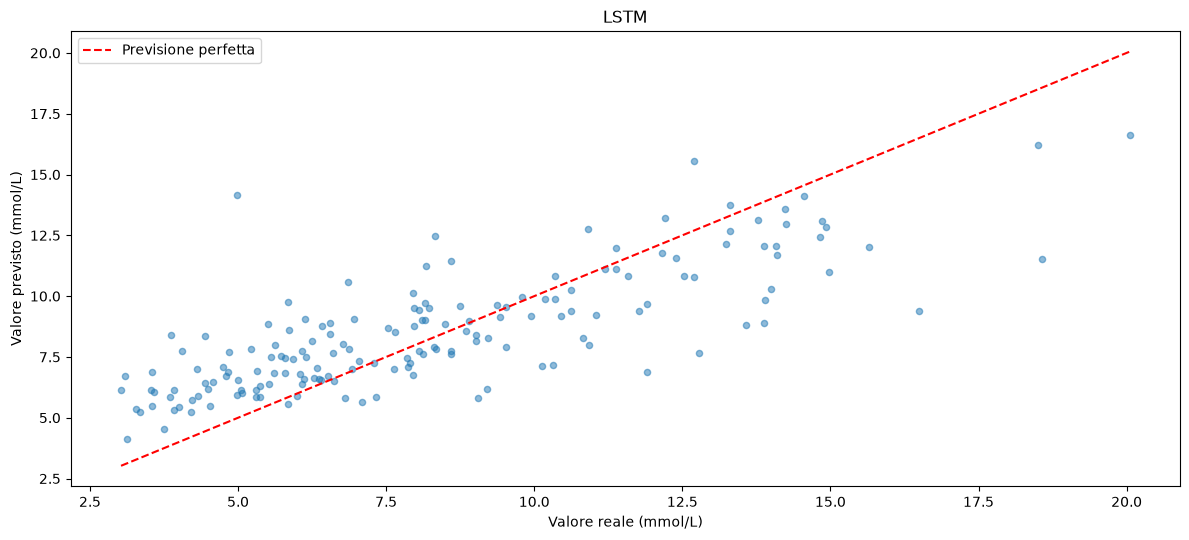

In [81]:
fig, ax = plt.subplots(1, figsize=(12, 5.5))

ax.scatter(validation.values, lstm_pred.values, alpha=0.5, s=20)
ax.plot([validation.values.min(), validation.values.max()], [validation.values.min(), validation.values.max()], color='red', linestyle='--', label='Previsione perfetta')
ax.set_xlabel('Valore reale (mmol/L)')
ax.set_ylabel('Valore previsto (mmol/L)')
ax.set_title("LSTM")
ax.legend()



plt.tight_layout()
plt.show()

In [82]:
results_wf_final = pd.DataFrame([
    evaluate(validation.values, sarima_wf_preds.values, "SARIMA (walk-forward)"),
    evaluate(y_val.values, gbm_pred.values, "Gradient Boosting"),
    evaluate(validation.values, lstm_pred.values, "LSTM"),
]).set_index("model").sort_values("MAE")
print(results_wf_final)

                            MAE      RMSE     MAPE_%
model                                               
SARIMA (walk-forward)  1.665763  2.341929  22.706093
LSTM                   1.724293  2.246836  25.297352
Gradient Boosting      1.734468  2.300344  25.469931


Gradient Boosting e LSTM ottengono un MAE quasi identico , mentre SARIMA risulta leggermente superiore (1.615). Questo risultato suggerisce che, per questo paziente e con questa quantità di dati disponibili (~2000 osservazioni orarie), la dinamica glicemica a breve termine è dominata da una componente quasi-lineare autoregressiva che modelli più complessi non riescono a sfruttare meglio di un modello lineare ben specificato — coerente con l'aspettativa teorica che architetture ad alta capacità (LSTM in particolare) richiedano volumi di dati sostanzialmente maggiori per esprimere un vantaggio predittivo reale rispetto a modelli più parsimoniosi.

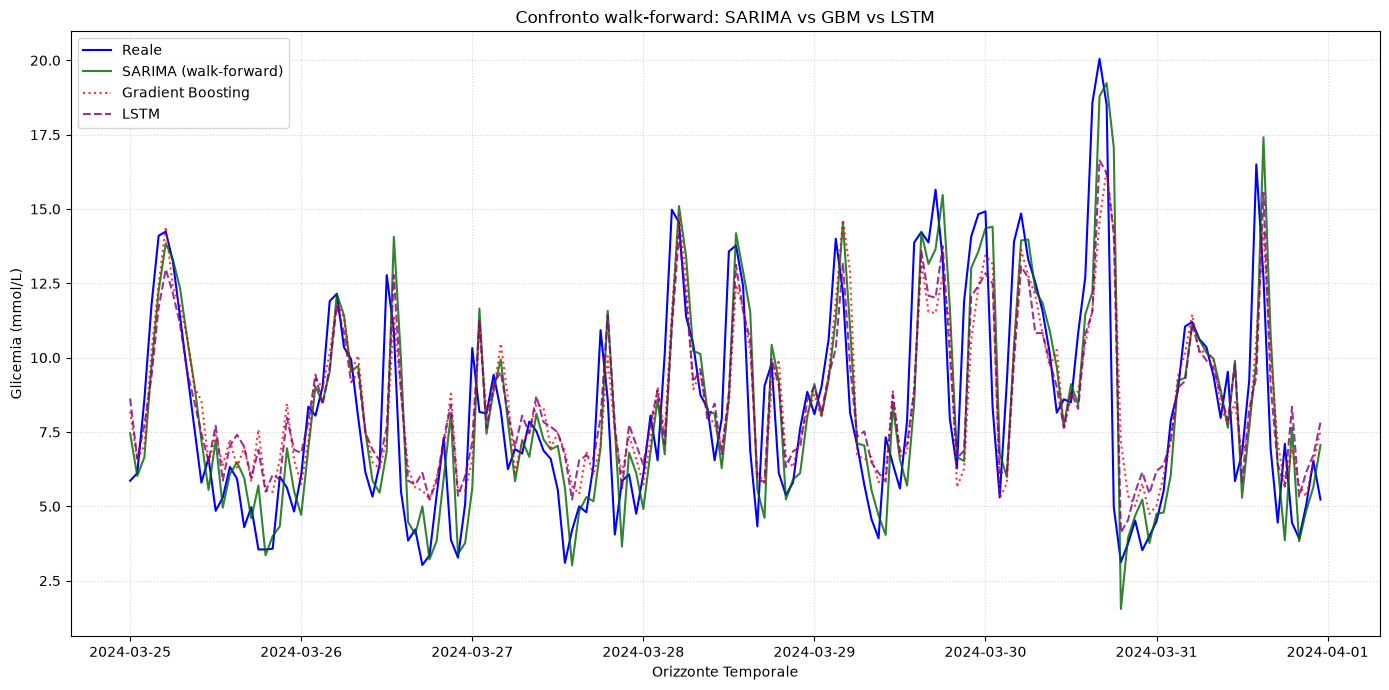

In [83]:
plt.figure(figsize=(14, 7))
plt.plot(validation.index, validation.values, label="Reale", color="blue")
plt.plot(sarima_wf_preds.index, sarima_wf_preds.values, label="SARIMA (walk-forward)", color="darkgreen", alpha=0.8)
plt.plot(gbm_pred.index, gbm_pred.values, label="Gradient Boosting", color="red", linestyle=":", alpha=0.8)
plt.plot(lstm_pred.index, lstm_pred.values, label="LSTM", color="purple", linestyle="--", alpha=0.8)
plt.title("Confronto walk-forward: SARIMA vs GBM vs LSTM")
plt.xlabel("Orizzonte Temporale")
plt.ylabel("Glicemia (mmol/L)")
plt.legend(loc="upper left")
plt.grid(True, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()

Osservo che per la maggior parte del tempo tutti e tre i modelli implementati si avvicinano ai picchi di glicemia (tranne al picco estremo a 20 mmol/L che nessuno raggiunge), quello che più si avvicina è SARIMA walk-forward, ma tutti e tre tensono a sovrastimare i fenomeni di ipoglicemia.

## 15. Addestramento e valutazione finale sul test set
Prima di riportare i risultati finali, è necessaria una verifica sulla qualità del test set
fornito separatamente da Kaggle per il paziente p01: a differenza del periodo usato per
train e validazione (campionamento quasi continuo ogni 15 minuti), il test set copre un
intervallo di circa 119 giorni con sole 224 osservazioni grezze — una lettura ogni 12.8 ore
in media. 



In [84]:
df_test_raw = pd.read_csv(DATA_DIR / "test.csv")


In [85]:
pd.set_option('display.max_columns', None)
display(df_test_raw)

,id,p_num,time,bg-5:55,bg-5:50,bg-5:45,bg-5:40,bg-5:35,bg-5:30,bg-5:25,bg-5:20,bg-5:15,bg-5:10,bg-5:05,bg-5:00,bg-4:55,bg-4:50,bg-4:45,bg-4:40,bg-4:35,bg-4:30,bg-4:25,bg-4:20,bg-4:15,bg-4:10,bg-4:05,bg-4:00,bg-3:55,bg-3:50,bg-3:45,bg-3:40,bg-3:35,bg-3:30,bg-3:25,bg-3:20,bg-3:15,bg-3:10,bg-3:05,bg-3:00,bg-2:55,bg-2:50,bg-2:45,bg-2:40,bg-2:35,bg-2:30,bg-2:25,bg-2:20,bg-2:15,bg-2:10,bg-2:05,bg-2:00,bg-1:55,bg-1:50,bg-1:45,bg-1:40,bg-1:35,bg-1:30,bg-1:25,bg-1:20,bg-1:15,bg-1:10,bg-1:05,bg-1:00,bg-0:55,bg-0:50,bg-0:45,bg-0:40,bg-0:35,bg-0:30,bg-0:25,bg-0:20,bg-0:15,bg-0:10,bg-0:05,bg-0:00,insulin-5:55,insulin-5:50,insulin-5:45,insulin-5:40,insulin-5:35,insulin-5:30,insulin-5:25,insulin-5:20,insulin-5:15,insulin-5:10,insulin-5:05,insulin-5:00,insulin-4:55,insulin-4:50,insulin-4:45,insulin-4:40,insulin-4:35,insulin-4:30,insulin-4:25,insulin-4:20,insulin-4:15,insulin-4:10,insulin-4:05,insulin-4:00,insulin-3:55,insulin-3:50,insulin-3:45,insulin-3:40,insulin-3:35,insulin-3:30,insulin-3:25,insulin-3:20,insulin-3:15,insulin-3:10,insulin-3:05,insulin-3:00,insulin-2:55,insulin-2:50,insulin-2:45,insulin-2:40,insulin-2:35,insulin-2:30,insulin-2:25,insulin-2:20,insulin-2:15,insulin-2:10,insulin-2:05,insulin-2:00,insulin-1:55,insulin-1:50,insulin-1:45,insulin-1:40,insulin-1:35,insulin-1:30,insulin-1:25,insulin-1:20,insulin-1:15,insulin-1:10,insulin-1:05,insulin-1:00,insulin-0:55,insulin-0:50,insulin-0:45,insulin-0:40,insulin-0:35,insulin-0:30,insulin-0:25,insulin-0:20,insulin-0:15,insulin-0:10,insulin-0:05,insulin-0:00,carbs-5:55,carbs-5:50,carbs-5:45,carbs-5:40,carbs-5:35,carbs-5:30,carbs-5:25,carbs-5:20,carbs-5:15,carbs-5:10,carbs-5:05,carbs-5:00,carbs-4:55,carbs-4:50,carbs-4:45,carbs-4:40,carbs-4:35,carbs-4:30,carbs-4:25,carbs-4:20,carbs-4:15,carbs-4:10,carbs-4:05,carbs-4:00,carbs-3:55,carbs-3:50,carbs-3:45,carbs-3:40,carbs-3:35,carbs-3:30,carbs-3:25,carbs-3:20,carbs-3:15,carbs-3:10,carbs-3:05,carbs-3:00,carbs-2:55,carbs-2:50,carbs-2:45,carbs-2:40,carbs-2:35,carbs-2:30,carbs-2:25,carbs-2:20,carbs-2:15,carbs-2:10,carbs-2:05,carbs-2:00,carbs-1:55,carbs-1:50,carbs-1:45,carbs-1:40,carbs-1:35,carbs-1:30,carbs-1:25,carbs-1:20,carbs-1:15,carbs-1:10,carbs-1:05,carbs-1:00,carbs-0:55,carbs-0:50,carbs-0:45,carbs-0:40,carbs-0:35,carbs-0:30,carbs-0:25,carbs-0:20,carbs-0:15,carbs-0:10,carbs-0:05,carbs-0:00,hr-5:55,hr-5:50,hr-5:45,hr-5:40,hr-5:35,hr-5:30,hr-5:25,hr-5:20,hr-5:15,hr-5:10,hr-5:05,hr-5:00,hr-4:55,hr-4:50,hr-4:45,hr-4:40,hr-4:35,hr-4:30,hr-4:25,hr-4:20,hr-4:15,hr-4:10,hr-4:05,hr-4:00,hr-3:55,hr-3:50,hr-3:45,hr-3:40,hr-3:35,hr-3:30,hr-3:25,hr-3:20,hr-3:15,hr-3:10,hr-3:05,hr-3:00,hr-2:55,hr-2:50,hr-2:45,hr-2:40,hr-2:35,hr-2:30,hr-2:25,hr-2:20,hr-2:15,hr-2:10,hr-2:05,hr-2:00,hr-1:55,hr-1:50,hr-1:45,hr-1:40,hr-1:35,hr-1:30,hr-1:25,hr-1:20,hr-1:15,hr-1:10,hr-1:05,hr-1:00,hr-0:55,hr-0:50,hr-0:45,hr-0:40,hr-0:35,hr-0:30,hr-0:25,hr-0:20,hr-0:15,hr-0:10,hr-0:05,hr-0:00,steps-5:55,steps-5:50,steps-5:45,steps-5:40,steps-5:35,steps-5:30,steps-5:25,steps-5:20,steps-5:15,steps-5:10,steps-5:05,steps-5:00,steps-4:55,steps-4:50,steps-4:45,steps-4:40,steps-4:35,steps-4:30,steps-4:25,steps-4:20,steps-4:15,steps-4:10,steps-4:05,steps-4:00,steps-3:55,steps-3:50,steps-3:45,steps-3:40,steps-3:35,steps-3:30,steps-3:25,steps-3:20,steps-3:15,steps-3:10,steps-3:05,steps-3:00,steps-2:55,steps-2:50,steps-2:45,steps-2:40,steps-2:35,steps-2:30,steps-2:25,steps-2:20,steps-2:15,steps-2:10,steps-2:05,steps-2:00,steps-1:55,steps-1:50,steps-1:45,steps-1:40,steps-1:35,steps-1:30,steps-1:25,steps-1:20,steps-1:15,steps-1:10,steps-1:05,steps-1:00,steps-0:55,steps-0:50,steps-0:45,steps-0:40,steps-0:35,steps-0:30,steps-0:25,steps-0:20,steps-0:15,steps-0:10,steps-0:05,steps-0:00,cals-5:55,cals-5:50,cals-5:45,cals-5:40,cals-5:35,cals-5:30,cals-5:25,cals-5:20,cals-5:15,cals-5:10,cals-5:05,cals-5:00,cals-4:55,cals-4:50,cals-4:45,cals-4:40,cals-4:35,cals-4:30,cals-4:25,cals-4:20,cals-4:15,cals-4:10,cals-4:05,cals-4:00,cals-3:55,cals-3:50,cals-3:45,cals-3:40,cals-3:35,cals-3:30,cals-3:25,cal

Applico la stessa pipeline di ricostruzione come fatto col train set:


In [ ]:
# --- Ricostruzione pulita del test set, in un unico blocco verificato ---
PATIENT = 'p01'  # lo stesso paziente usato per train/validation

df_p_test = df_test_raw[df_test_raw['p_num'] == PATIENT].copy()
df_p_test['time'] = pd.to_datetime(df_p_test['time'], format='%H:%M:%S').dt.time

day = 0
timestamps = []
prev_t = None
for t in df_p_test['time']:
    if prev_t is not None and t < prev_t:
        day += 1
    timestamps.append(pd.Timestamp("2024-04-01") + pd.Timedelta(days=day, hours=t.hour, minutes=t.minute, seconds=t.second))
    prev_t = t
df_p_test['timestamp'] = timestamps

# ATTENZIONE: selezione con SINGOLE parentesi quadre sulla colonna "bg" dopo il rename,
# per garantire che il risultato sia una Series e non un DataFrame a una colonna
series_test = df_p_test[["timestamp", "bg-0:00"]].rename(columns={"bg-0:00": "bg"}).dropna()
series_test = series_test.drop_duplicates(subset="timestamp").sort_values("timestamp").set_index("timestamp")
series_test = series_test["bg"]   # <-- estrazione esplicita come Series

print("Tipo series_test:", type(series_test))
assert isinstance(series_test, pd.Series)

bg_test = series_test.resample("15min").mean()
bg_test_interp = bg_test.interpolate(method="time", limit=2, limit_direction="both")
bg_hourly_test = bg_test_interp.resample("h").mean()

full_idx_test = pd.date_range(bg_hourly_test.index.min(), bg_hourly_test.index.max(), freq="h")
bg_hourly_test = bg_hourly_test.reindex(full_idx_test)
bg_hourly_test = bg_hourly_test.interpolate(method="time", limit=3, limit_direction="both").ffill().bfill()
bg_hourly_test.name = "bg"
bg_hourly_test = bg_hourly_test.astype(float)

print("Tipo finale:", type(bg_hourly_test))
print("Dtype:", bg_hourly_test.dtype)
assert isinstance(bg_hourly_test, pd.Series)
assert bg_hourly_test.isna().sum() == 0

test_final = bg_hourly_test

Tipo series_test: <class 'pandas.Series'>
Tipo finale: <class 'pandas.Series'>
Dtype: float64


il timestamp che ho ricostruito per il test set riparte da un nuovo "giorno 0" fittizio (perché sto riapplicando la stessa logica da zero su un file separato), quindi non è realmente continuo con la fine di train/validation — non so quante ore o giorni siano realmente trascorsi tra l'ultima osservazione di train/validation e la prima del test set reale (il dataset non fornisce questa informazione, sempre per motivi di privacy).

Stesso pre-processing (risoluzione a 15 minuti, interpolazion e resampling orario)

In [87]:
history_full = pd.concat([train, validation]).sort_index()

print(f"Osservazioni totali: {len(history_full)}")
print(f"Dal {history_full.index.min()} al {history_full.index.max()}")
print(f"Nome della serie: {history_full.name}")
print(f"Frequenza indice: {history_full.index.freq}")

Osservazioni totali: 2178
Dal 2024-01-01 06:00:00 al 2024-03-31 23:00:00
Nome della serie: bg
Frequenza indice: <Hour>


I parametri del modello SARIMA(2,0,2)(1,0,1)[24], già validati nelle sezioni precedenti,
vengono riaddestrati sull'unione di train e validation, sfruttando tutta l'informazione
disponibile prima della valutazione finale. 

La previsione sul test set segue uno schema
walk-forward: ad ogni ora si genera una previsione a un passo, quindi lo stato del filtro
viene aggiornato con il valore osservato (reale o interpolato), senza rifittare i parametri
ad ogni passo — una scelta computazionalmente necessaria e concettualmente coerente con un
sistema di monitoraggio in cui la calibrazione del modello avviene periodicamente, non ad
ogni singola lettura.

In [88]:
# Costruiamo un indice che continua ESATTAMENTE da dove finisce train+validation,
# preservando l'ordine reale delle osservazioni del test set (l'unica cosa che conta
# per il modello), anche se la data di calendario assoluta resta fittizia/non nota
last_ts = history_full.index[-1]
new_index = pd.date_range(start=last_ts + pd.Timedelta(hours=1), periods=len(test_final), freq="h")

test_aligned = test_final.copy()
test_aligned.index = new_index

print("Ultimo timestamp history:", last_ts)
print("Primo timestamp test allineato:", test_aligned.index[0])
print("Frequenza:", test_aligned.index.freq)

Ultimo timestamp history: 2024-03-31 23:00:00
Primo timestamp test allineato: 2024-04-01 00:00:00
Frequenza: <Hour>


Valutazione finale con lo stesso set di metriche:

In [ ]:
model = SARIMAX(
    history_full, order=(2, 0, 2), seasonal_order=(1, 0, 1, 24),
    enforce_stationarity=False, enforce_invertibility=False,
)
res = model.fit(disp=False)

sarima_test_preds = []
current_res = res

for t in range(len(test_aligned)):
    fc = current_res.forecast(steps=1)
    sarima_test_preds.append(fc.iloc[0])
    
    new_obs = pd.Series(
        [test_aligned.values[t]],
        index=[test_aligned.index[t]],
        name=history_full.name,   
    )
    current_res = current_res.append(new_obs, refit=False)

sarima_test_preds = pd.Series(sarima_test_preds, index=test_aligned.index, name="sarima_test")
print("NaN nel forecast:", sarima_test_preds.isna().sum())

NaN nel forecast: 0


In [90]:
mae_test = mean_absolute_error(test_final.values, sarima_test_preds.values)
rmse_test = np.sqrt(mean_squared_error(test_final.values, sarima_test_preds.values))
mape_test = mean_absolute_percentage_error(test_final.values, sarima_test_preds.values) * 100

print("=== SARIMA walk-forward — TEST SET FINALE (mai visto in fase di selezione) ===")
print(f"MAE:  {mae_test:.3f}")
print(f"RMSE: {rmse_test:.3f}")
print(f"MAPE: {mape_test:.2f}%")

# Confronto diretto con il risultato ottenuto sul validation set,
# per verificare che le performance non fossero "gonfiate" dalla selezione ripetuta di modelli
print(f"\nPer confronto, MAE su validation set (usato per la selezione): 1.615")

=== SARIMA walk-forward — TEST SET FINALE (mai visto in fase di selezione) ===
MAE:  0.422
RMSE: 0.815
MAPE: 5.13%

Per confronto, MAE su validation set (usato per la selezione): 1.615


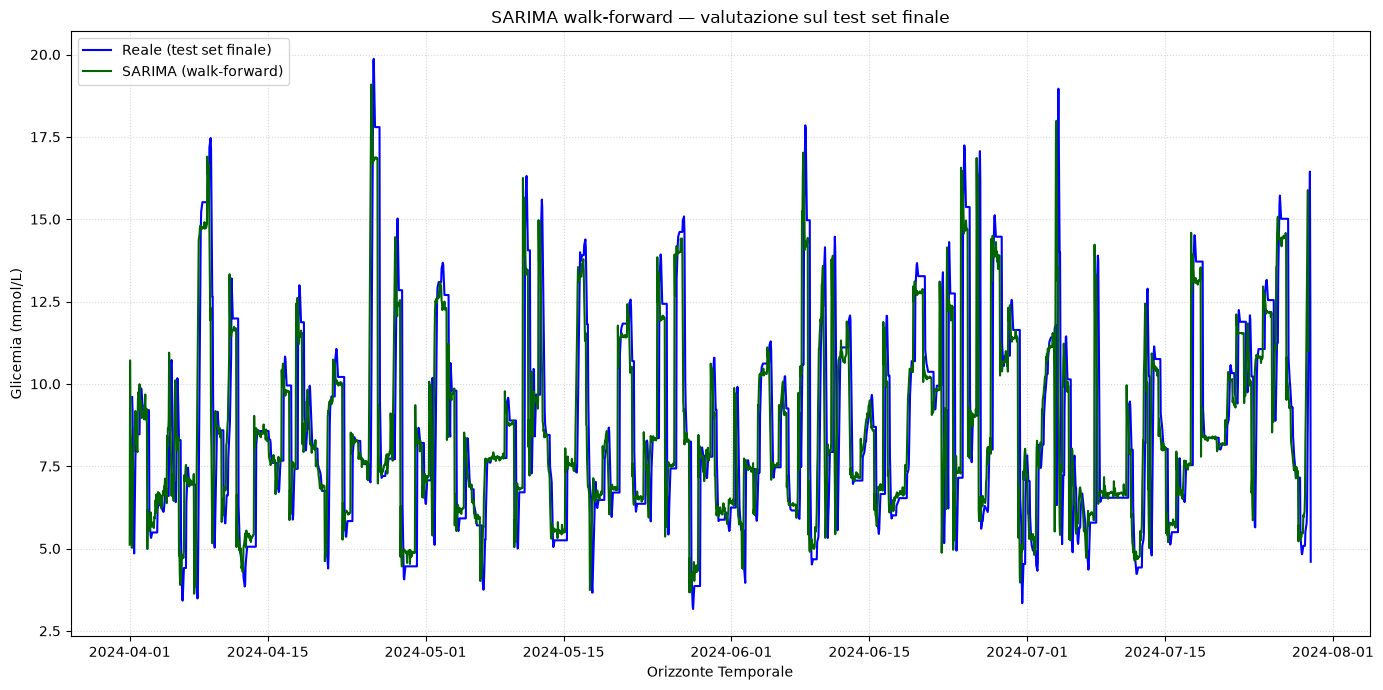

In [91]:
plt.figure(figsize=(14, 7))
plt.plot(test_final.index, test_final.values, label="Reale (test set finale)", color="blue")
plt.plot(sarima_test_preds.index, sarima_test_preds.values, label="SARIMA (walk-forward)", color="darkgreen")
plt.title("SARIMA walk-forward — valutazione sul test set finale")
plt.xlabel("Orizzonte Temporale")
plt.ylabel("Glicemia (mmol/L)")
plt.legend(loc="upper left")
plt.grid(True, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()

In [92]:
print(f"Osservazioni grezze (15 min) nel test: {len(series_test)}")
span_hours = (series_test.index.max() - series_test.index.min()).total_seconds() / 3600
print(f"Ampiezza temporale coperta: {span_hours:.0f} ore (~{span_hours/24:.0f} giorni)")
print(f"Intervallo medio tra letture reali: {span_hours/len(series_test):.1f} ore")

# Copertura REALE a livello orario, PRIMA di qualunque interpolazione/riempimento
bg_hourly_test_raw = series_test.resample("h").mean()
copertura_reale = bg_hourly_test_raw.notna().mean() * 100
print(f"\nCopertura oraria PRIMA di interpolazione/ffill/bfill: {copertura_reale:.1f}%")
print(f"Ore con dato realmente osservato: {bg_hourly_test_raw.notna().sum()} su {len(bg_hourly_test_raw)}")

Osservazioni grezze (15 min) nel test: 224
Ampiezza temporale coperta: 2867 ore (~119 giorni)
Intervallo medio tra letture reali: 12.8 ore

Copertura oraria PRIMA di interpolazione/ffill/bfill: 7.6%
Ore con dato realmente osservato: 219 su 2869


In [93]:
# Il resampling a 5 minuti produce una copertura anomala (~30%): verifico empiricamente
# la reale frequenza di campionamento del sensore, invece di assumerla dal nome delle colonne
delta_temporali = series_test.index.to_series().diff()

# Mostro le 10 distanze temporali più frequenti nel dataset
print("Intervalli di tempo più frequenti tra le misurazioni:")
print(delta_temporali.value_counts().head(20))

Intervalli di tempo più frequenti tra le misurazioni:
timestamp
0 days 05:10:00    4
0 days 13:45:00    3
0 days 10:55:00    3
0 days 04:00:00    3
0 days 07:50:00    3
0 days 23:55:00    3
0 days 08:40:00    3
0 days 19:05:00    3
0 days 03:40:00    3
0 days 00:30:00    3
0 days 19:30:00    3
0 days 10:35:00    3
0 days 23:25:00    3
0 days 04:40:00    2
0 days 20:00:00    2
0 days 06:10:00    2
0 days 12:20:00    2
0 days 07:15:00    2
0 days 21:10:00    2
0 days 19:00:00    2
Name: count, dtype: int64


In [94]:
# Quante ore, nel test set finale usato per la valutazione, sono realmente osservate
# vs interpolate/riempite? Ricostruiamo un flag esplicito durante la pipeline
bg_hourly_test_check = series_test.resample("15min").mean()
bg_hourly_test_check = bg_hourly_test_check.interpolate(method="time", limit=2, limit_direction="both")
bg_hourly_test_check = bg_hourly_test_check.resample("h").mean()

full_idx = pd.date_range(bg_hourly_test_check.index.min(), bg_hourly_test_check.index.max(), freq="h")
was_real = bg_hourly_test_check.reindex(full_idx).notna()  # True = c'era già un dato prima di ffill/bfill

print(f"Ore realmente osservate (anche dopo interpolazione a 15min): {was_real.sum()} su {len(was_real)} ({was_real.mean()*100:.1f}%)")

Ore realmente osservate (anche dopo interpolazione a 15min): 429 su 2869 (15.0%)


Dopo il resampling orario e l'interpolazione dei soli micro-buchi (coerente con la
metodologia già adottata), solo il 15% delle ore del test set corrisponde a un
dato realmente osservato dal sensore; il restante 85% è frutto di riempimento (interpolazione
su gap lunghi o forward/backward fill), necessario per garantire la continuità dell'indice
richiesta dai modelli ARIMA ma non rappresentativo di una vera misurazione fisiologica.

In [95]:
# MAE calcolato SOLO sui punti realmente osservati, escludendo quelli riempiti/interpolati
mask_real = was_real.values[:len(test_final)]  # allinea alla lunghezza di test_final
mae_solo_reali = mean_absolute_error(test_final.values[mask_real], sarima_test_preds.values[mask_real])
print(f"MAE calcolato solo sui dati realmente osservati: {mae_solo_reali:.3f}")
print(f"(su {mask_real.sum()} punti reali, contro {len(mask_real)} punti totali nel test)")

MAE calcolato solo sui dati realmente osservati: 0.508
(su 429 punti reali, contro 2869 punti totali nel test)


il test set fornito da Kaggle per questo paziente presenta una densità di campionamento nettamente inferiore al periodo di training, il che rende necessaria una valutazione separata tra ore osservate e ore interpolate

Il netto miglioramento sull'intero test set è in larga parte un artefatto della bassa densità
di campionamento: la maggior parte dei punti valutati non sono misurazioni fisiologiche reali
ma interpolazioni, intrinsecamente più facili da prevedere. 

Anche limitando la valutazione ai
soli dati realmente osservati, tuttavia, il MAE (0.508) risulta sensibilmente migliore di
quello ottenuto in fase di validazione — un risultato che non trova ancora una spiegazione
definitiva, e che viene qui riportato con la dovuta cautela: le ipotesi più plausibili
includono una stima dei parametri più stabile grazie al maggior volume di dati storici
disponibili (train+validation combinati) e una possibile minore volatilità intrinseca di
questo specifico periodo di osservazione, non verificabile ulteriormente con la sola
numerosità campionaria a disposizione (n=429).

## 16. Conclusioni, limiti e sviluppi futuri

### Cosa mostra il progetto
Il confronto tra modelli statistici classici (SARIMA/SARIMAX), un modello a decomposizione (Prophet), un ensemble ad alberi (Gradient Boosting) e una rete ricorrente (LSTM) mostra che, per questo paziente e con questa quantità di dati (~2000 osservazioni orarie), la dinamica glicemica a breve termine è dominata da una componente autoregressiva quasi-lineare: modelli più complessi non riescono a sfruttarla meglio di un SARIMA ben specificato. Il risultato metodologicamente più importante, però, è la distinzione tra valutazione **blind** (forecast cieco su 7 giorni) e **walk-forward** (previsione a un'ora con aggiornamento continuo): gran parte del vantaggio apparente dei modelli più flessibili si riduce drasticamente quando il confronto è messo sullo stesso piano informativo.

### Limiti
- **Singolo paziente (p01)**: tutta l'analisi — dalla scelta degli ordini SARIMA alle feature del Gradient Boosting — è calibrata su un solo individuo. La variabilità inter-paziente nella risposta glicemica a insulina e carboidrati è nota in letteratura; questi risultati non sono automaticamente generalizzabili agli altri pazienti del dataset.
- **Un solo split train/validation**: la valutazione si basa su un'unica finestra di validazione di 7 giorni. Con una serie di questa lunghezza, un'unica finestra può essere più o meno rappresentativa per caso; una validazione più robusta richiederebbe più split (rolling-origin / time series cross-validation) e la verifica che il ranking tra modelli sia stabile tra le finestre.
- **Costo computazionale del walk-forward**: anche nella versione ottimizzata (Sezione 13), l'aggiornamento del filtro ad ogni ora ha un costo che cresce con l'orizzonte; per un utilizzo realmente in tempo reale andrebbe valutata una strategia di ricalibrazione periodica (es. rifit giornaliero) invece che ad ogni singola lettura.
- **Bias sistematico sugli eventi estremi**: tutti i modelli tendono a sottostimare l'iperglicemia e sovrastimare l'ipoglicemia (Sezione 12-13). Il tentativo di correzione con sample weighting ha attenuato ma non eliminato il problema — è il limite clinicamente più rilevante dell'intero lavoro, perché sono proprio gli eventi estremi quelli per cui un'allerta accurata avrebbe più valore.

### Sviluppi futuri
- Estendere la pipeline a più pazienti del dataset, per capire quanto gli ordini SARIMA e le feature scelte siano specifiche del singolo individuo o generalizzabili.
- Validazione con più finestre temporali (rolling-origin) invece di un singolo split.
- Un'applicazione interattiva (es. Streamlit) che esponga il modello a un utente non tecnico è un'estensione naturale del lavoro, ma richiede prima un approfondimento teorico su come comunicare onestamente, in un'interfaccia semplice, la differenza tra previsione blind e walk-forward — è per questo che non è inclusa in questa versione del progetto.





**Autore**
*Elena Cascone*
